# Búsqueda de Grover para la recuperación de secretos LWE

In [47]:
import numpy as np
import qiskit
import matplotlib
import notebook
from qiskit.visualization import array_to_latex, plot_histogram
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
import math
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt


In [48]:
#Umbral elegido para decidir si un residuo es suficientemente pequeño
TAU = 1

### Generación de instancias LWE

In [49]:
#Función para generar instancias LWE
def generar_lwe(n, m, q):

    #Generar matriz A pública aleatoria
    A = np.random.randint(0, q, size=(m, n))

    #Generar secreto s aleatorio
    s = np.random.randint(0, q, size=n)

    #Gnerar vector de errores e
    e = np.random.choice([-1, 0, 1], size=m)
    
    #Calcular cada b con formula b = A*s + e mod q
    As = np.matmul(A, s)
    b = (As + e) % q
    
    return A, s, e, b

In [50]:
#Función para calcular el vector de residuos r
def calcular_residuo(A, s, b, q):
    #r = b - A*s mod q
    As = np.matmul(A, s)
    r = (b - As) % q
    return r

### Predicado oracular

f(s) = 1 si cada componente del vector de residuos r tiene distancia circular ≤ τ <br>
f(s) = 0 en caso contrario

Distancia circular = min(r, q −r)

In [51]:
#Función para evaluar el predicado oracular
def cumple_condicion(r, q):
    #Sacar el minimo entre r y q-r para cada elemento del vector
    dist = np.minimum(r, q - r)

    #Devuelve true si todos los elementos son menores o iguales a τ
    if np.all(dist <= TAU):
        return True
    else:
        return False

### Oráculo de fase


In [52]:
#Función para transformar el vector s en un vector de bits
def vector_a_bits(s, num_bits, n):
    s_bits = np.array([], dtype=int)
    for i in range(n):
        bits = [int(b) for b in format(s[i], f'0{num_bits}b')]
        s_bits = np.append(s_bits, bits)
    return s_bits

In [53]:
#Función para implementar el circuito del oráculo de fase
def oracle(num_qubits, num_bits, s, n):
    
    #Crear el circuito vacío
    circuito = QuantumCircuit(num_qubits)

    #Pasar s a bits
    s_bits = vector_a_bits(s, num_bits, n)
    print("s en bits:", s_bits)

    #Aplicar X a los 0
    for bit in enumerate(s_bits):
        if bit[1] == 0:
            circuito.x(bit[0])

    #Aplicar multicontrolled Z para añadir fase de -1
    circuito.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
    
    #Deshacer X aplicado
    for bit in enumerate(s_bits):
        if bit[1] == 0:
            circuito.x(bit[0])
    
    return circuito

### Caso de prueba 1:

In [54]:
n1 = 1
m1 = 3
q1 = 8
num_qubits1 = 3
num_bits1 = int(np.ceil(np.log2(q1)))

In [55]:
#Generar instancia LWE
A1, s1, e1, b1 = generar_lwe(n1, m1 ,q1)

display(array_to_latex(A1, prefix="A1"))
display(array_to_latex(s1, prefix="s1"))
display(array_to_latex(b1, prefix="b1"))
display(array_to_latex(e1, prefix="e1"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [56]:
#Calcular residuo
r1 = calcular_residuo(A1, s1, b1, q1)

display(array_to_latex(r1, prefix="r1"))

<IPython.core.display.Latex object>

In [57]:
#Comprobar condición
print("s1 cumple condicion:", cumple_condicion(r1, q1))

s1 cumple condicion: True


s en bits: [0 0 1]


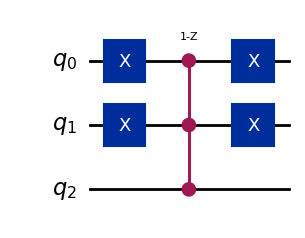

In [58]:
#Crear el circuito del oráculo de fase
circuito1 = oracle(num_qubits1, num_bits1, s1, n1)
display(circuito1.draw(output="mpl"))

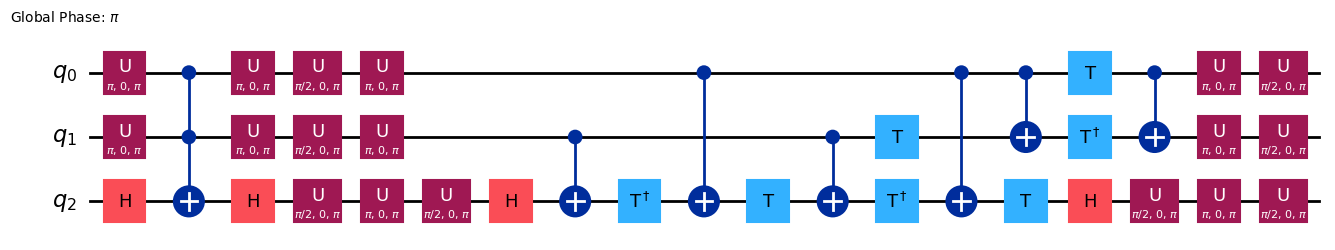

In [59]:
#Construir el operador de Grover
grover_op1 = grover_operator(circuito1)
grover_op1.decompose().draw(output="mpl", style="iqp")

k=1:


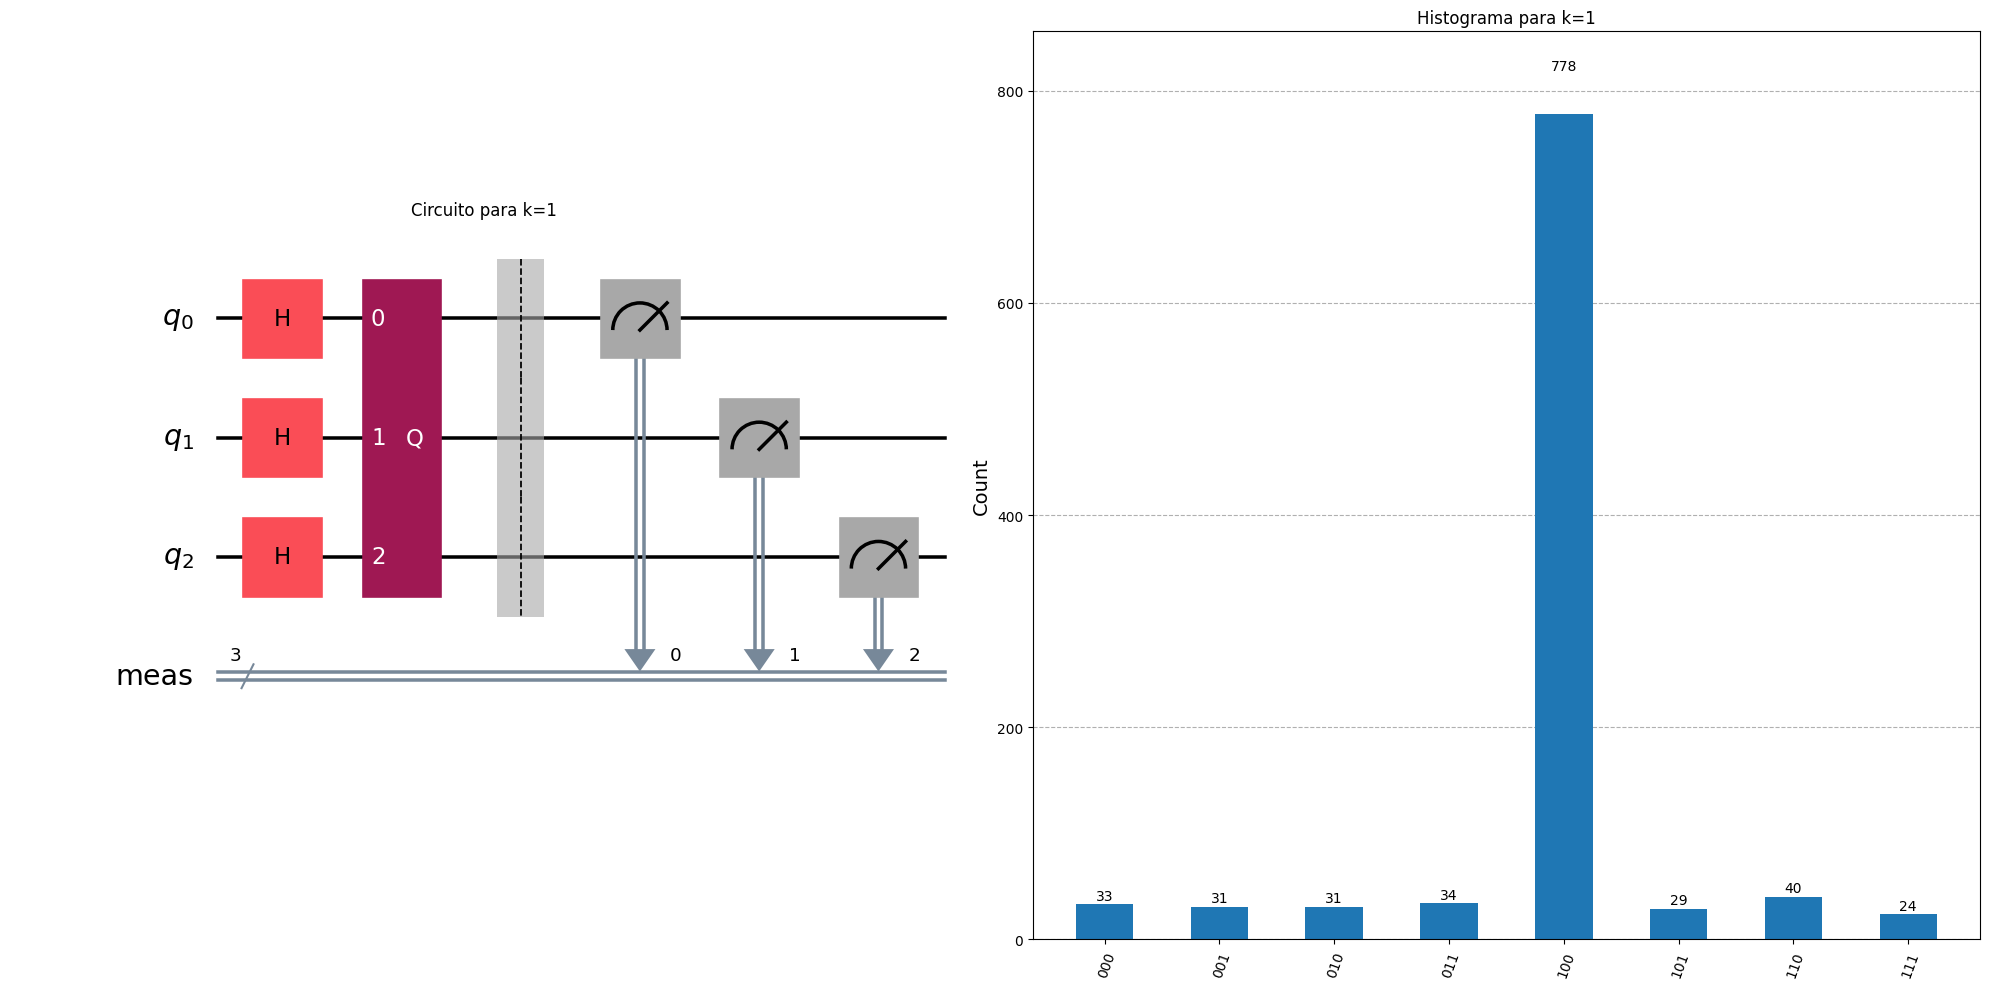

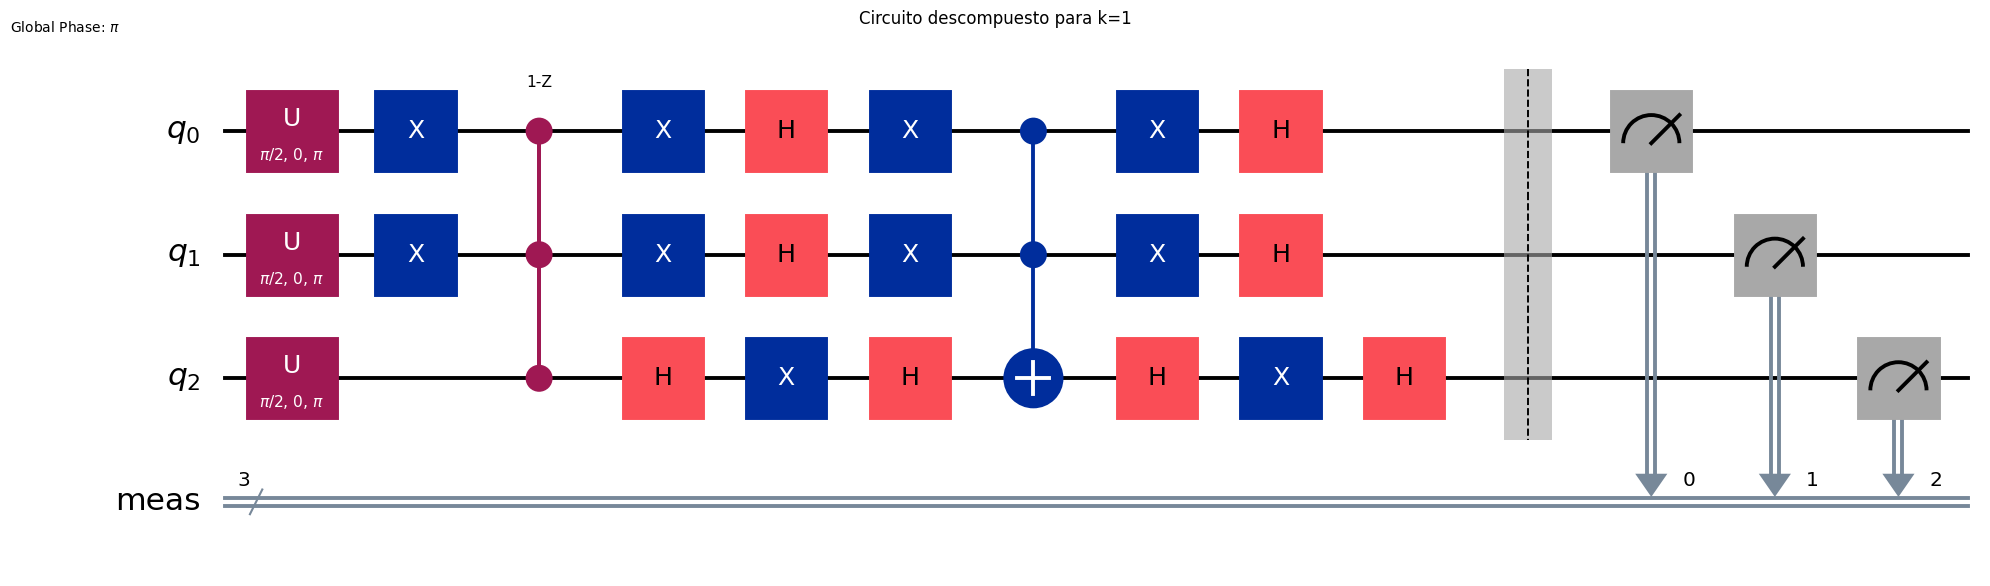

k=2:


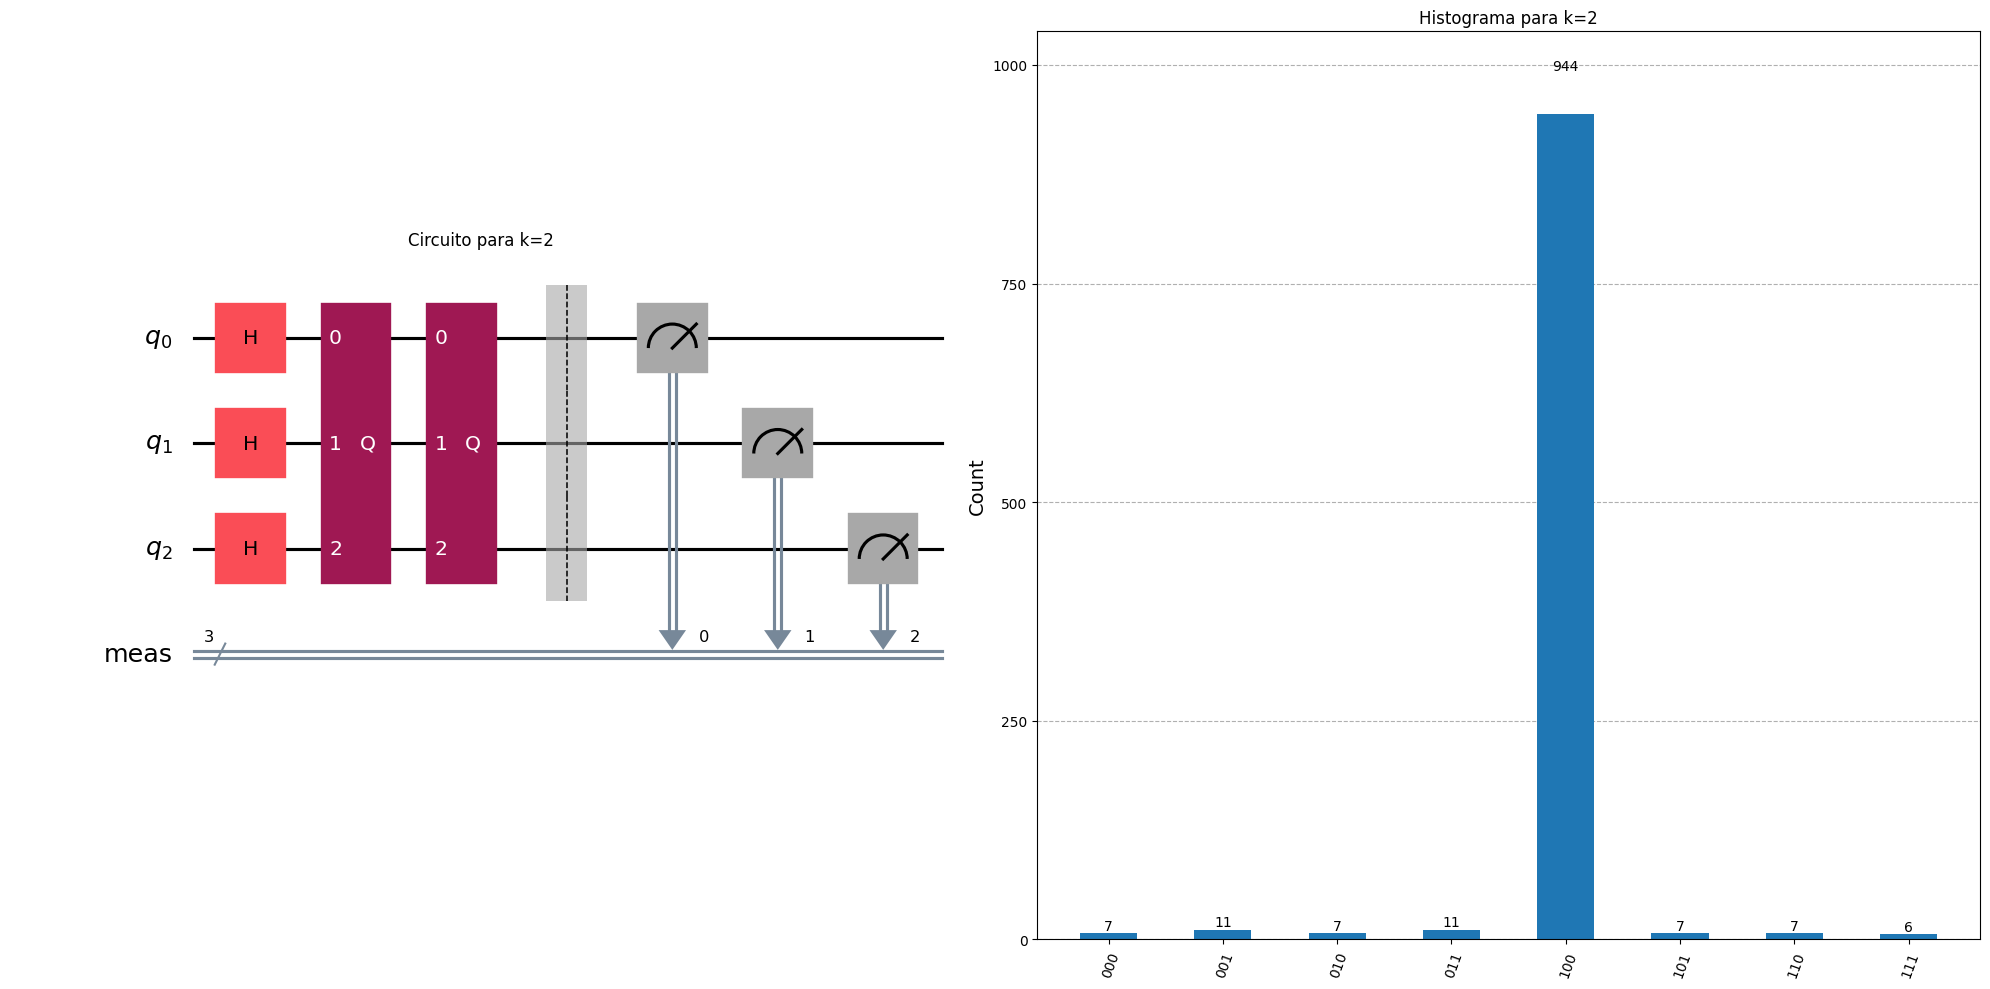

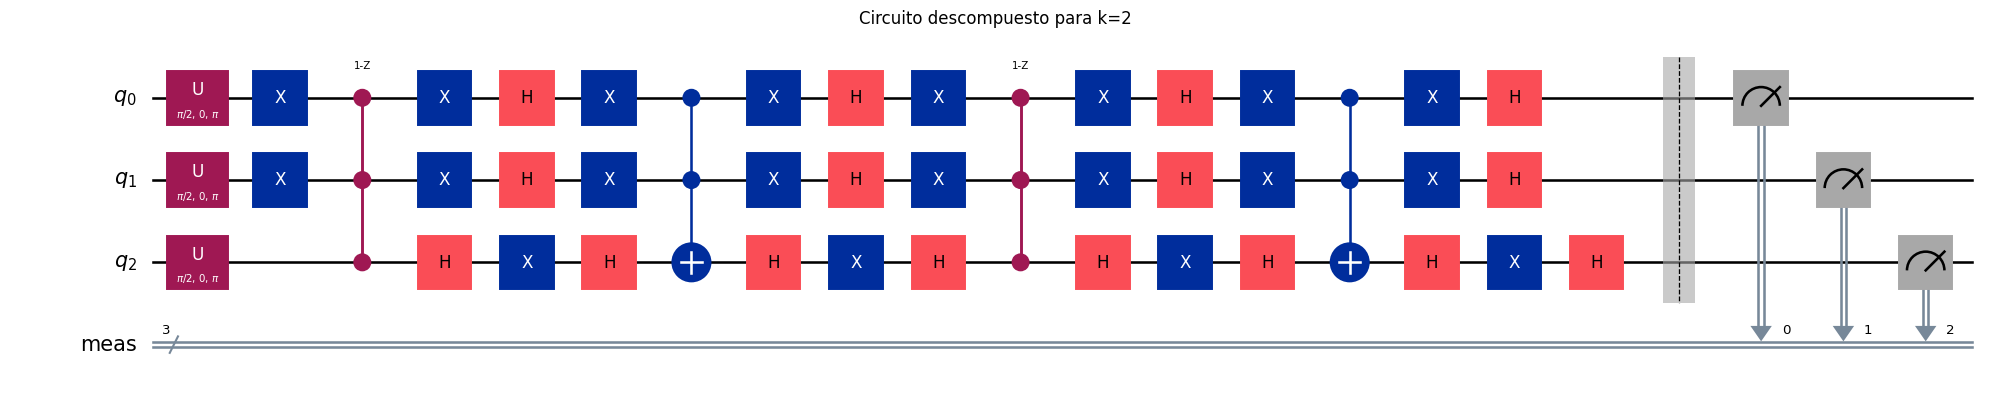

k=3:


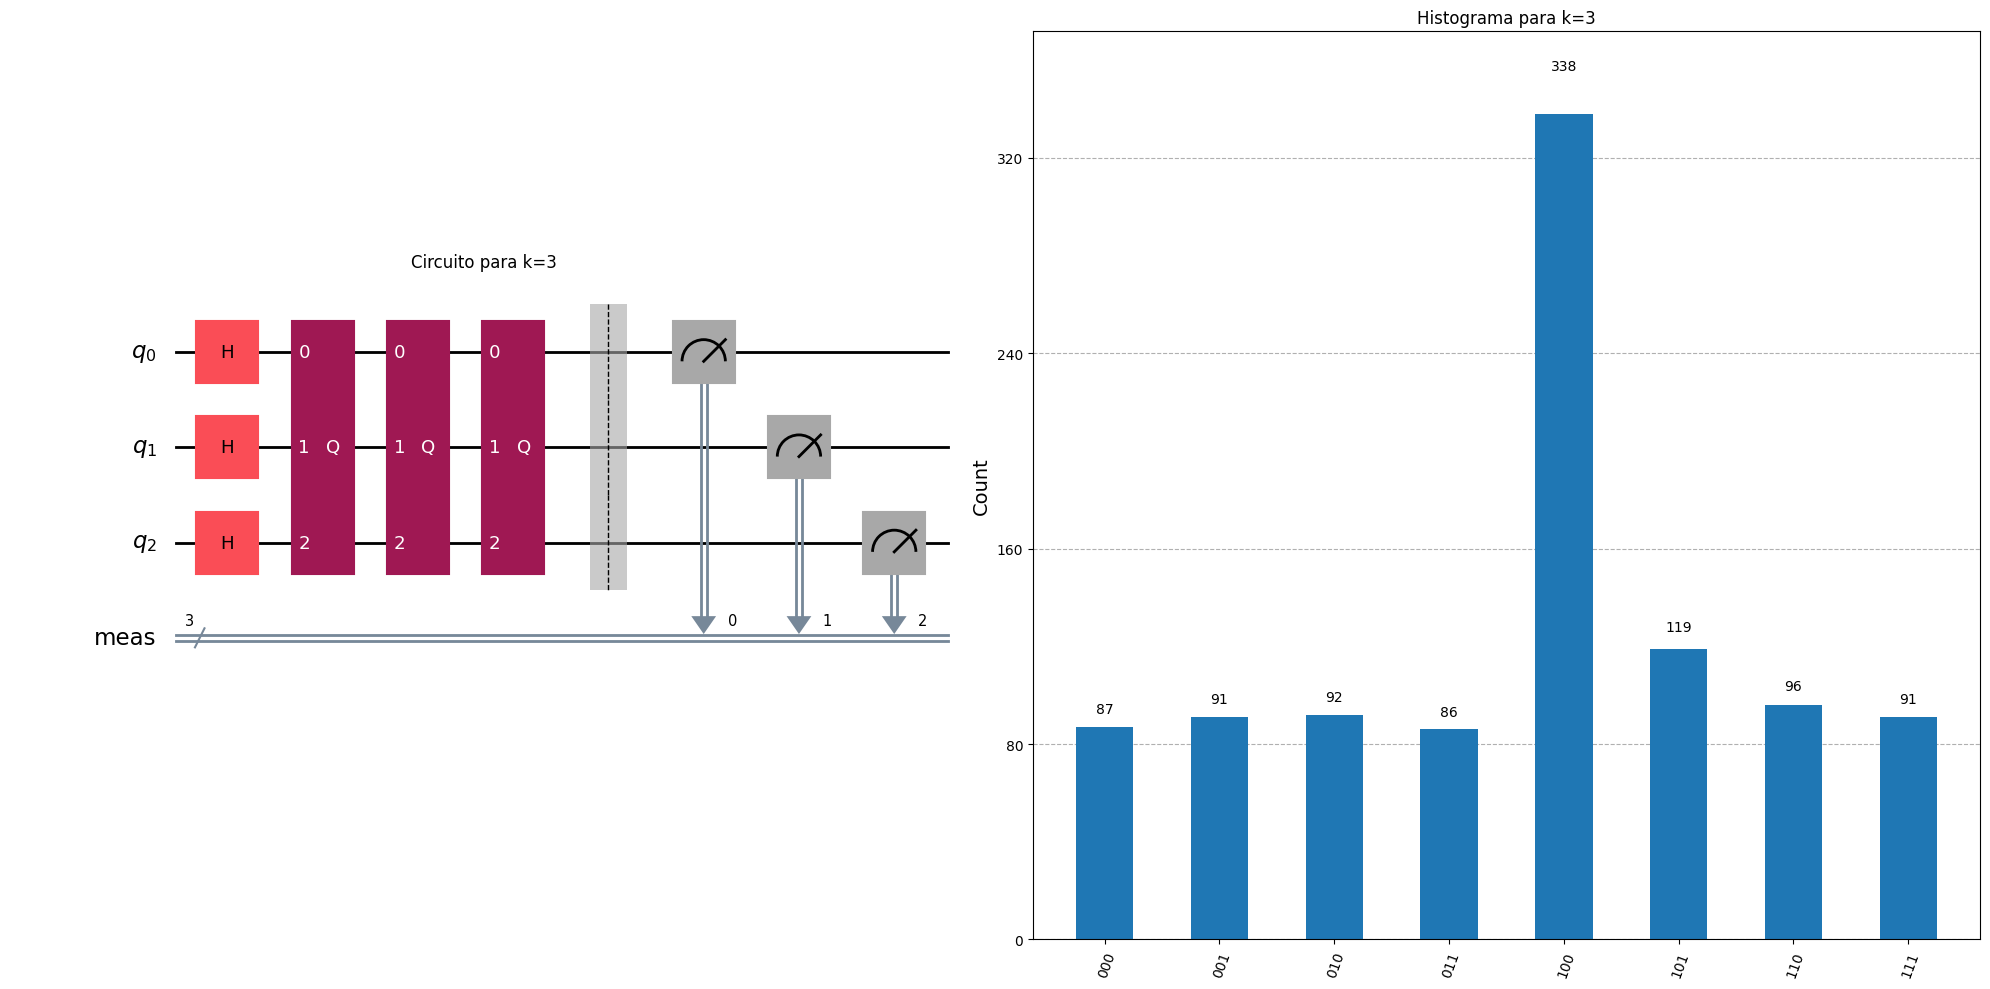

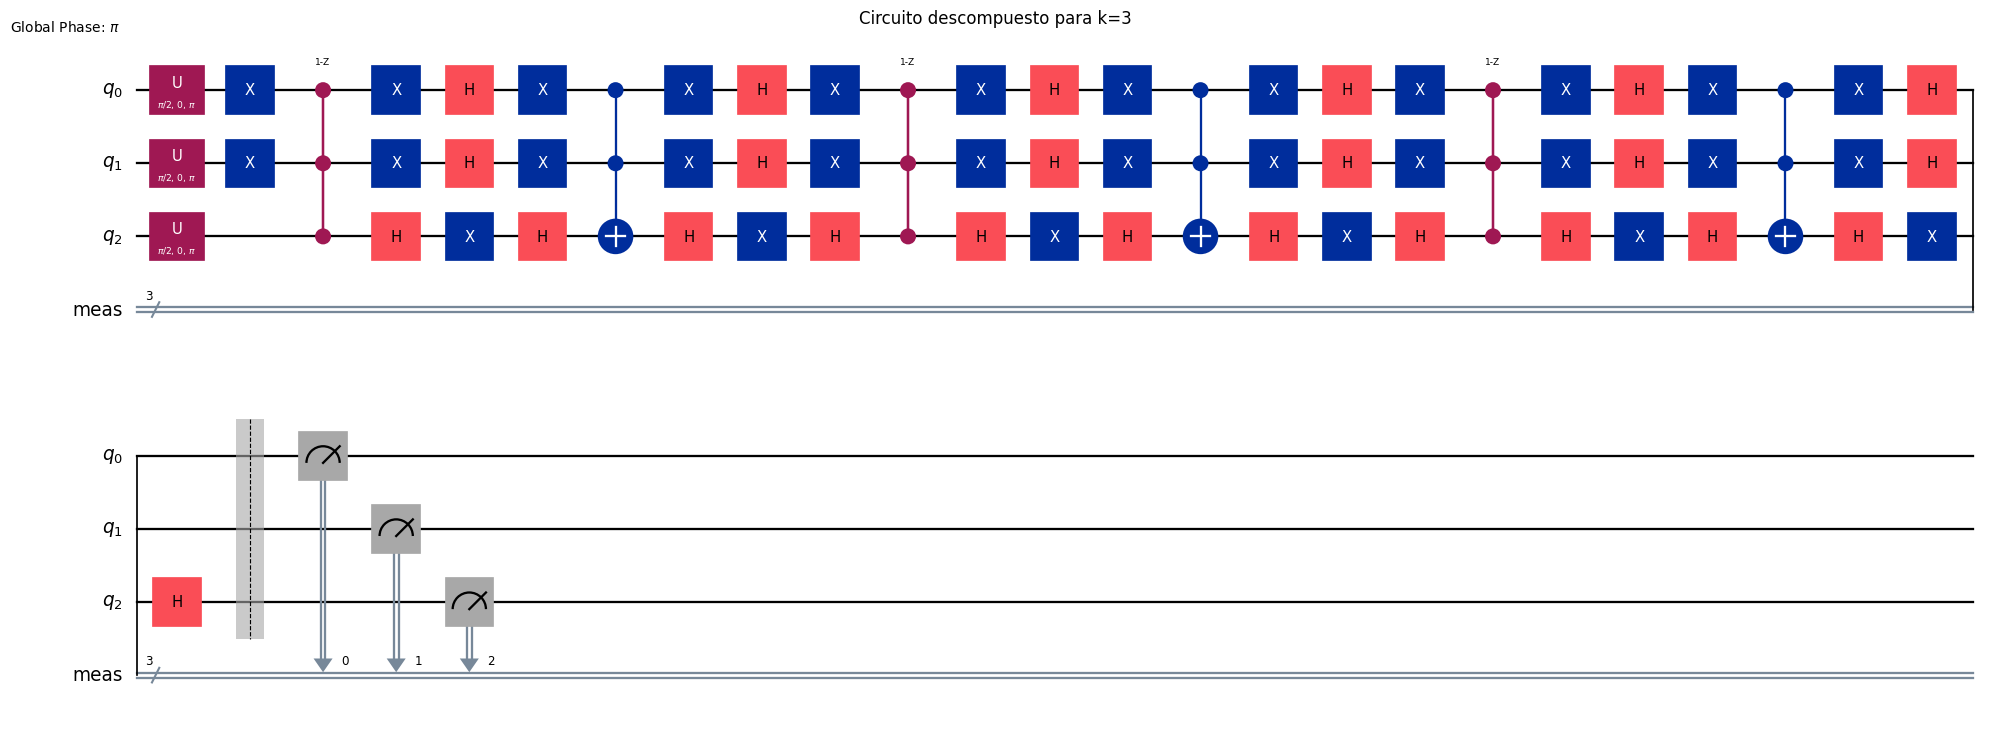

k=4:


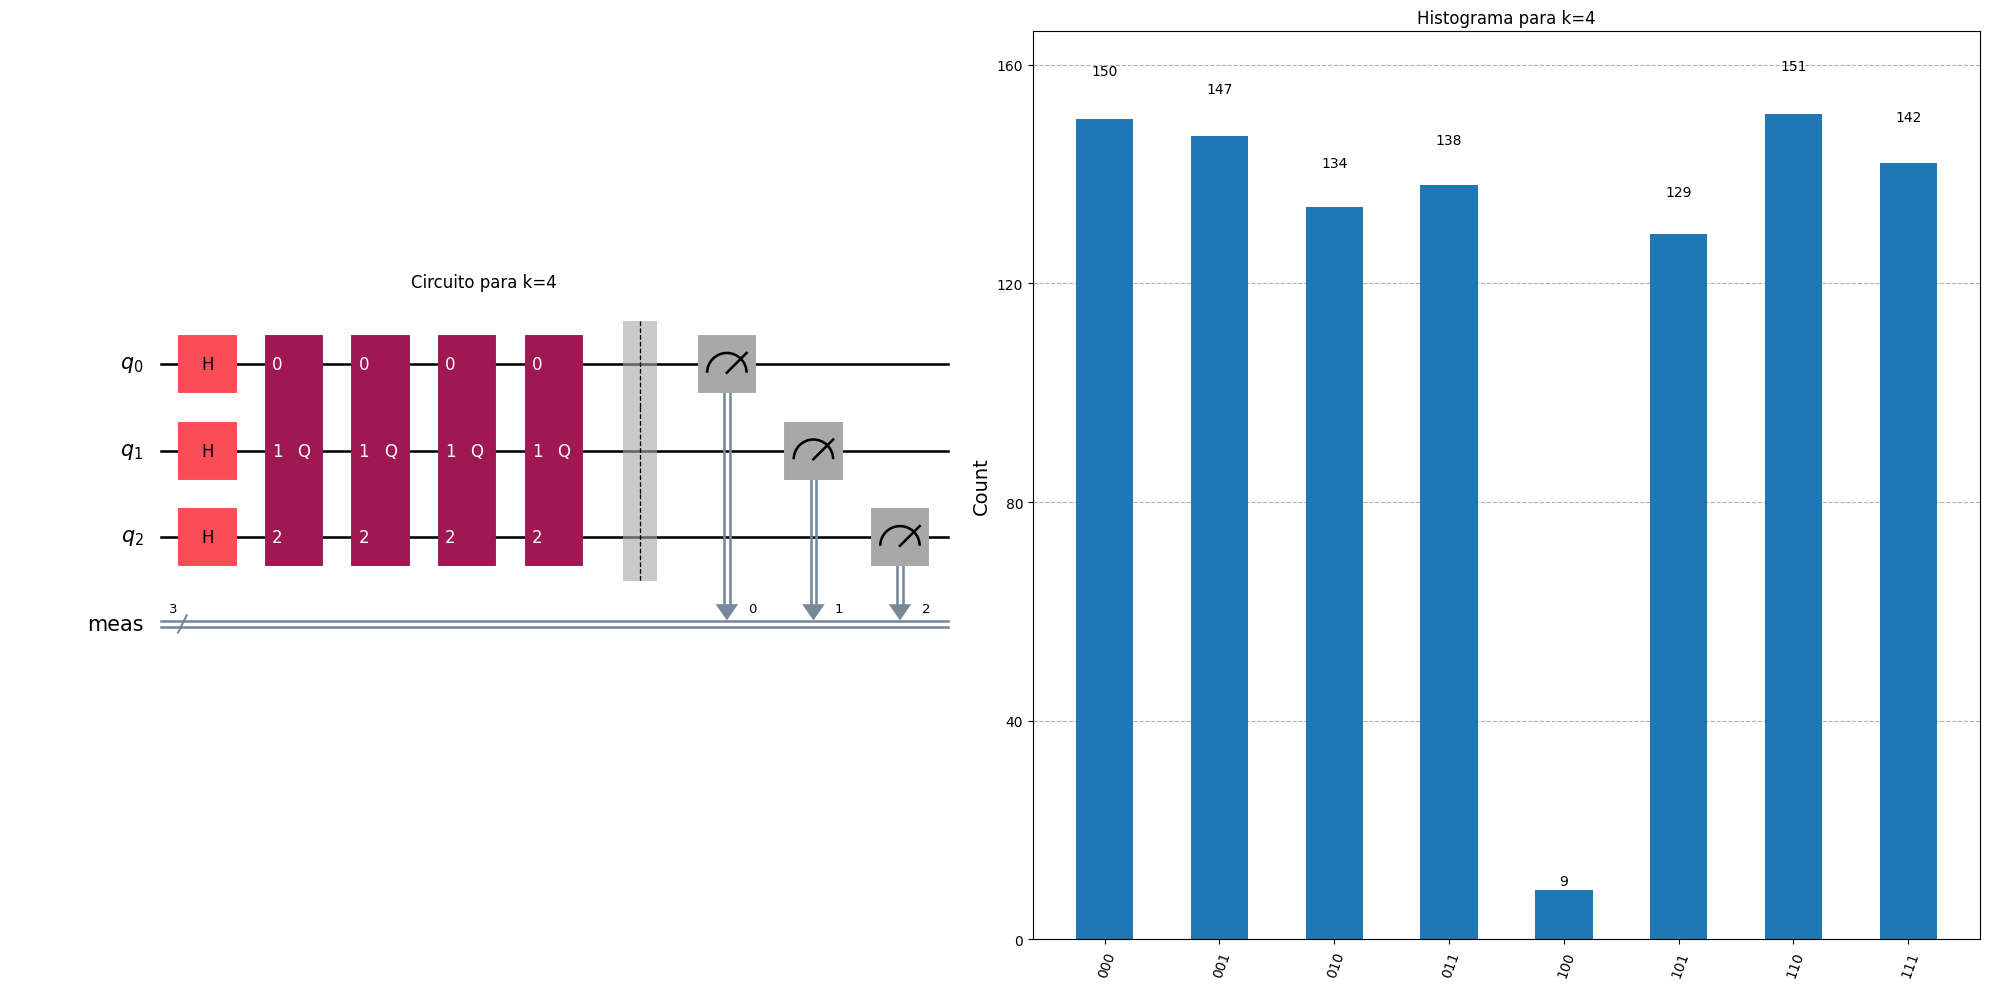

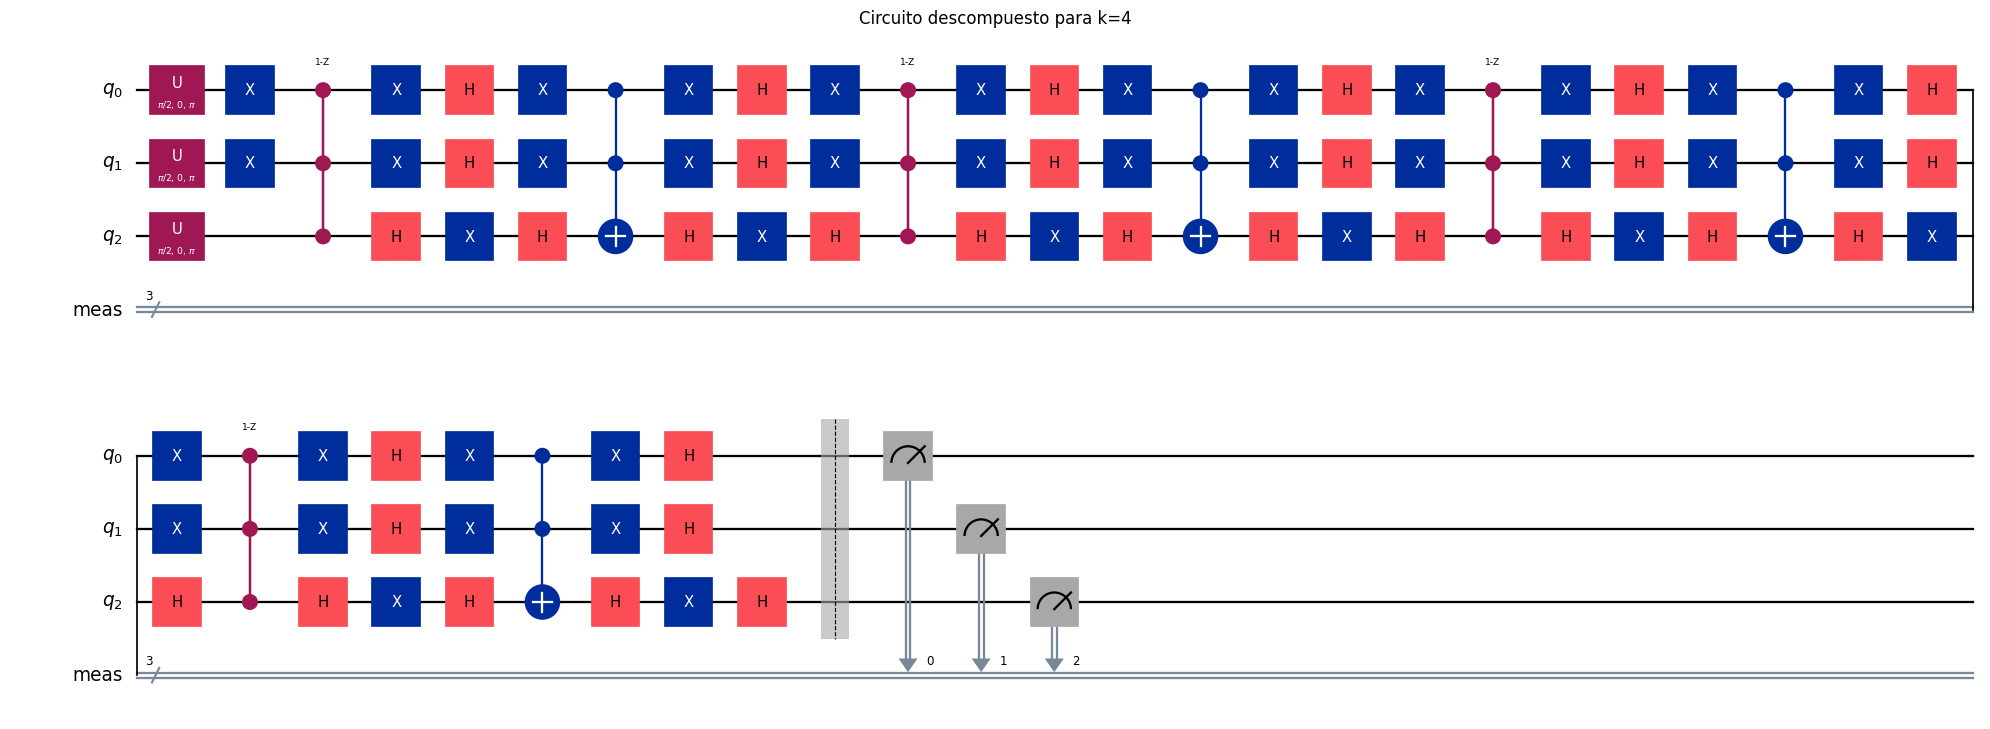

k=5:


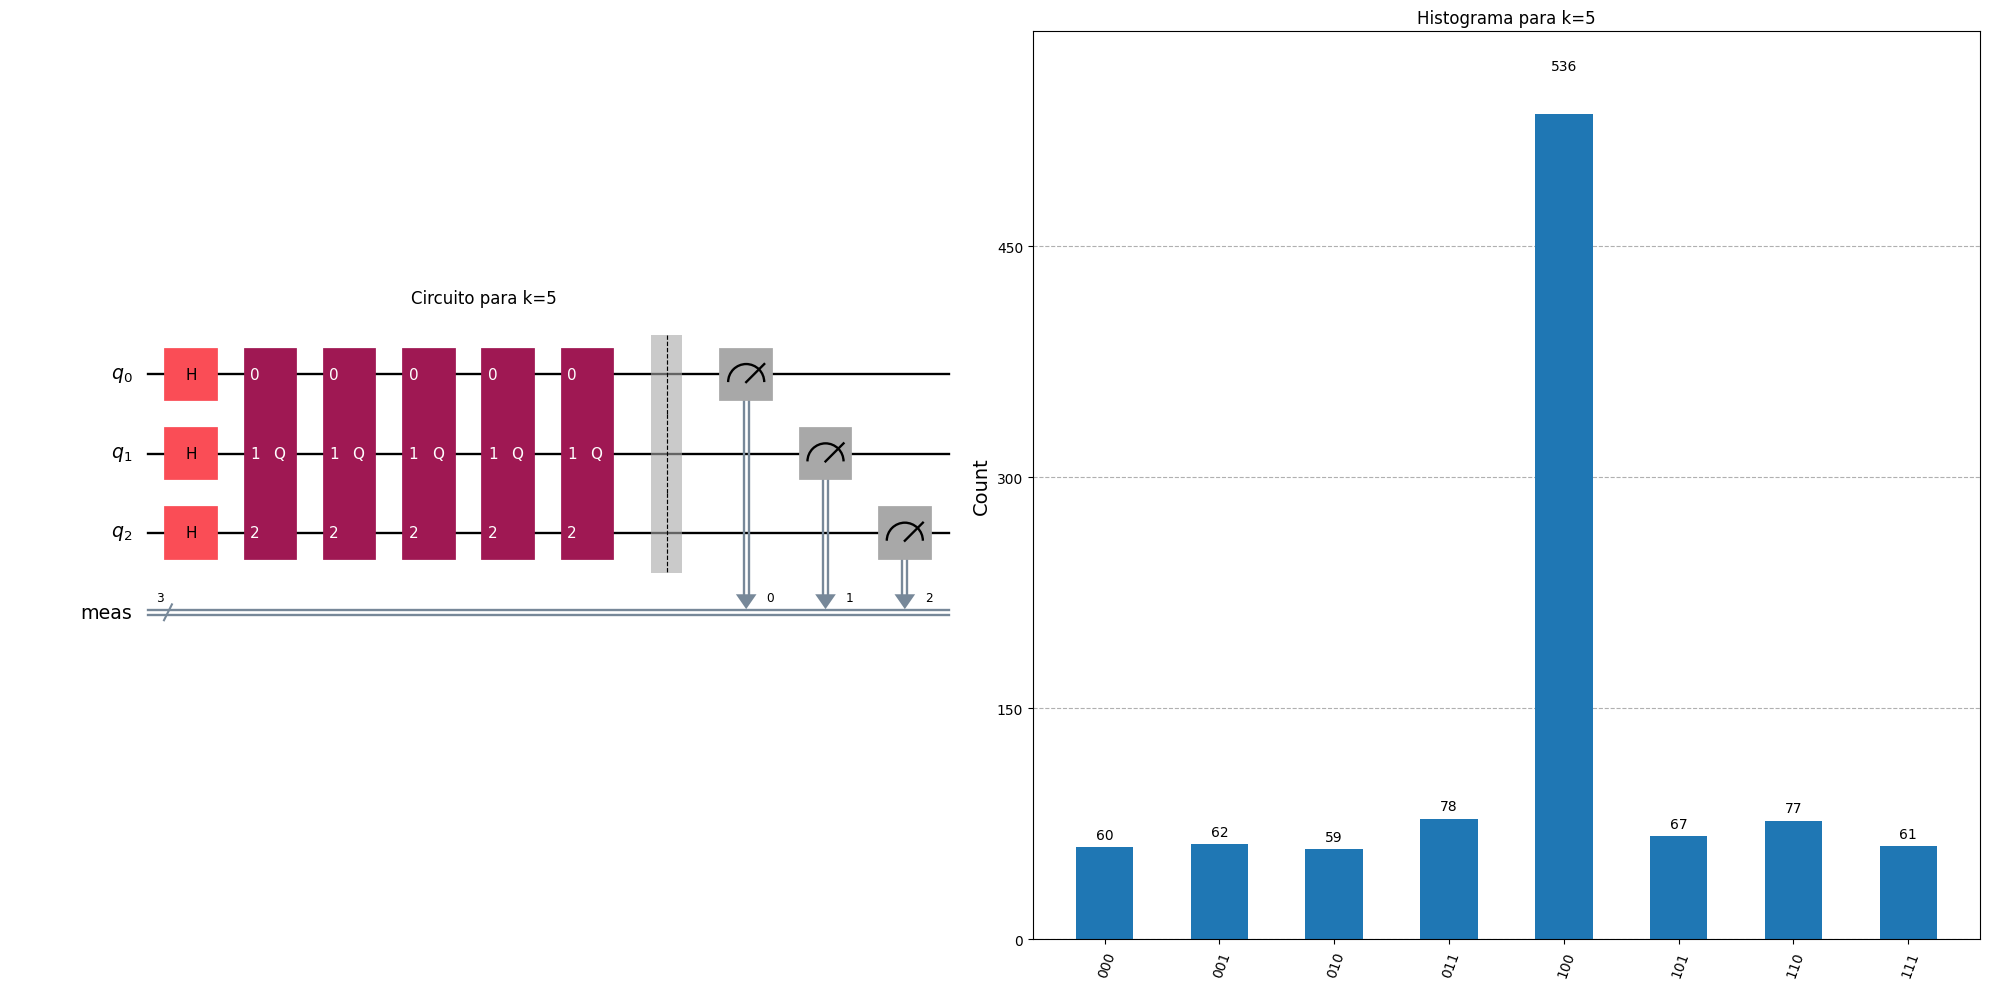

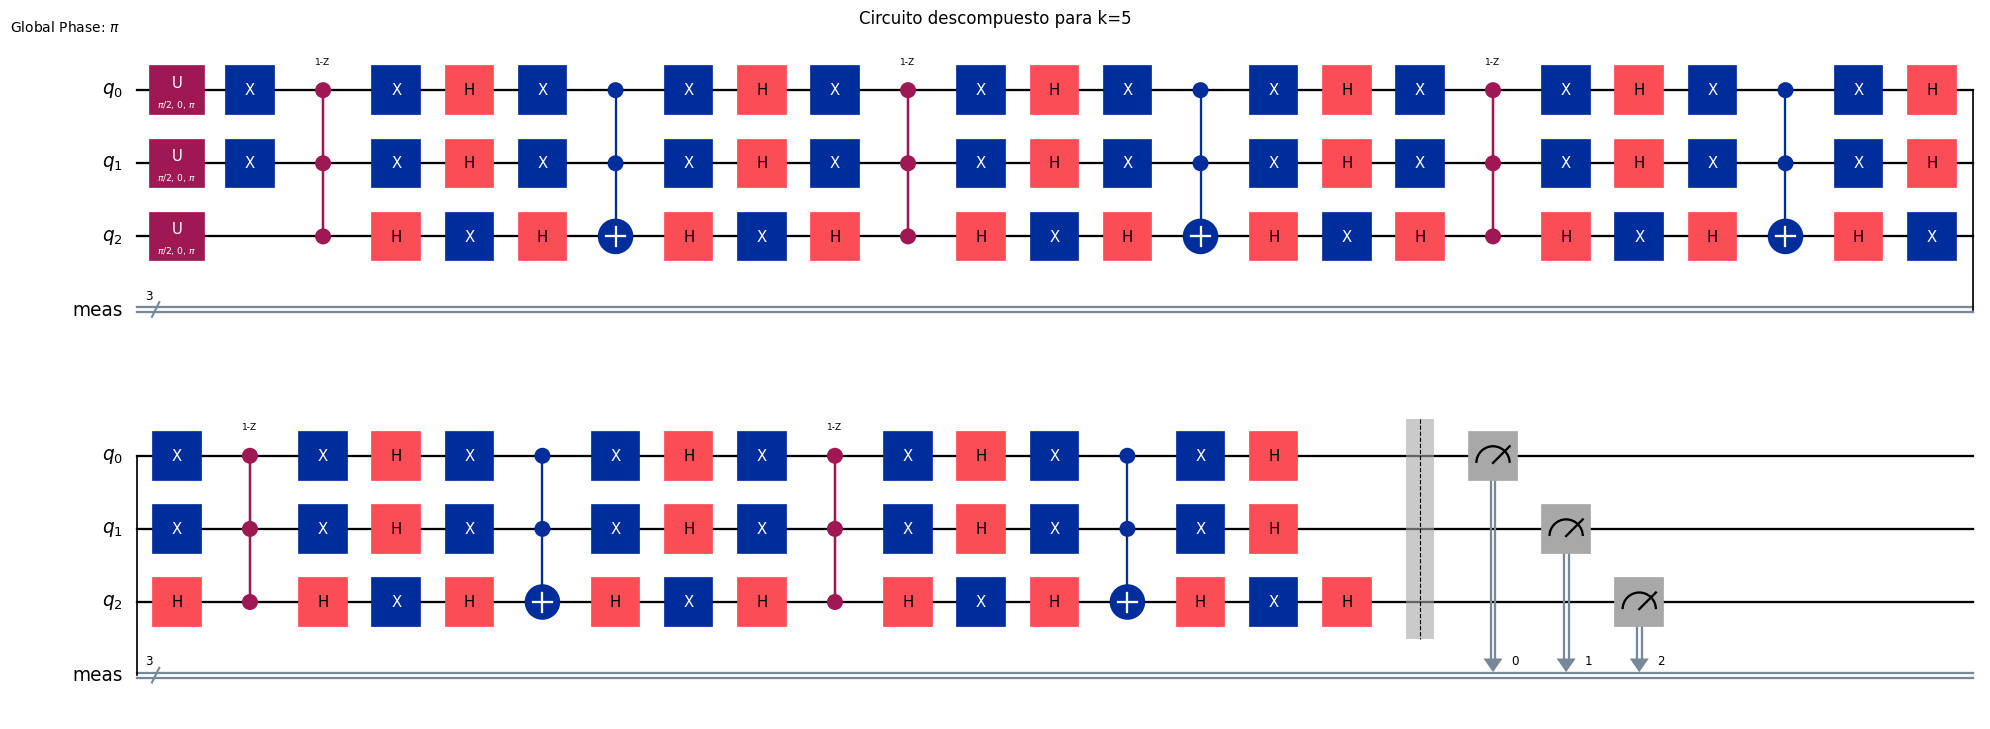

In [60]:
for k in range(1, 6):
    #Crear circuito vacñio
    qc = QuantumCircuit(num_qubits1)

    #Aplicar puertas Hadamard para crear superposición
    qc.h(range(num_qubits1))

    #Aplicar k iteraciones del operador de Grover
    qc.compose(grover_op1.power(k), inplace=True)

    #Simulación
    sv = Statevector.from_instruction(qc)
    #Obtener estadísicas
    statistics = sv.sample_counts(1000)
    qc.measure_all()

    print(f"k={k}:")
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    qc.draw(output="mpl", style="iqp", ax=ax1)
    ax1.set_title(f"Circuito para k={k}")

    plot_histogram(statistics, ax=ax2)
    ax2.set_title(f"Histograma para k={k}")

    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 1)

    ax1 = fig.add_subplot(gs[0, 0])
    qc.decompose().draw(output="mpl", style="iqp", ax=ax1)
    ax1.set_title(f"Circuito descompuesto para k={k}")

    plt.tight_layout()
    plt.show()

    """display(qc.draw(output="mpl", style="iqp"))
    display(qc.decompose().draw(output="mpl", style="iqp"))
    display(plot_histogram(statistics))"""

Se obtiene la máxima probabilidad de obtener la solución de forma experimental con 2 iteraciones.

In [61]:
#Cálculo del valor teorico de iteraciones
it_teoricas1 = (math.pi/4)*math.sqrt(q1**n1)
print("Valor teorico de iteraciones:", it_teoricas1)
entero1 = math.floor((math.pi/(4*math.asin(1/math.sqrt(q1**n1))))-(1/2))
print("Valor entero de iteraciones:", entero1)

Valor teorico de iteraciones: 2.221441469079183
Valor entero de iteraciones: 1


Los valores téoricos coinciden con el resultado experimental obtenido ya que la diferencia entre la iteración 1 y 2 realmente no es demasiado grande y encaja perfectamente con el resultado obtenido en el cálculo de iteraciones óptimas teóricas.

### Caso de prueba 2:

In [62]:
n2 = 2
m2 = 5
q2 = 4
num_qubits2 = 4
num_bits2 = int(np.ceil(np.log2(q2)))

In [63]:
#Generar instancia LWE
A2, s2, e2, b2 = generar_lwe(n2, m2, q2)

display(array_to_latex(A2, prefix="A2"))
display(array_to_latex(s2, prefix="s2"))
display(array_to_latex(e2, prefix="e2"))
display(array_to_latex(b2, prefix="b2"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [64]:
#Calcular residuo
r2 = calcular_residuo(A2, s2, b2, q2)

display(array_to_latex(r2, prefix="r2"))

<IPython.core.display.Latex object>

In [65]:
#Comprobar condición 
print("s2 cumple condicion:", cumple_condicion(r2, q2))

s2 cumple condicion: True


s en bits: [1 1 0 1]


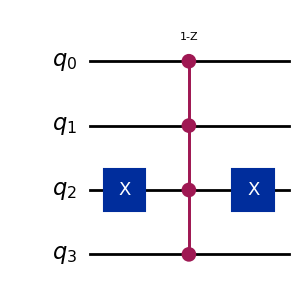

In [66]:
#Crear el circuito del oráculo de fase
circuito2 = oracle(num_qubits2, num_bits2, s2, n2)
display(circuito2.draw(output="mpl"))

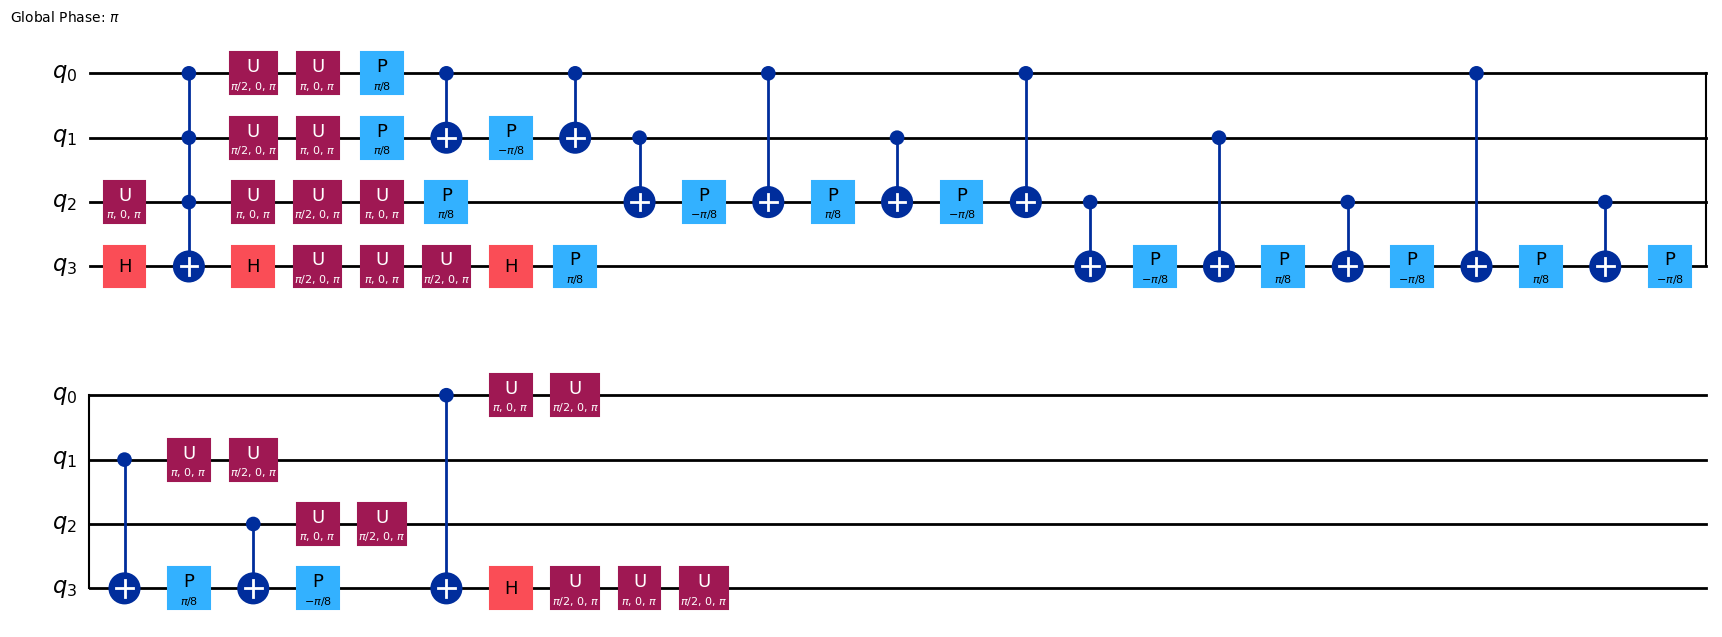

In [67]:
#Construir el operador de Grover
grover_op2 = grover_operator(circuito2)
grover_op2.decompose().draw(output="mpl", style="iqp")

k=1:


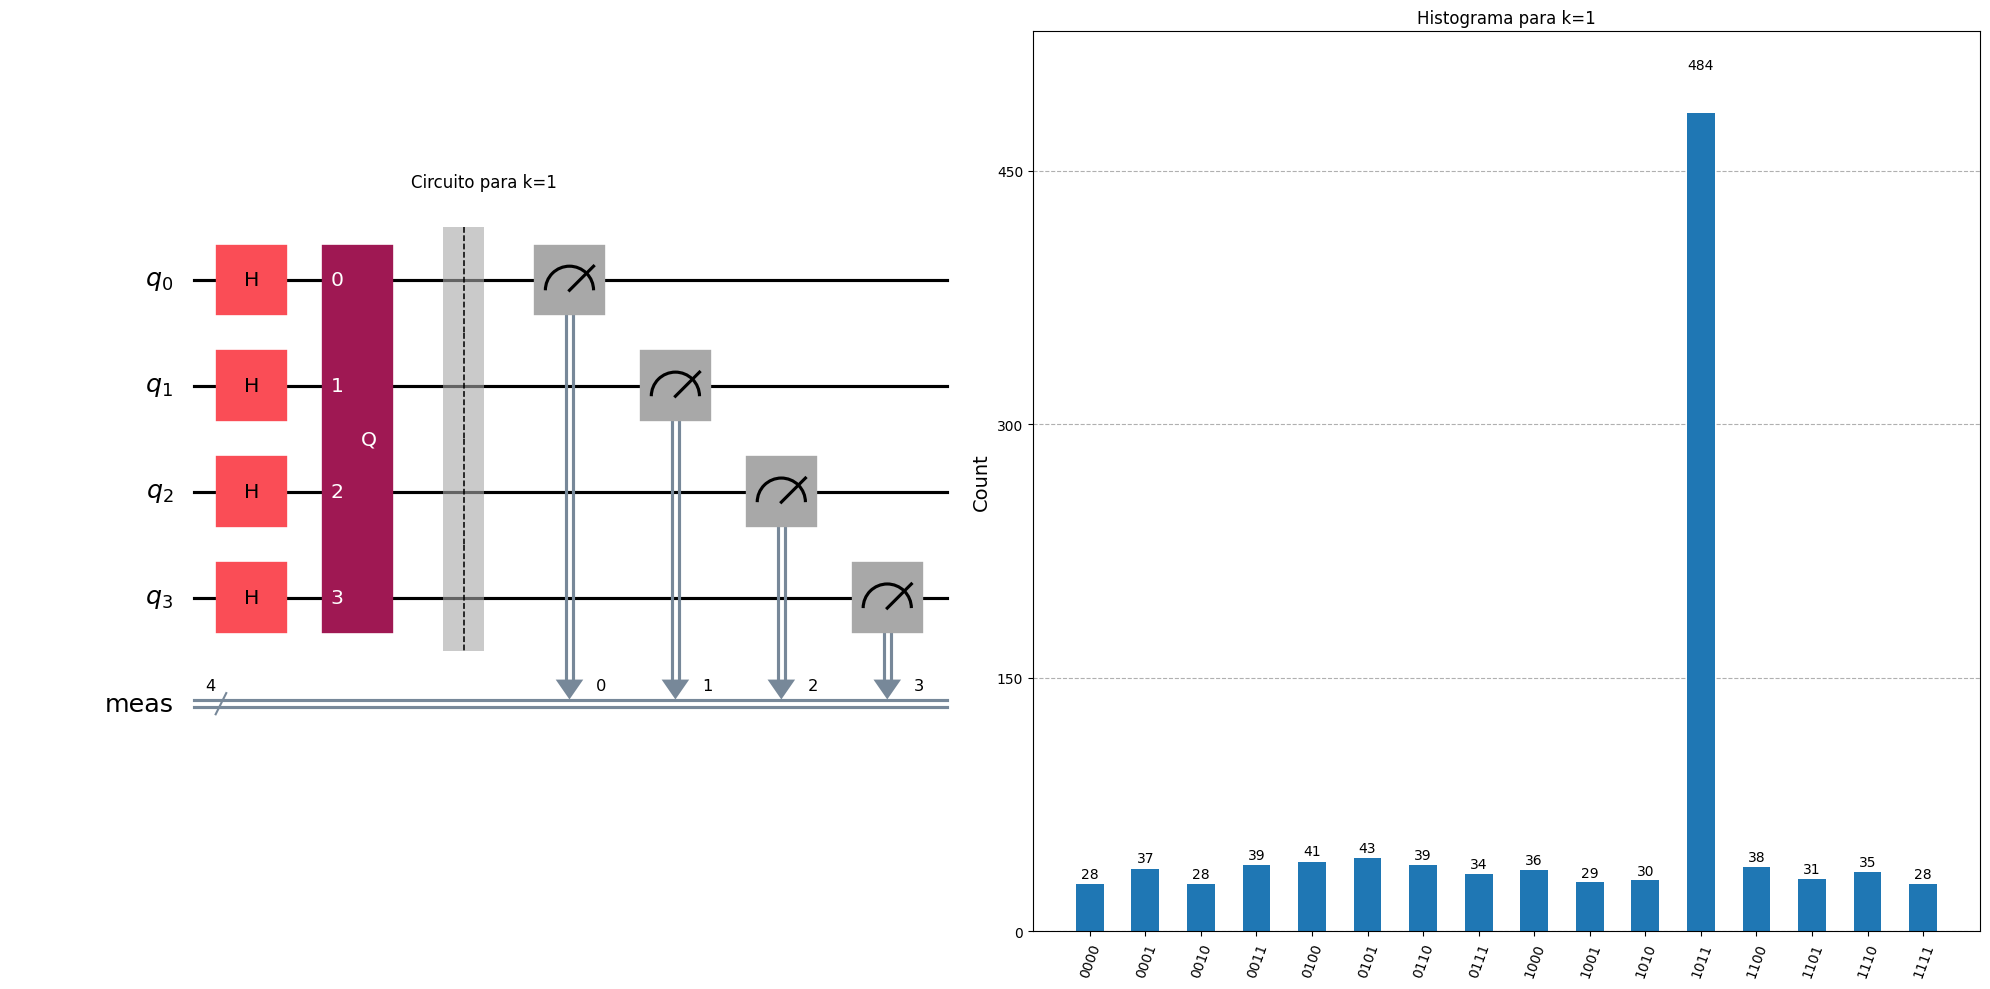

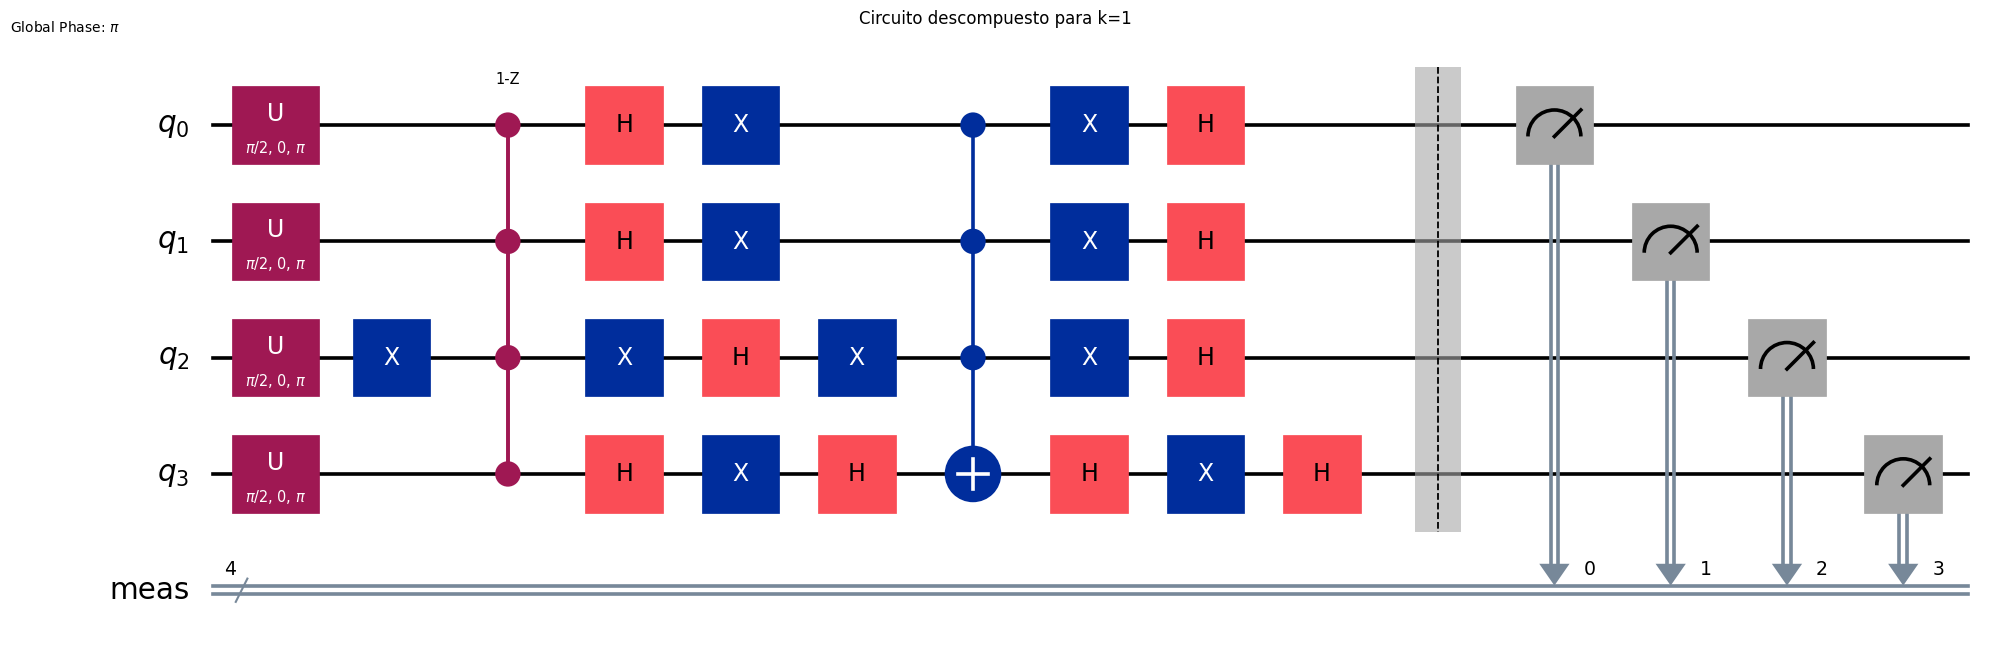

k=2:


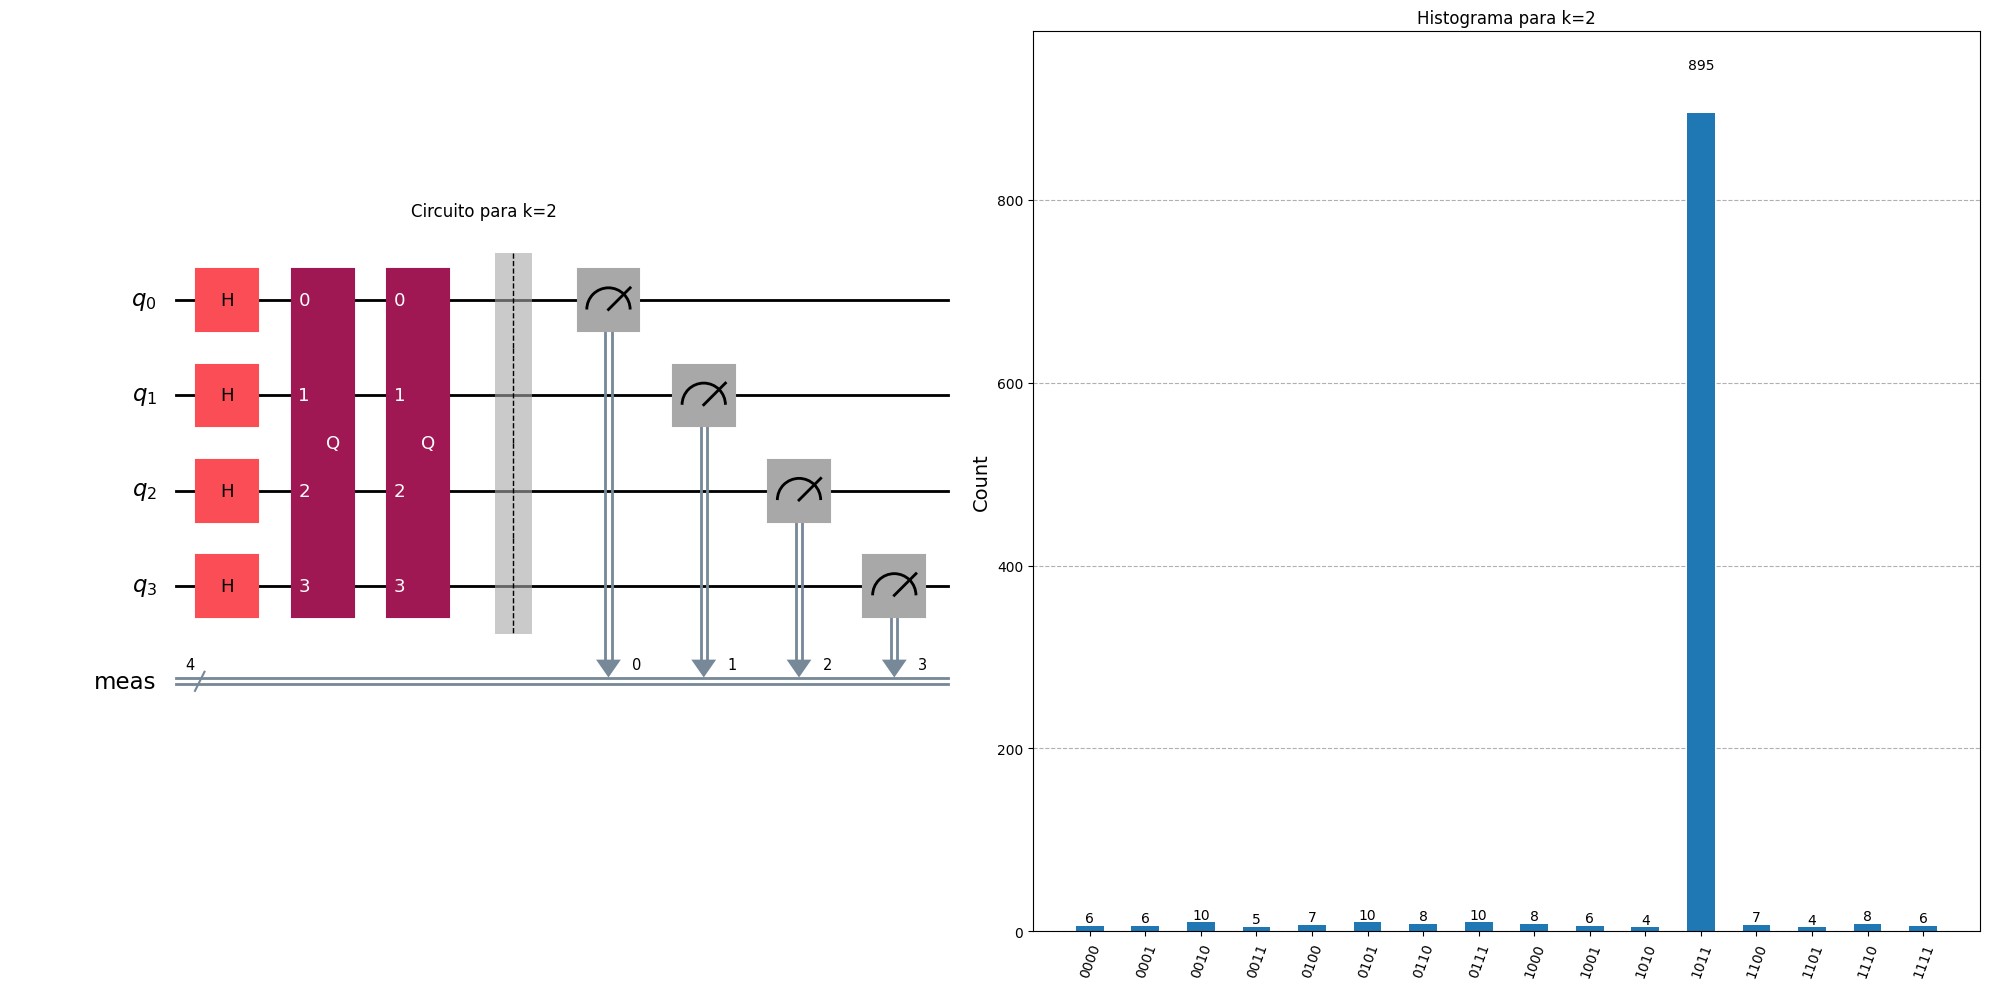

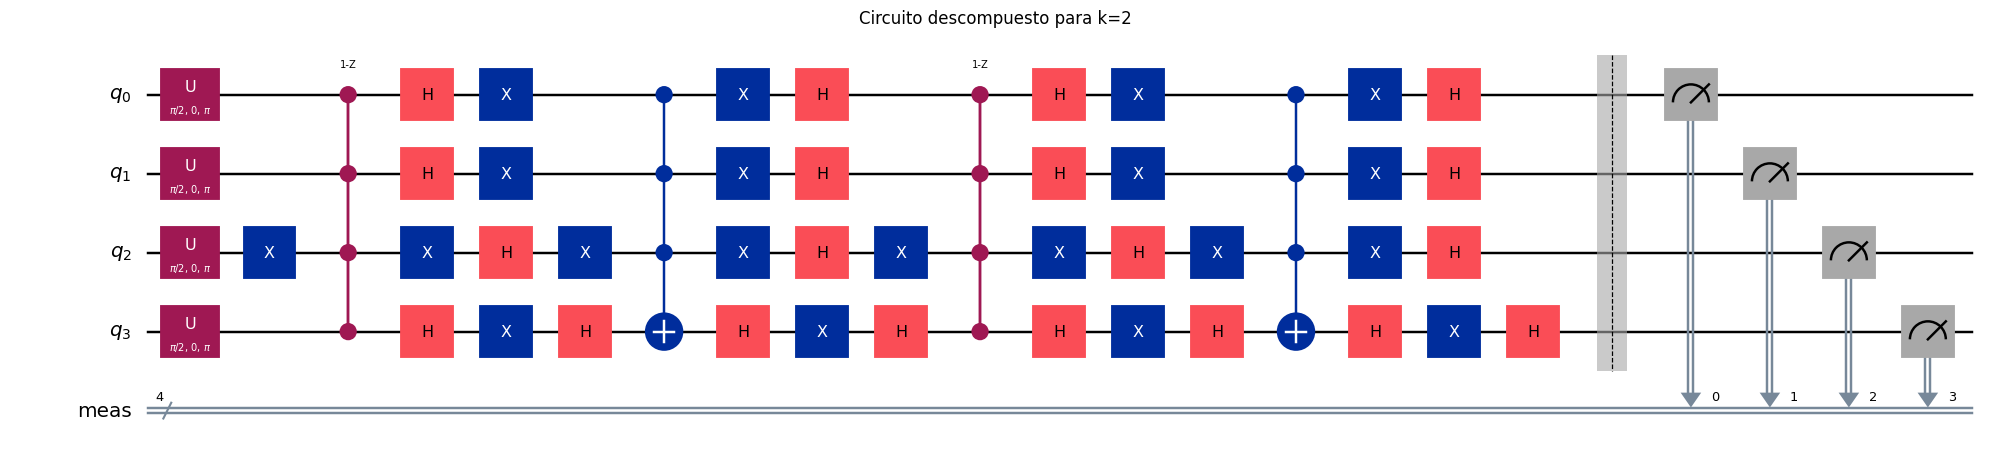

k=3:


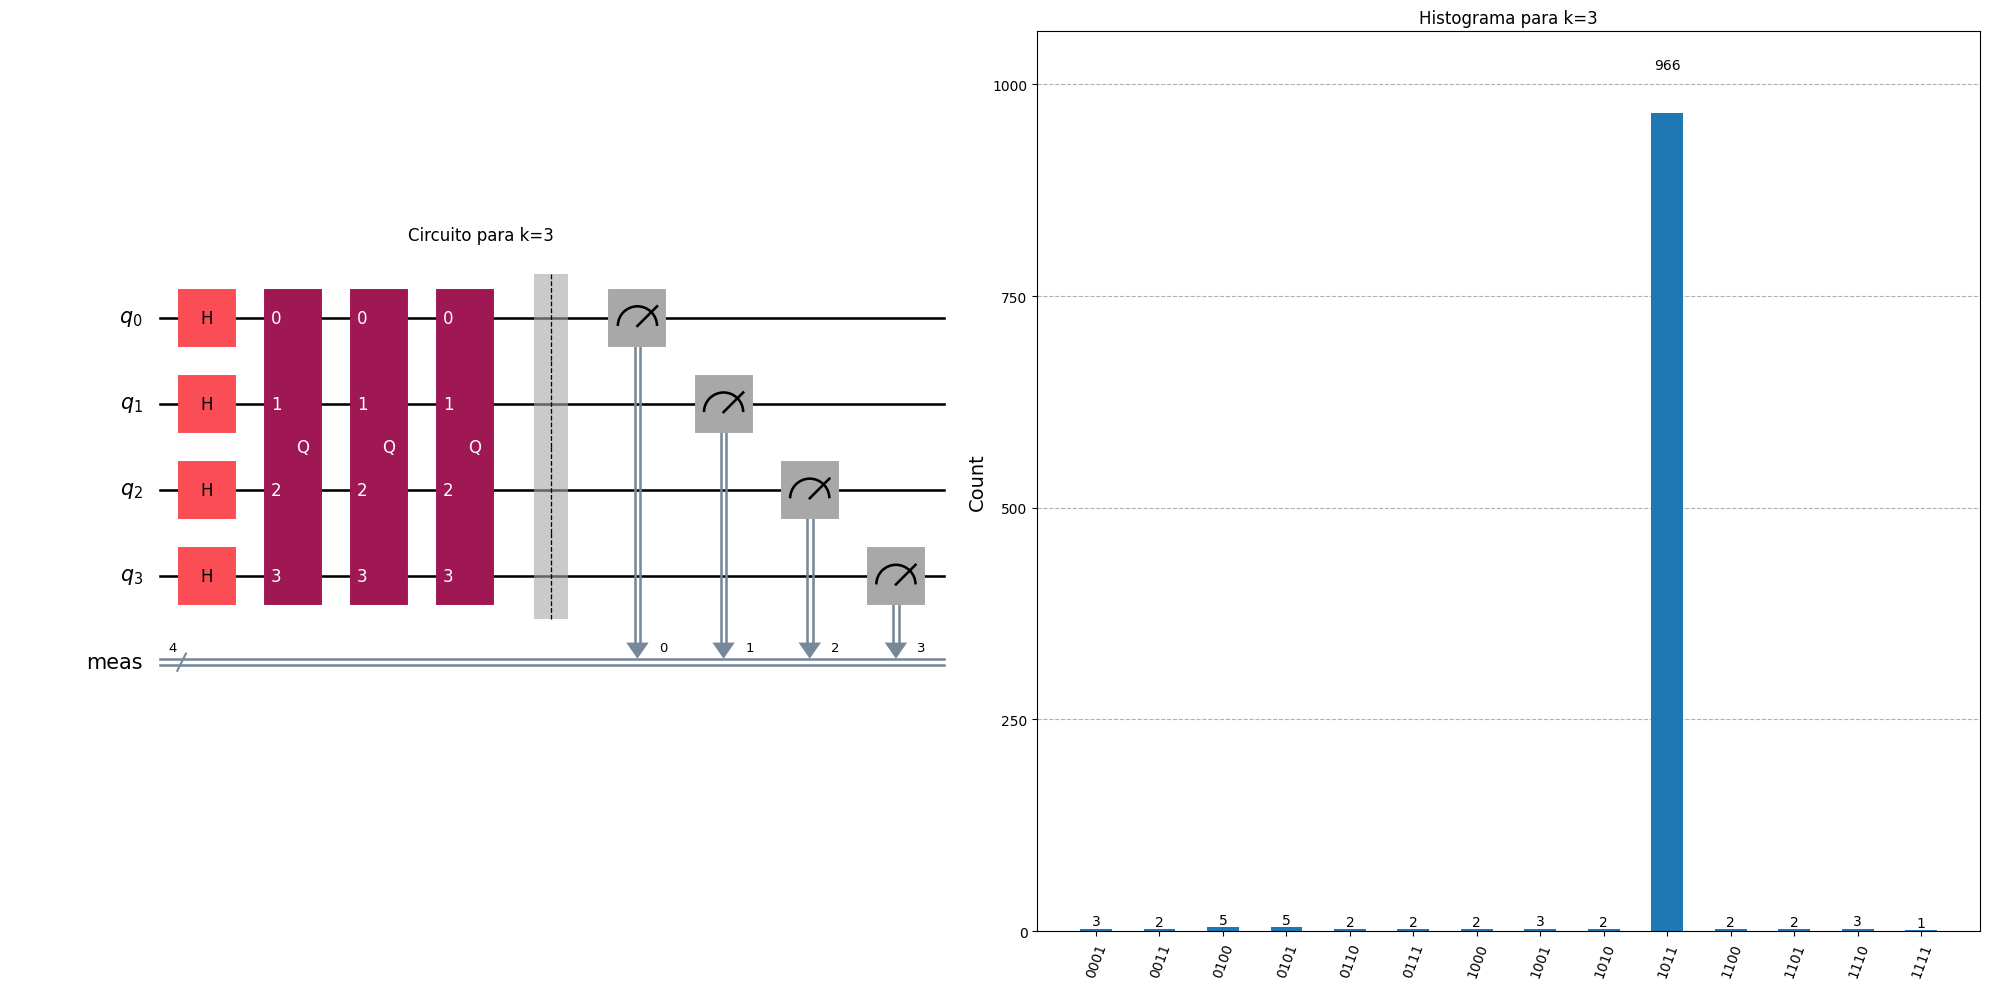

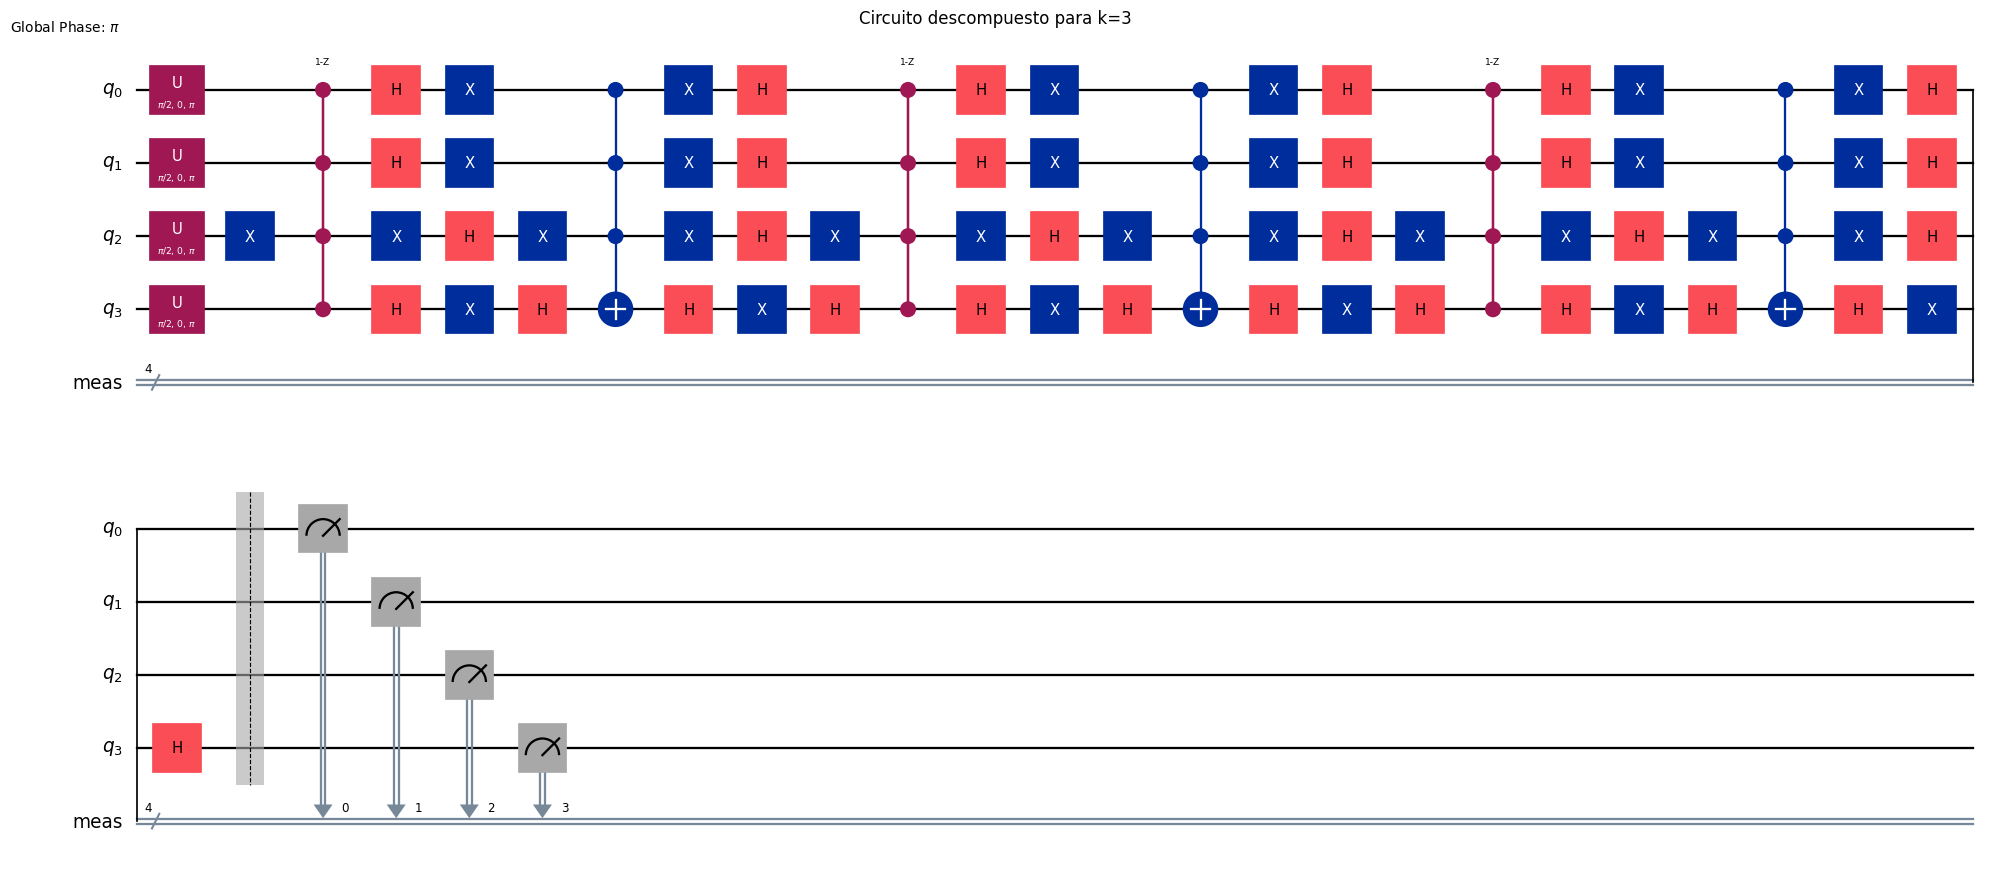

k=4:


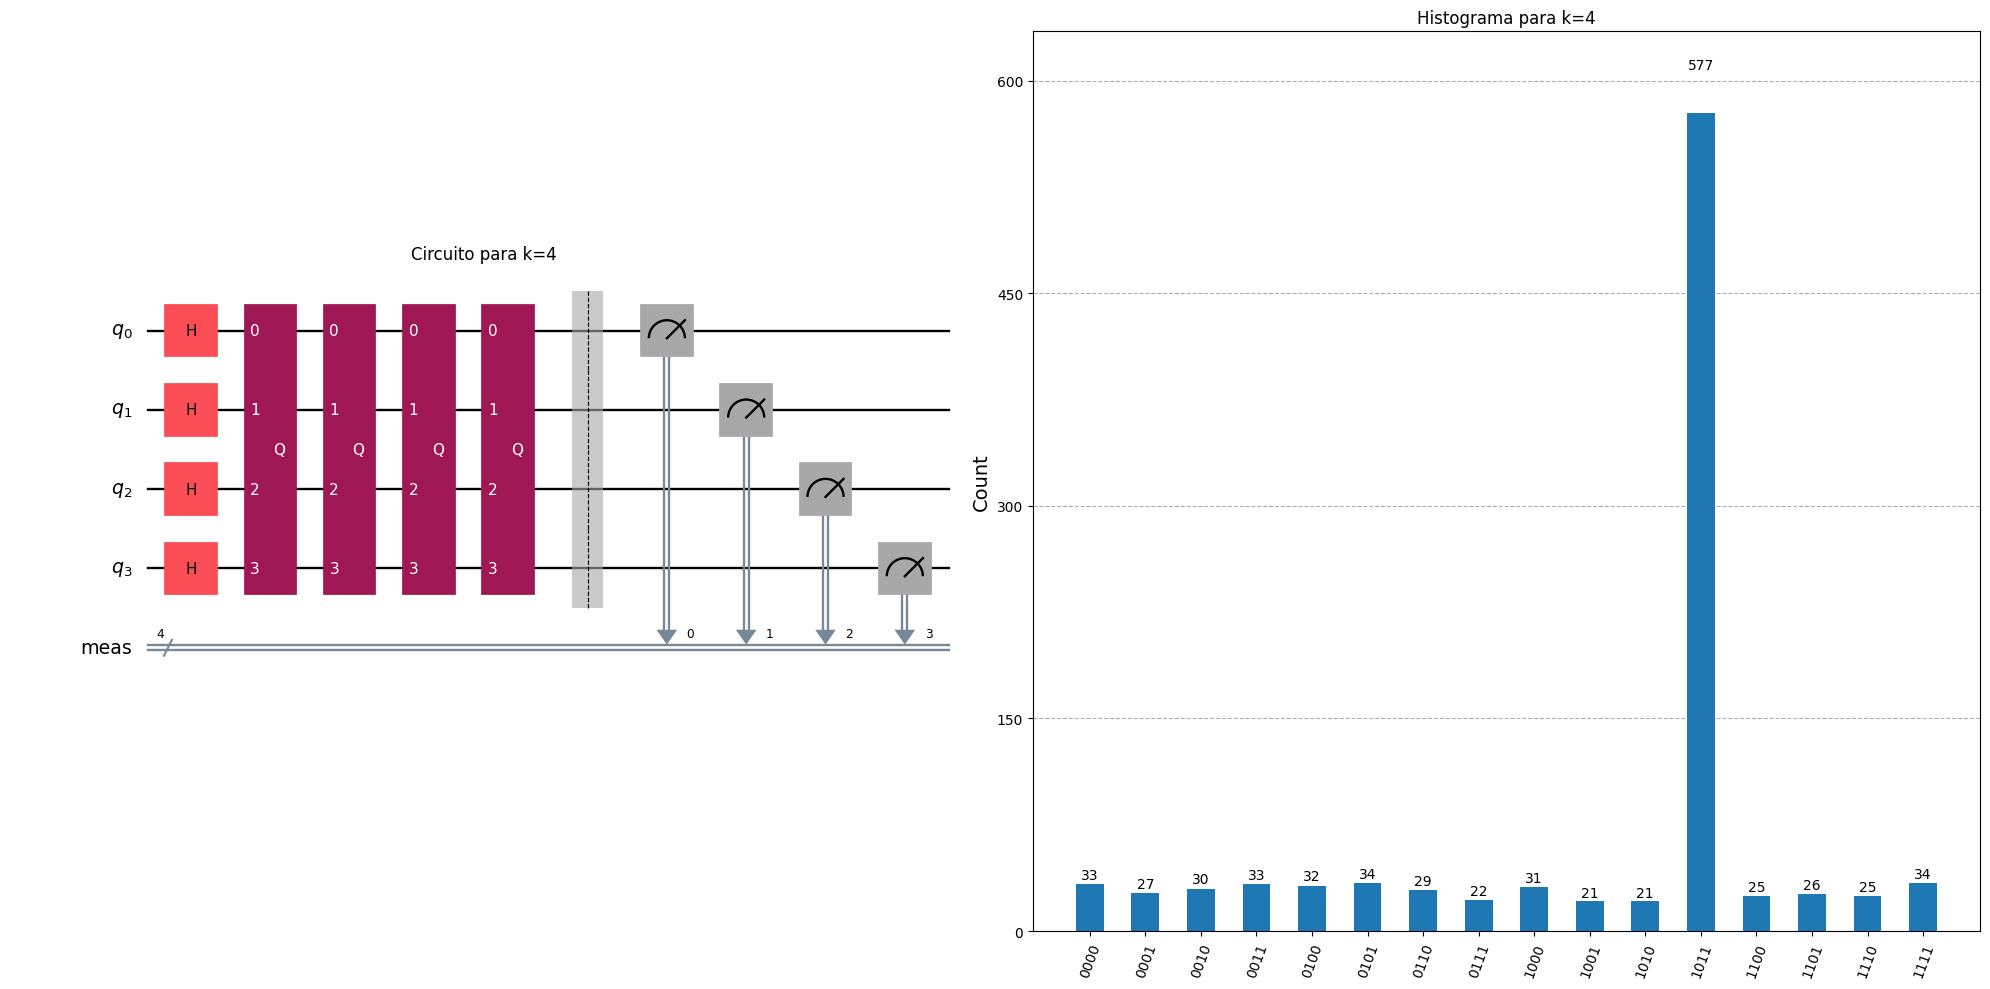

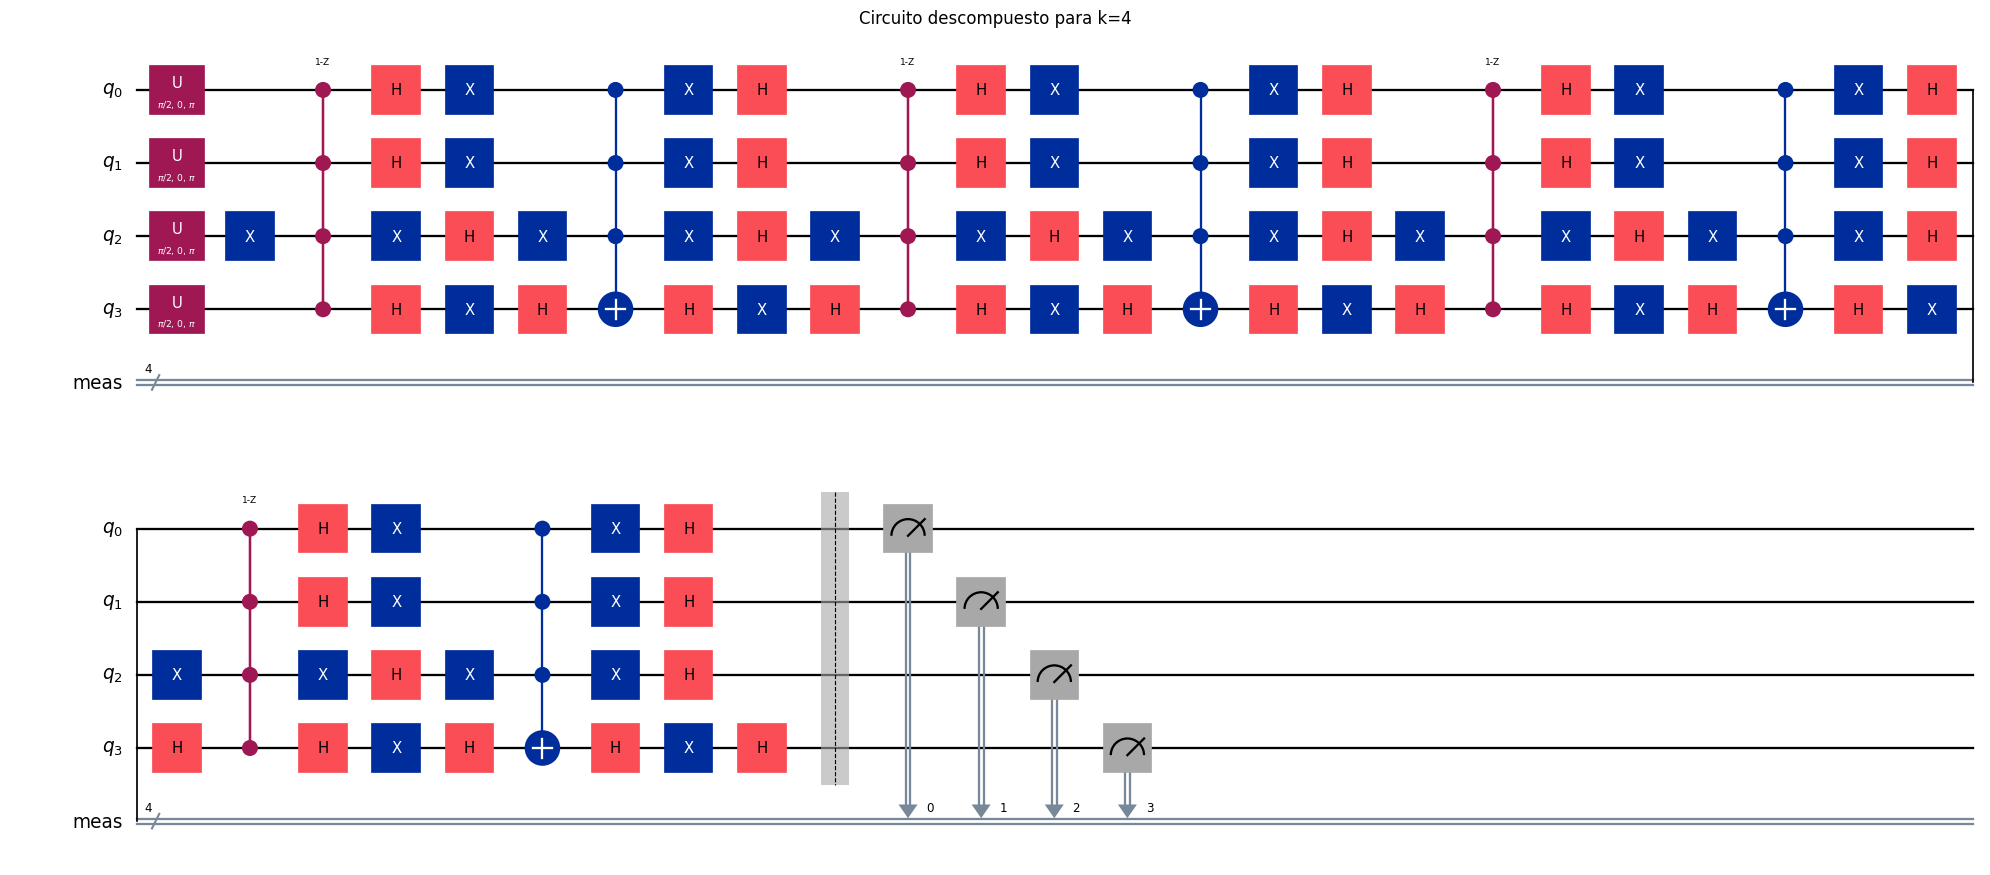

k=5:


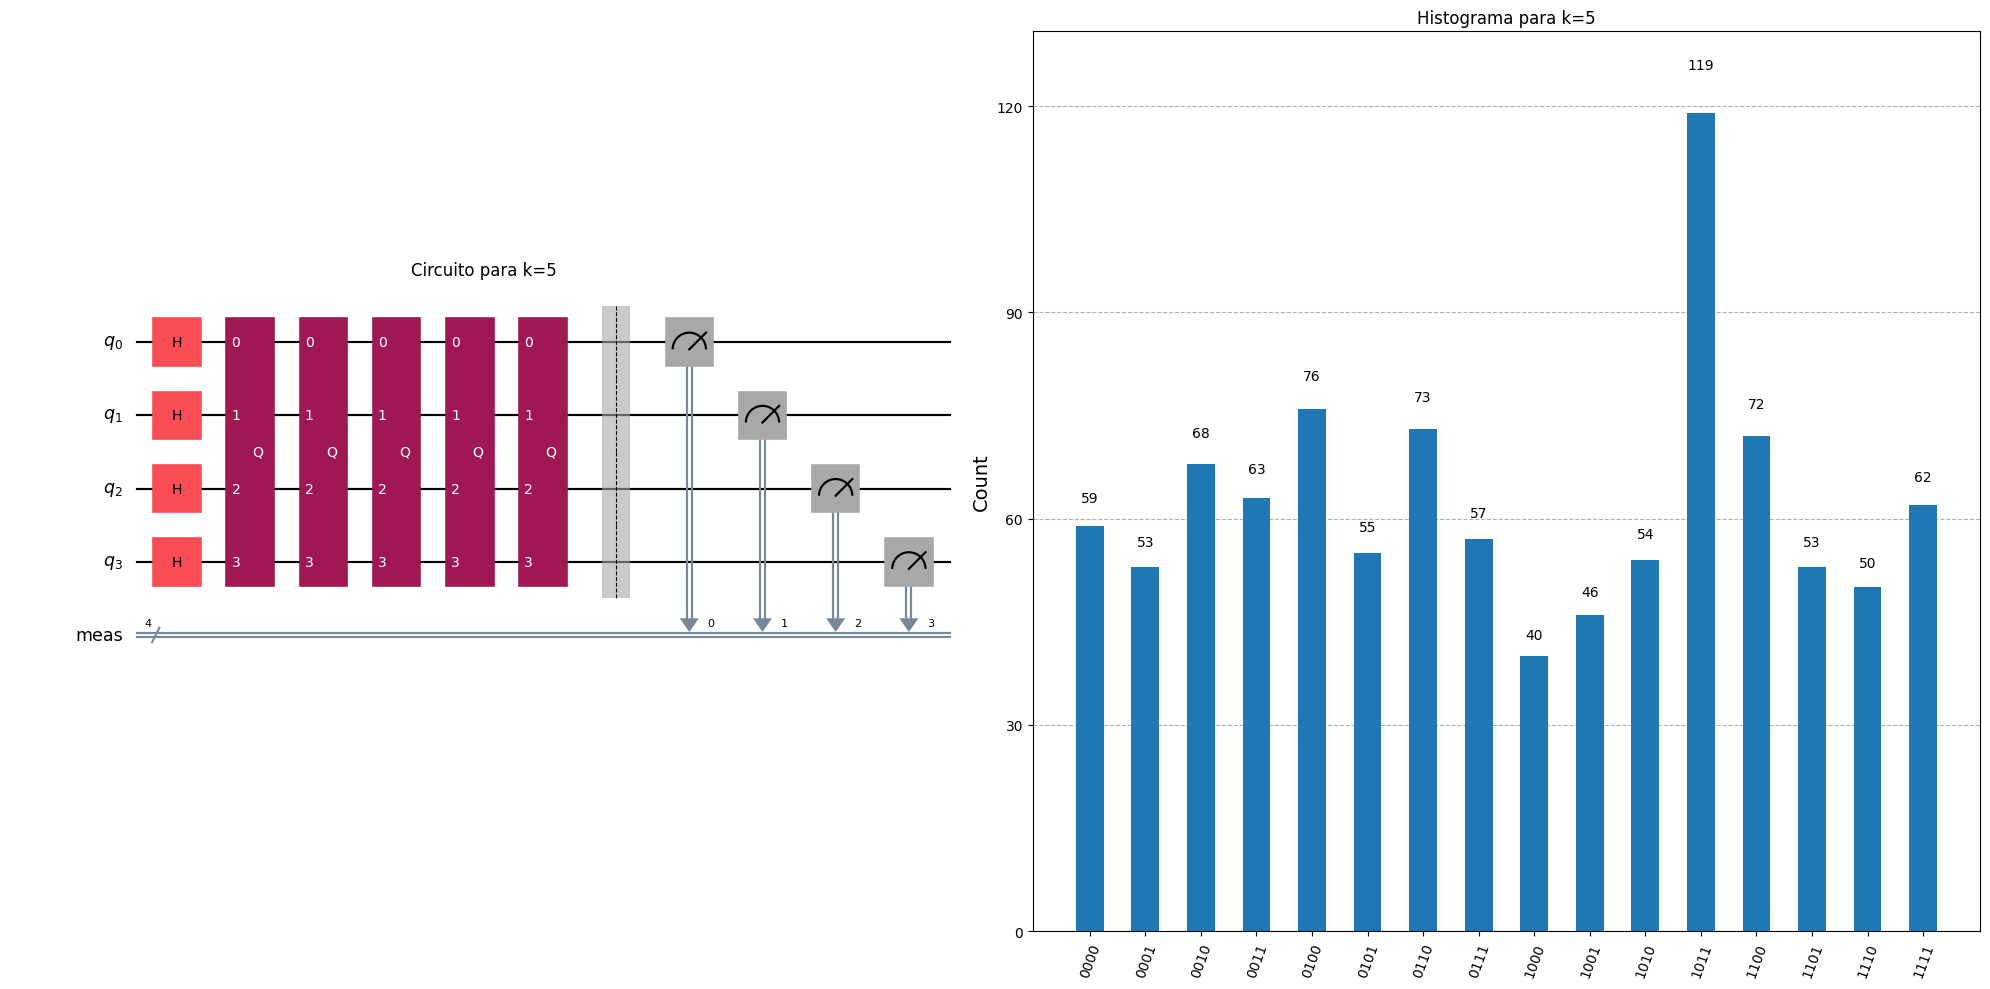

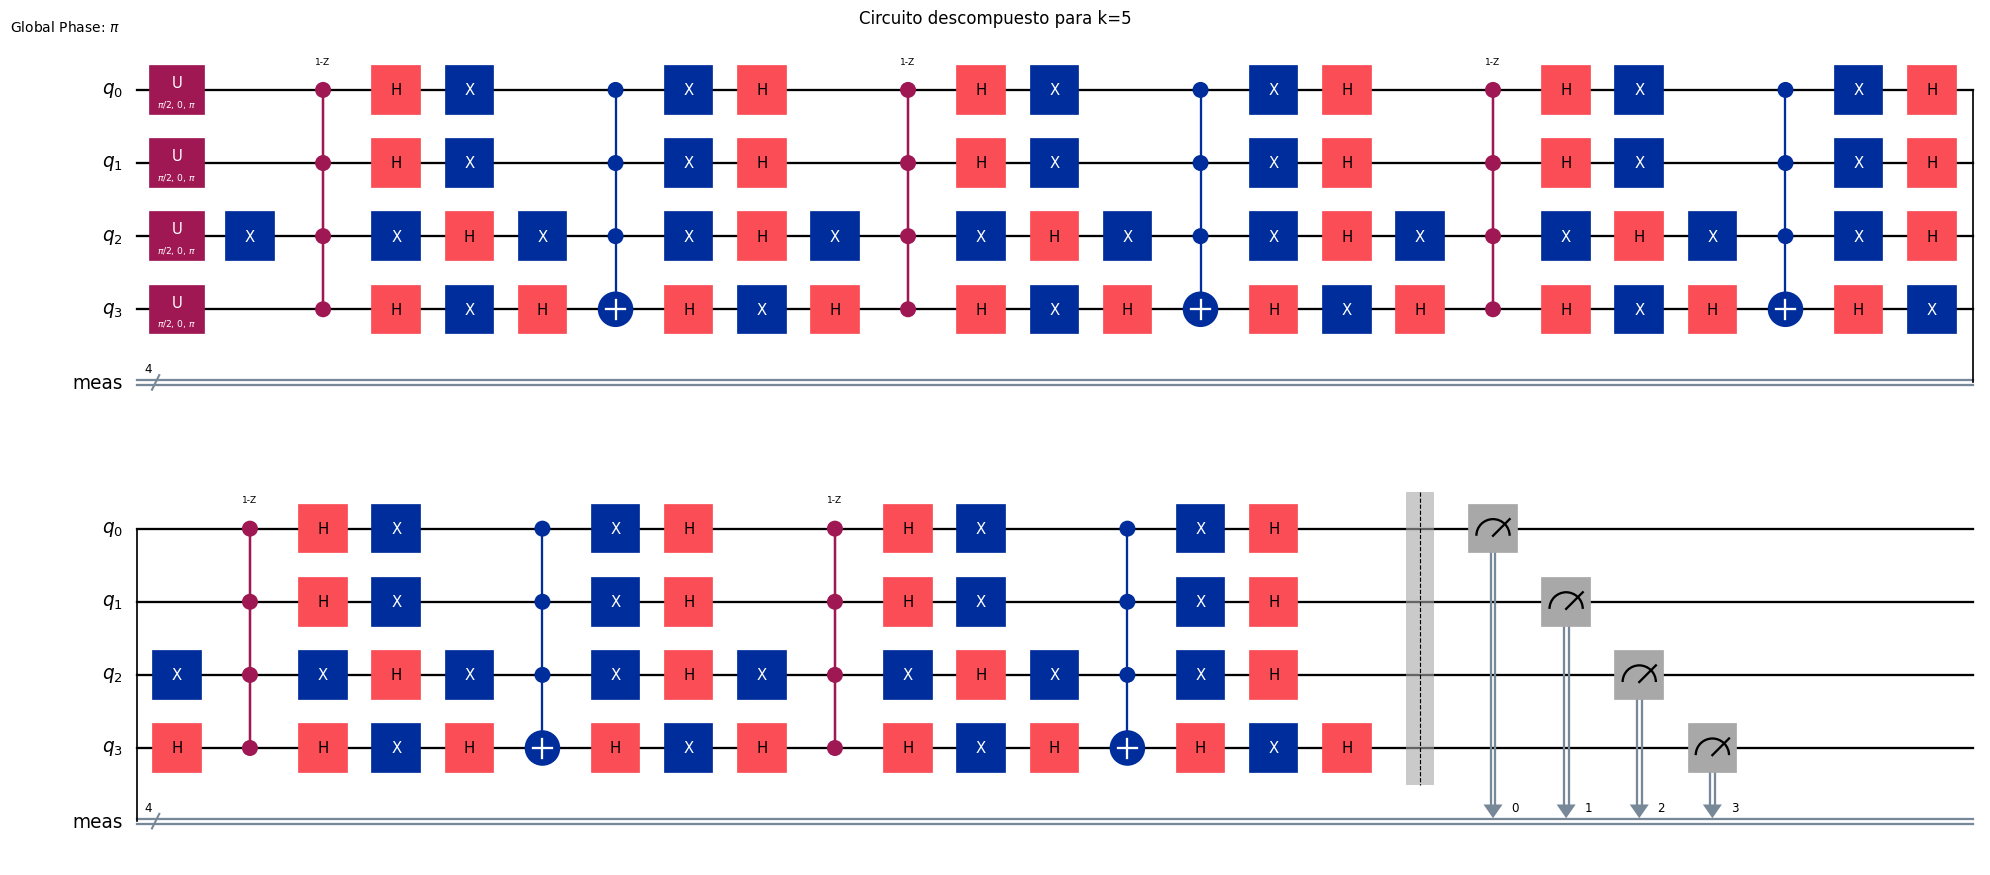

k=6:


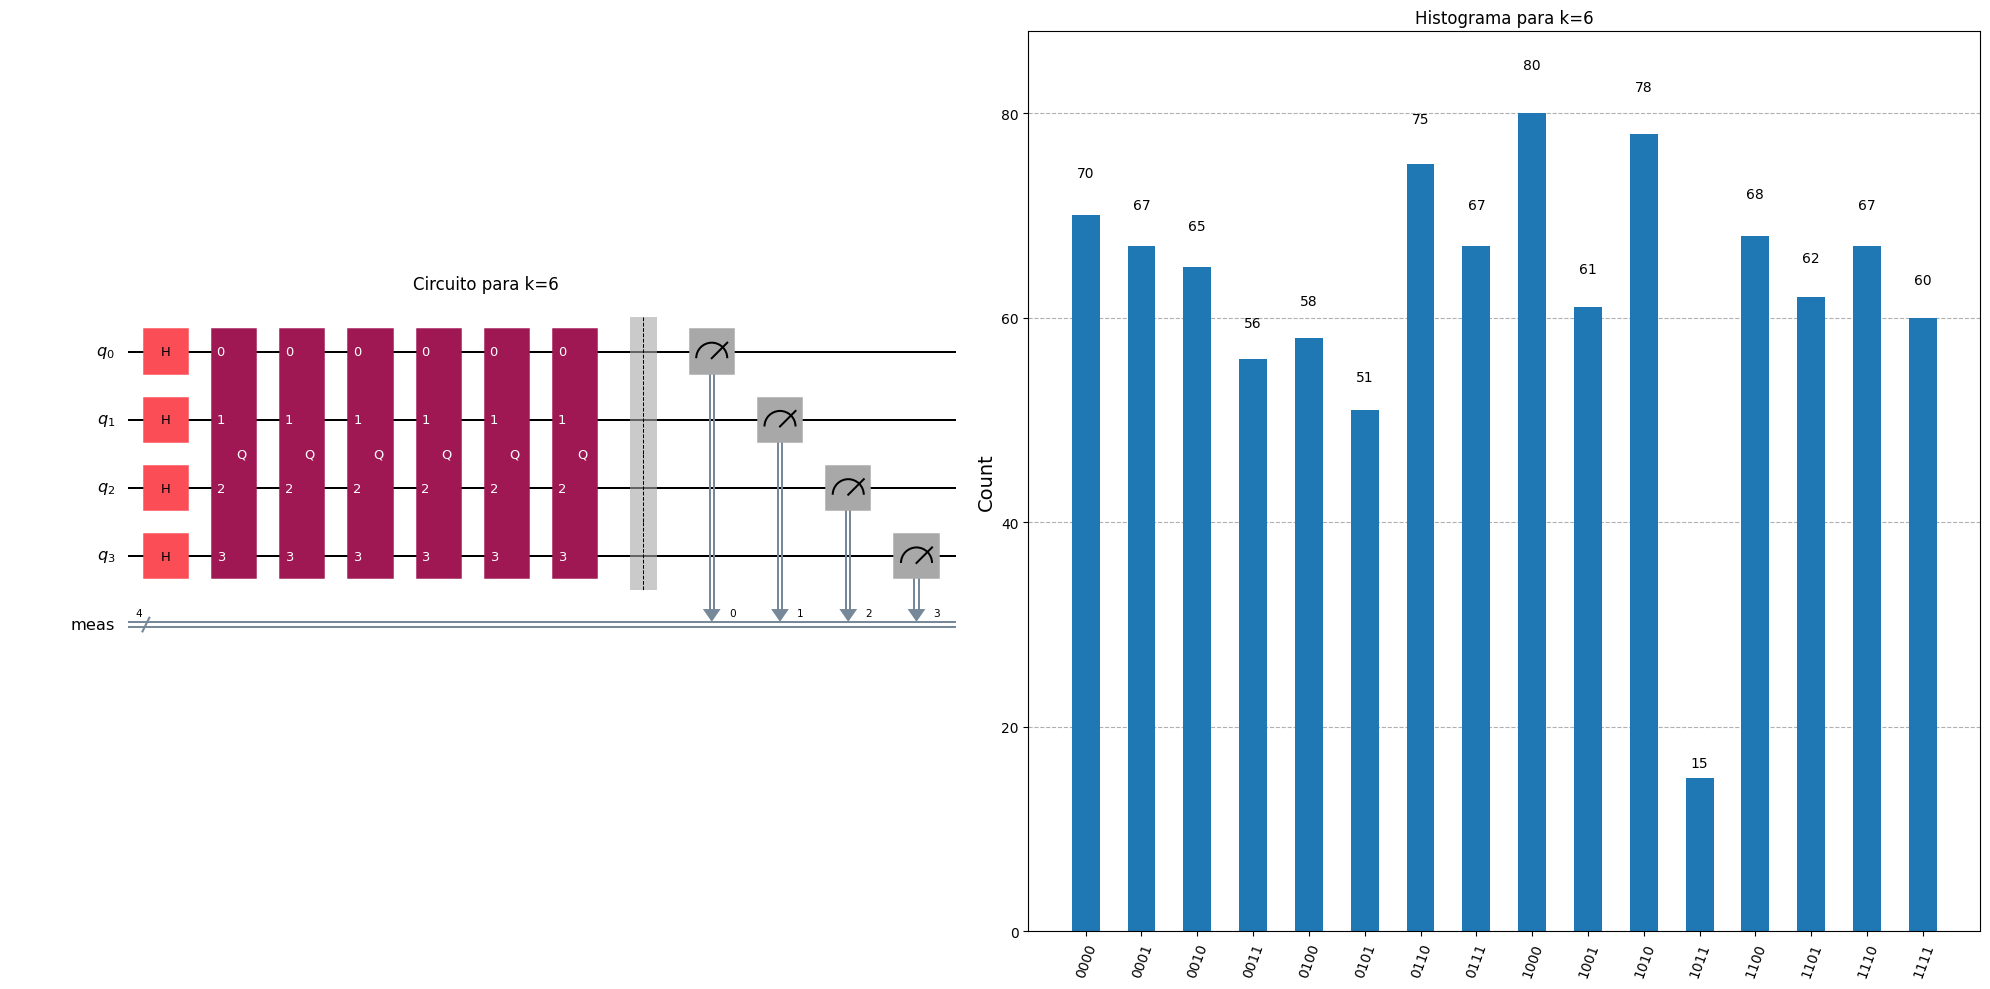

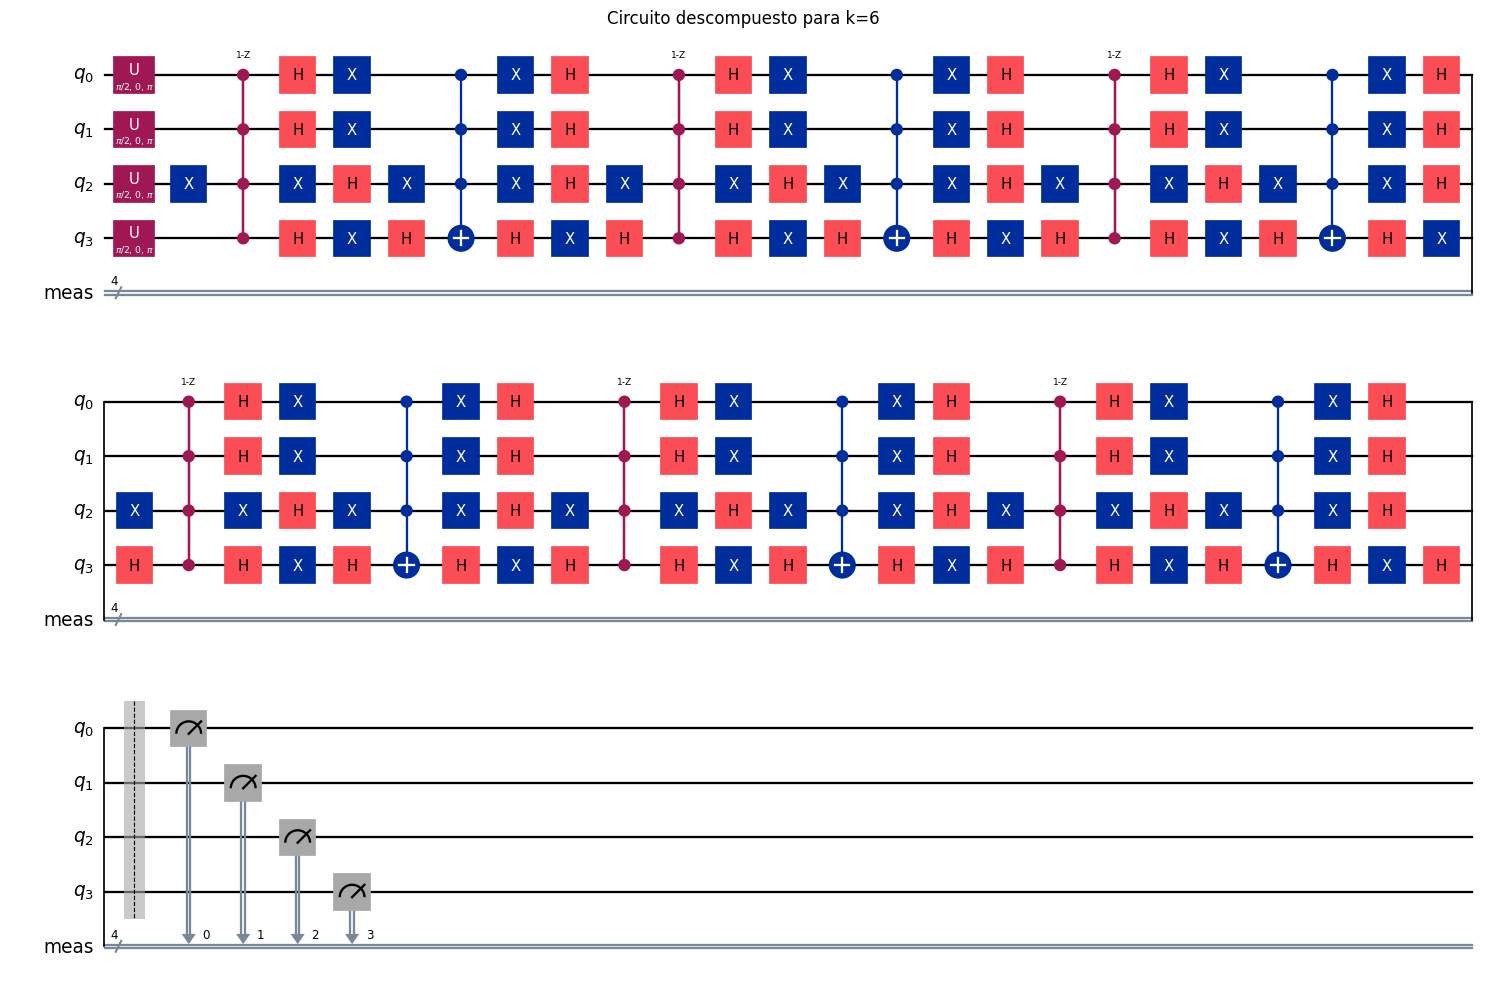

In [68]:
for k in range(1, 7):
    #Crear circuito vacío
    qc = QuantumCircuit(num_qubits2)

    #Aplicar puertas Hadamard para crear superposición
    qc.h(range(num_qubits2))

    #Aplicar k iteraciones del operador de Grover
    qc.compose(grover_op2.power(k), inplace=True)

    #Simulación
    sv = Statevector.from_instruction(qc)
    #Obtener estadísicas
    statistics = sv.sample_counts(1000)

    qc.measure_all()

    print(f"k={k}:")
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    qc.draw(output="mpl", style="iqp", ax=ax1)
    ax1.set_title(f"Circuito para k={k}")

    plot_histogram(statistics, ax=ax2)
    ax2.set_title(f"Histograma para k={k}")

    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 1)

    ax1 = fig.add_subplot(gs[0, 0])
    qc.decompose().draw(output="mpl", style="iqp", ax=ax1)
    ax1.set_title(f"Circuito descompuesto para k={k}")

    plt.tight_layout()
    plt.show()
    
    """display(qc.draw(output="mpl", style="iqp"))
    display(qc.decompose().draw(output="mpl", style="iqp"))
    display(plot_histogram(statistics))"""

Se obtiene la máxima probabilidad de obtener la solución experimentalmente con 3 iteraciones

In [69]:
#Calculo valor teórico de iteraciones
it_teoricas2 = (math.pi/4)*math.sqrt(q2**n2)
print("Valor teórico de iteraciones:", it_teoricas2)
entero2 = math.floor((math.pi/(4*math.asin(1/math.sqrt(q2**n2))))-(1/2))
print("Valor entero de iteraciones:", entero2)

Valor teórico de iteraciones: 3.141592653589793
Valor entero de iteraciones: 2


Como en el caso de prueba anterior, el resultado experimental se encuentra entre el valor óptimo teórico de iteraciones y el valor entero de iteraciones. La diferencia de probabilidad de obtener la solución entre las iteraciones 2 y 3 es aún más pequeña que en el primer caso de prueba por lo que el resultado obtenido encaja con lo esperado.

### Caso de prueba 3:

In [70]:
n3 = 2
m3 = 5
q3 = 8
num_qubits3 = 6
num_bits3 = int(np.ceil(np.log2(q3)))

In [71]:
#Generar instancia LWE
A3, s3, e3, b3 = generar_lwe(n3, m3 ,q3)

display(array_to_latex(A3, prefix="A3"))
display(array_to_latex(s3, prefix="s3"))
display(array_to_latex(e3, prefix="e3"))
display(array_to_latex(b3, prefix="b3"))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [72]:
#Calcular residuo
r3 = calcular_residuo(A3, s3, b3, q3)

display(array_to_latex(r3, prefix="r3"))

<IPython.core.display.Latex object>

In [73]:
#Comprobar condición
print("b3 cumple condicion:", cumple_condicion(r3, q3))

b3 cumple condicion: True


s en bits: [1 0 1 1 0 1]


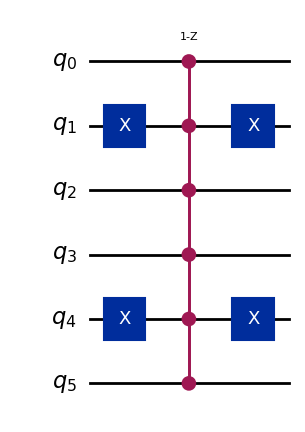

In [74]:
#Crear el circuito del oráculo de fase
circuito3 = oracle(num_qubits3, num_bits3, s3, n3)
display(circuito3.draw(output="mpl"))

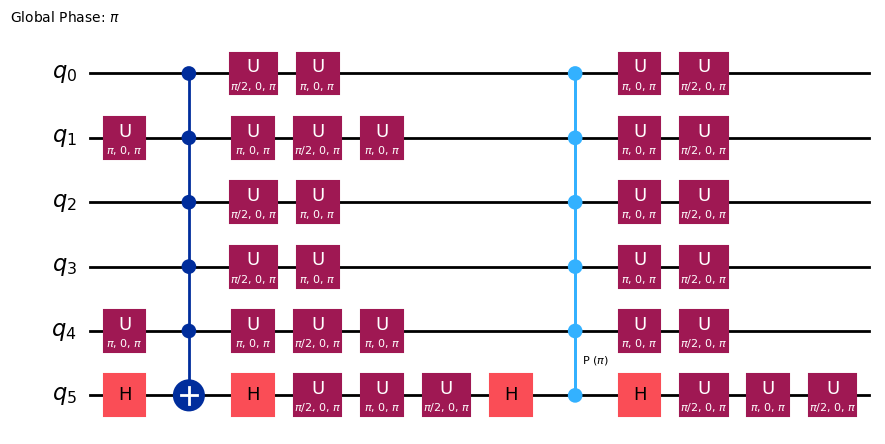

In [75]:
#Construir el operador de Grover
grover_op3 = grover_operator(circuito3)
grover_op3.decompose().draw(output="mpl", style="iqp")

k=1:


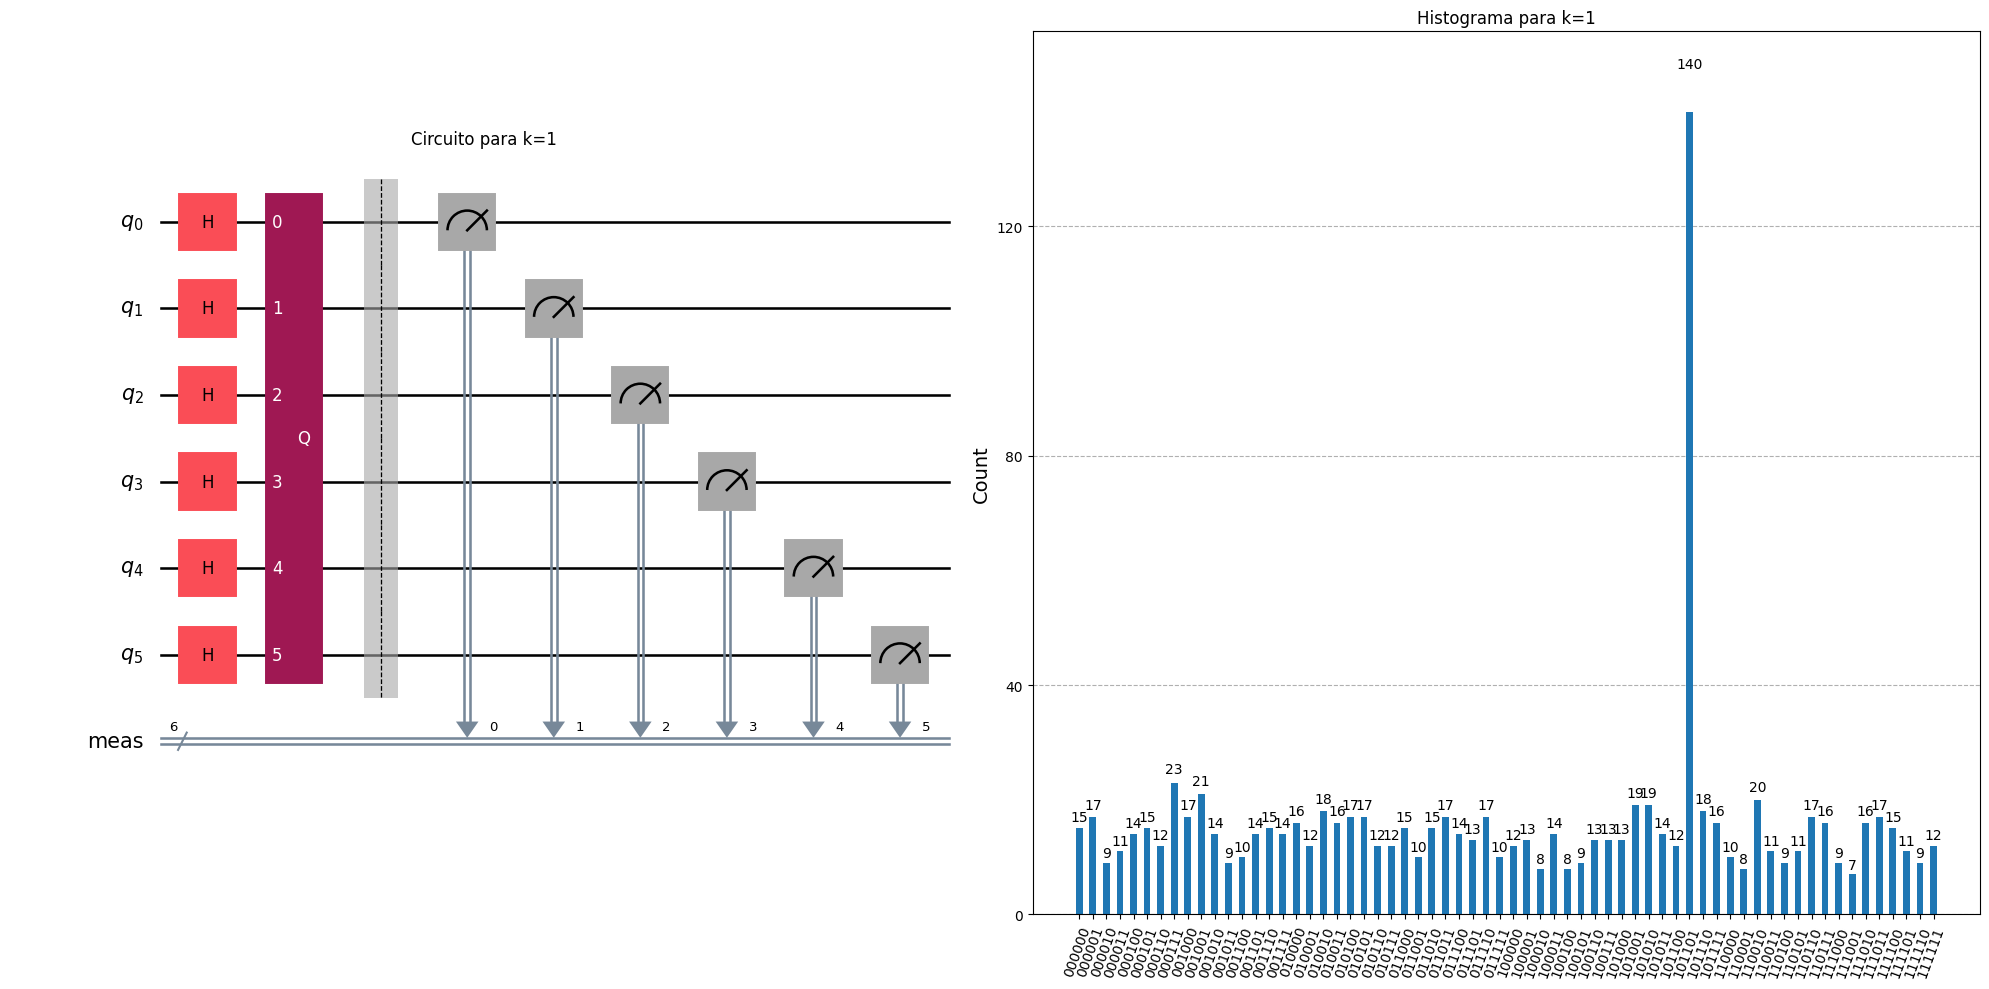

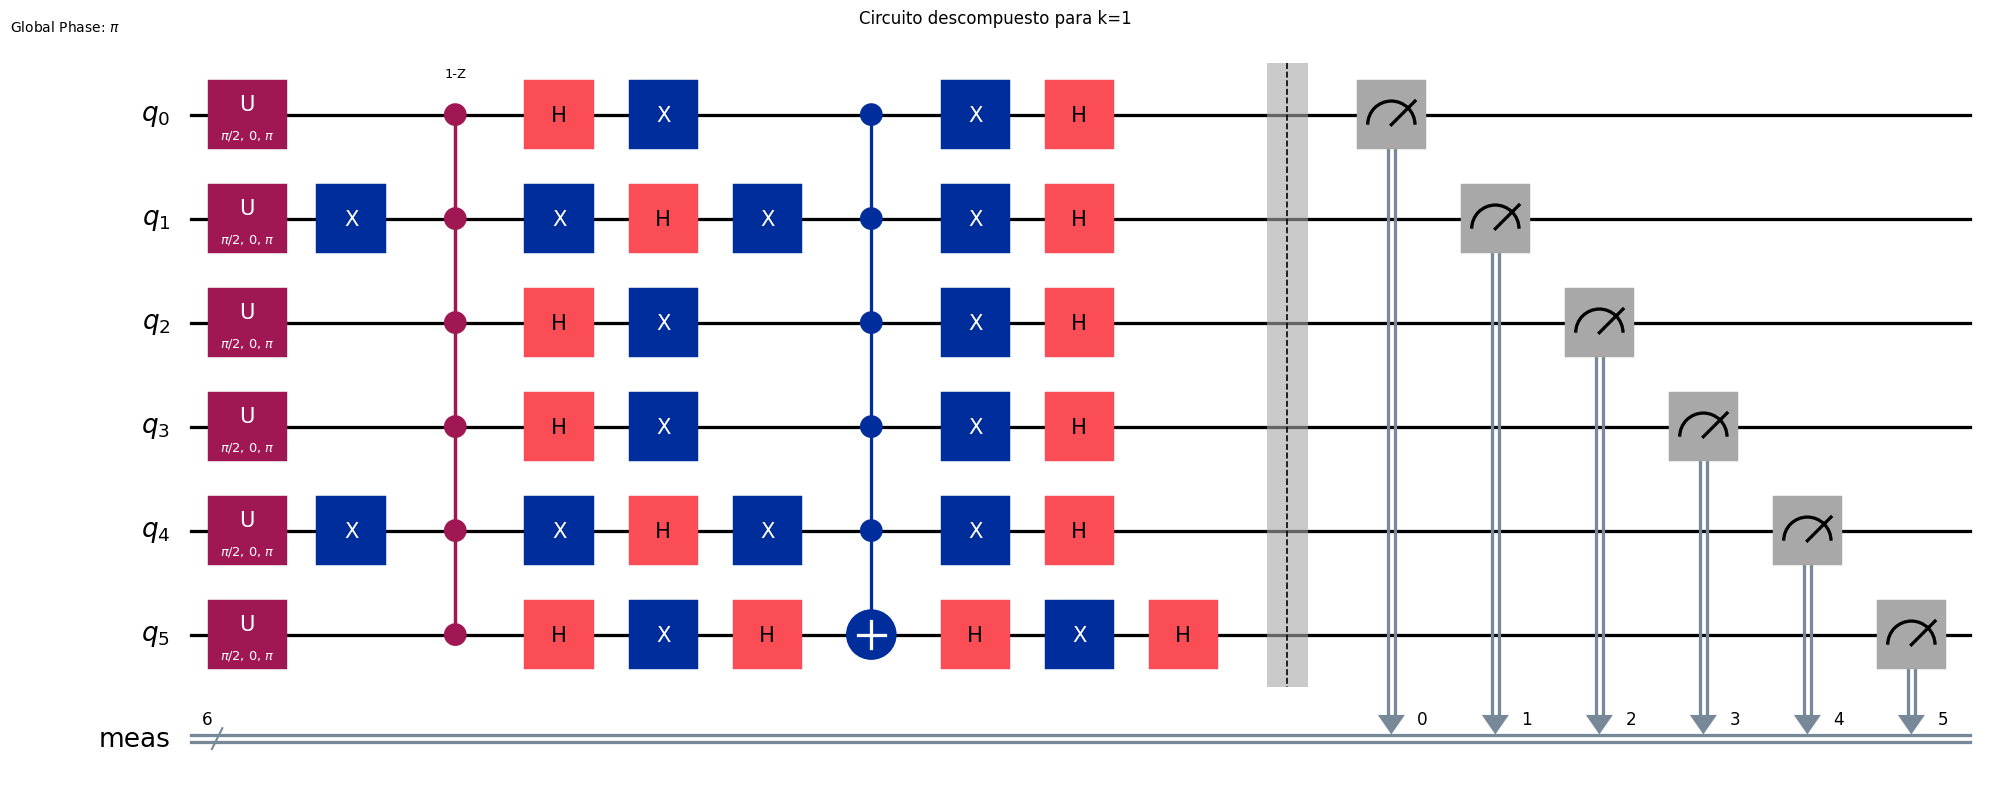

k=2:


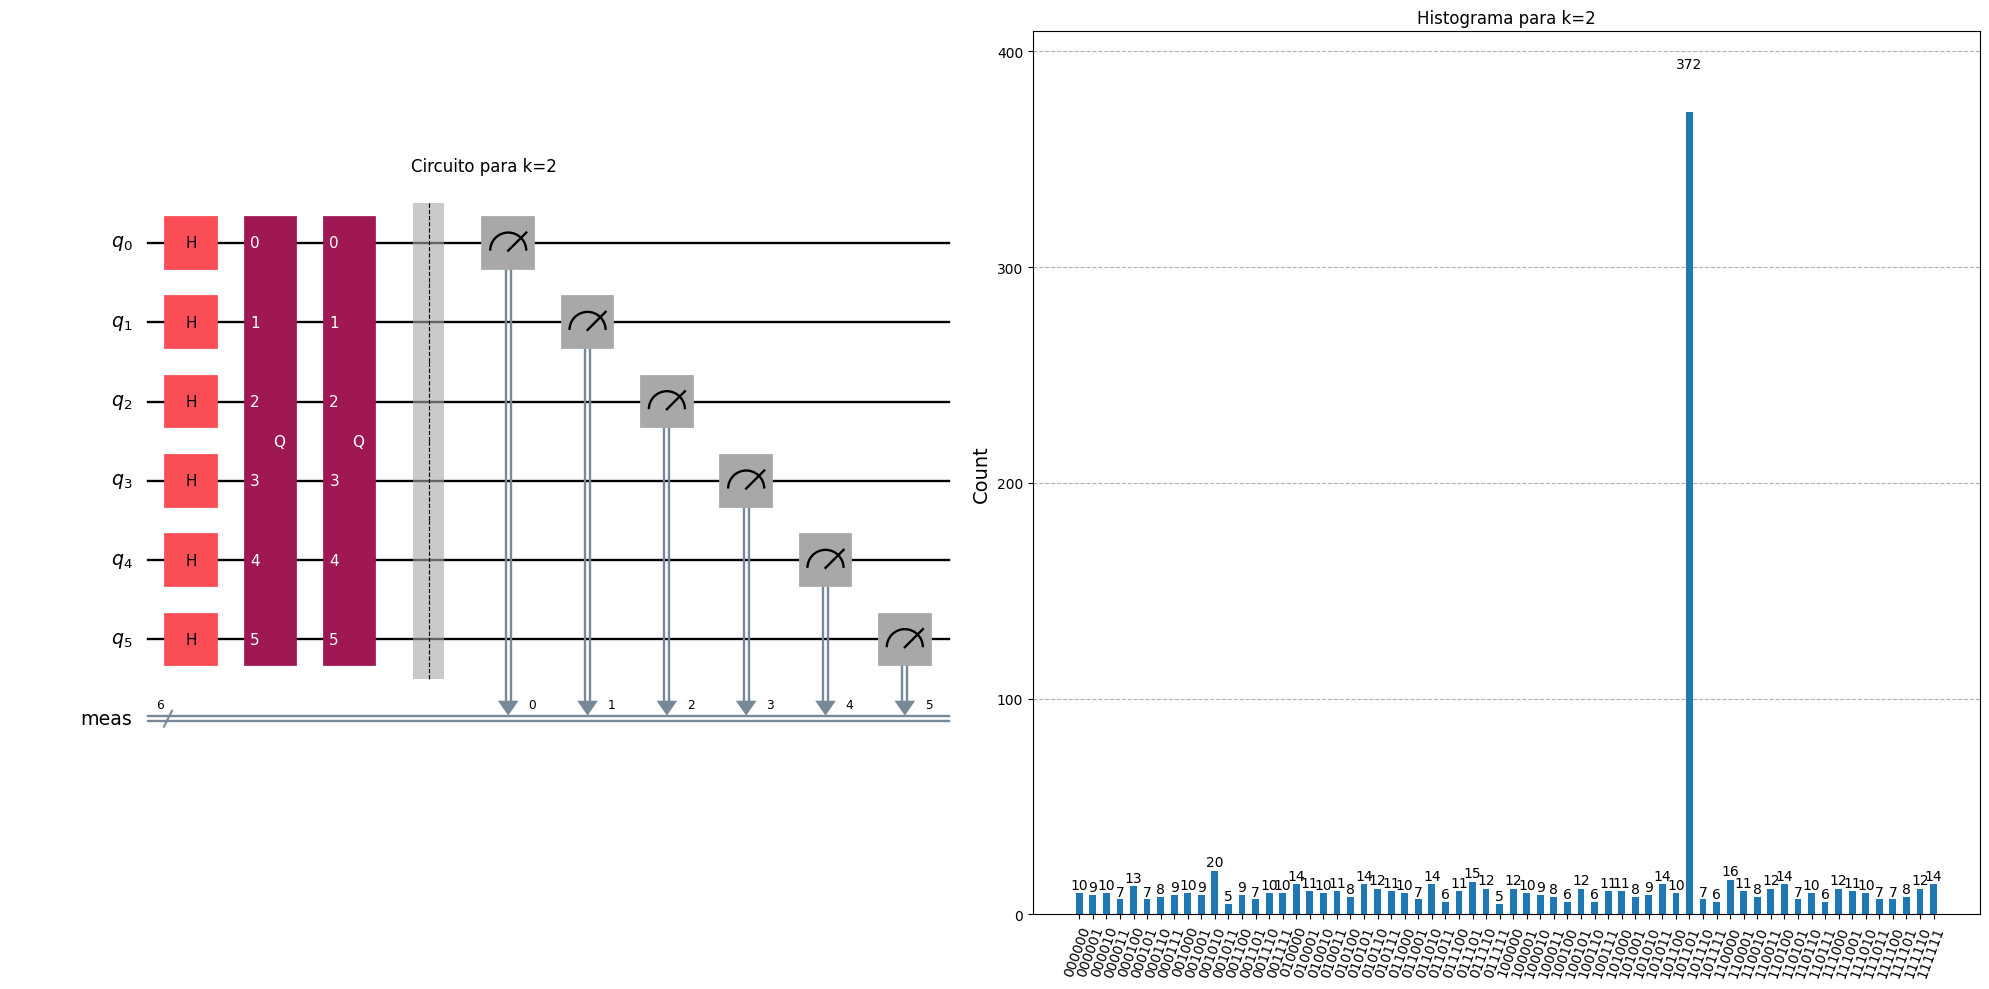

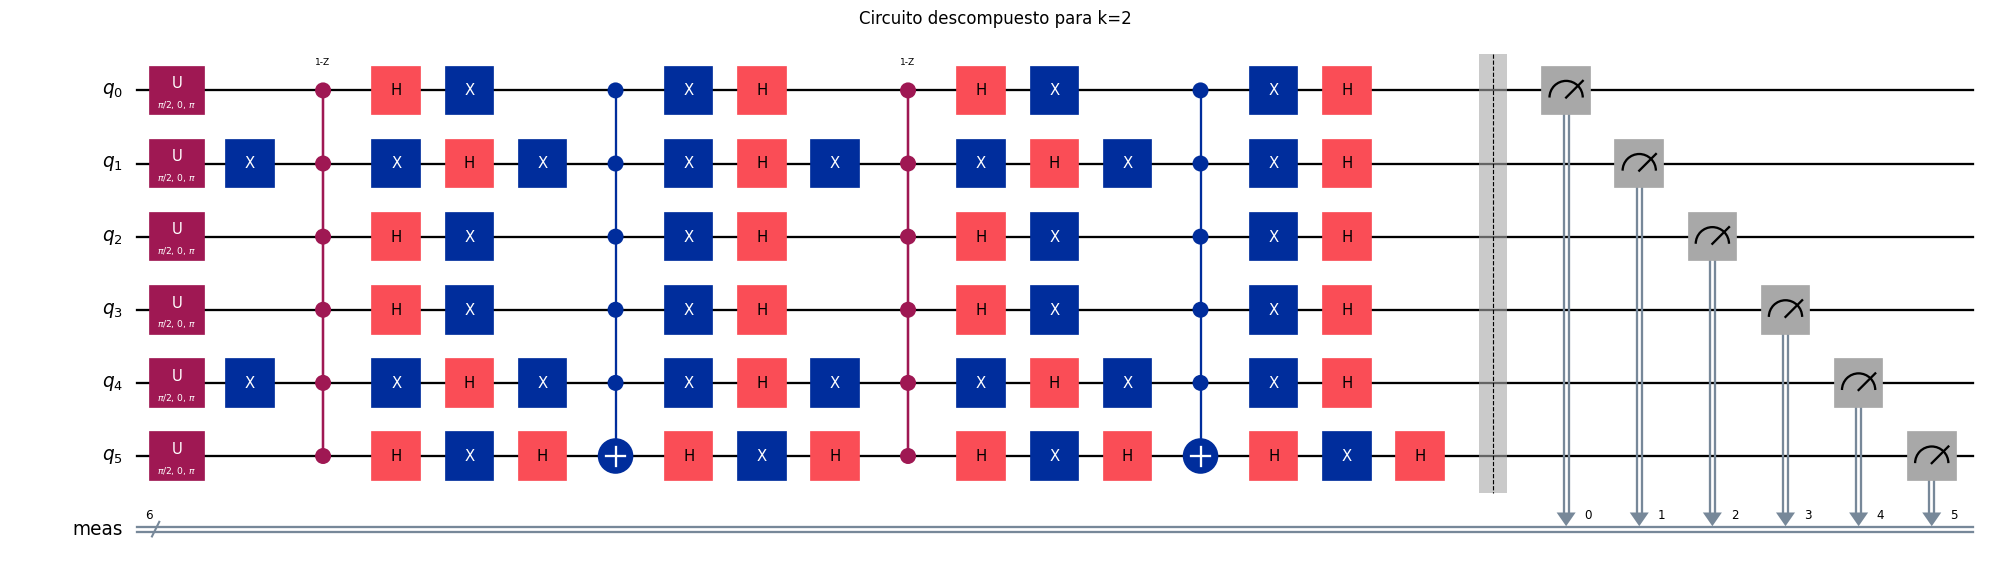

k=3:


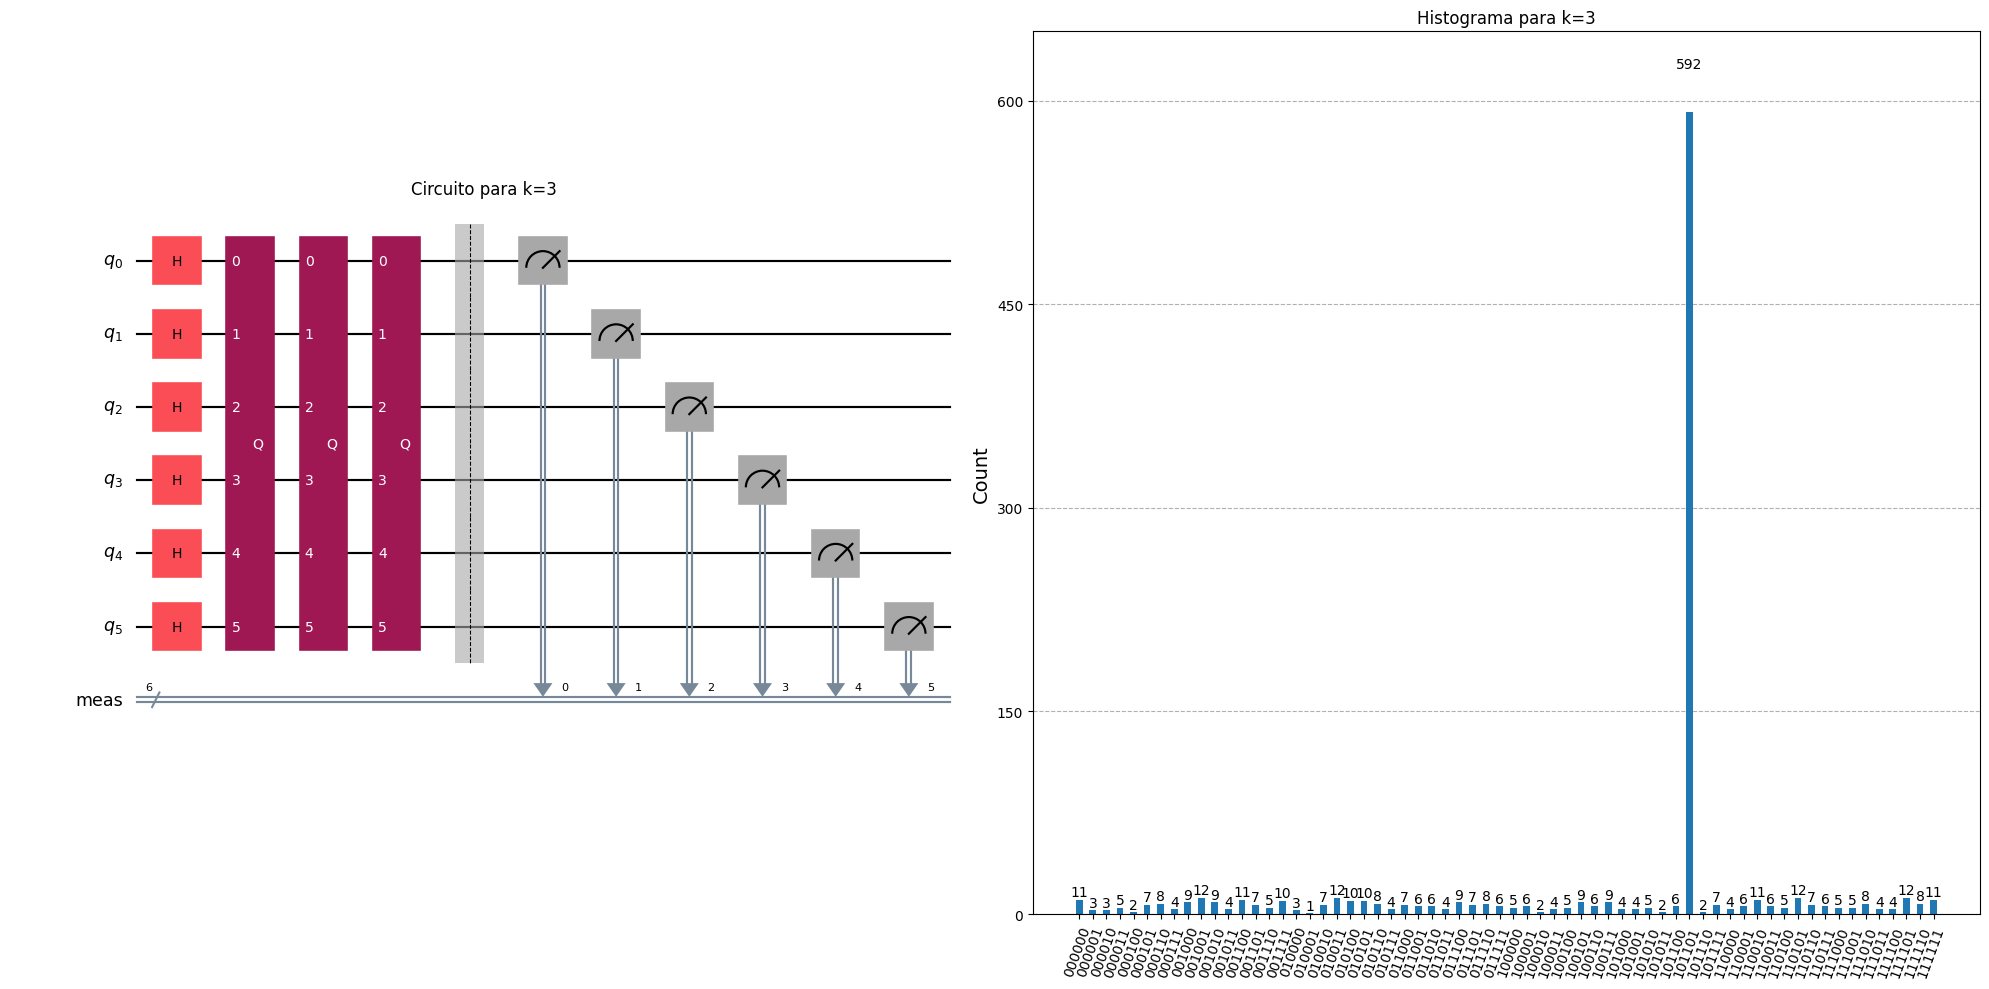

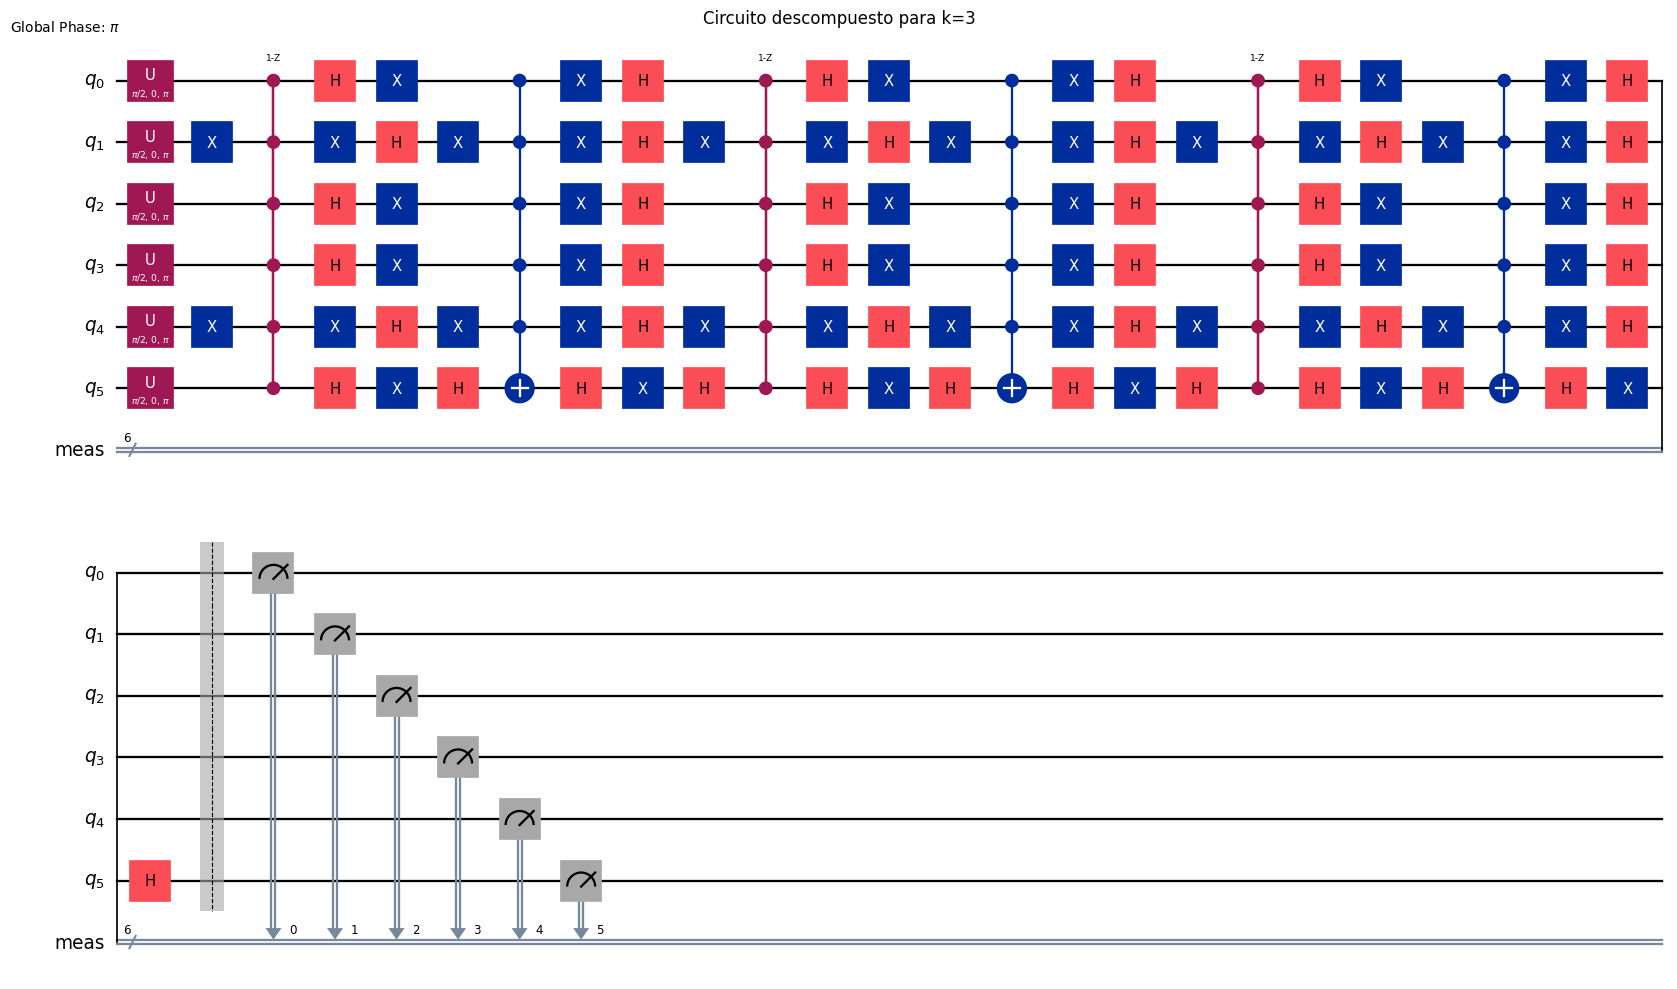

k=4:


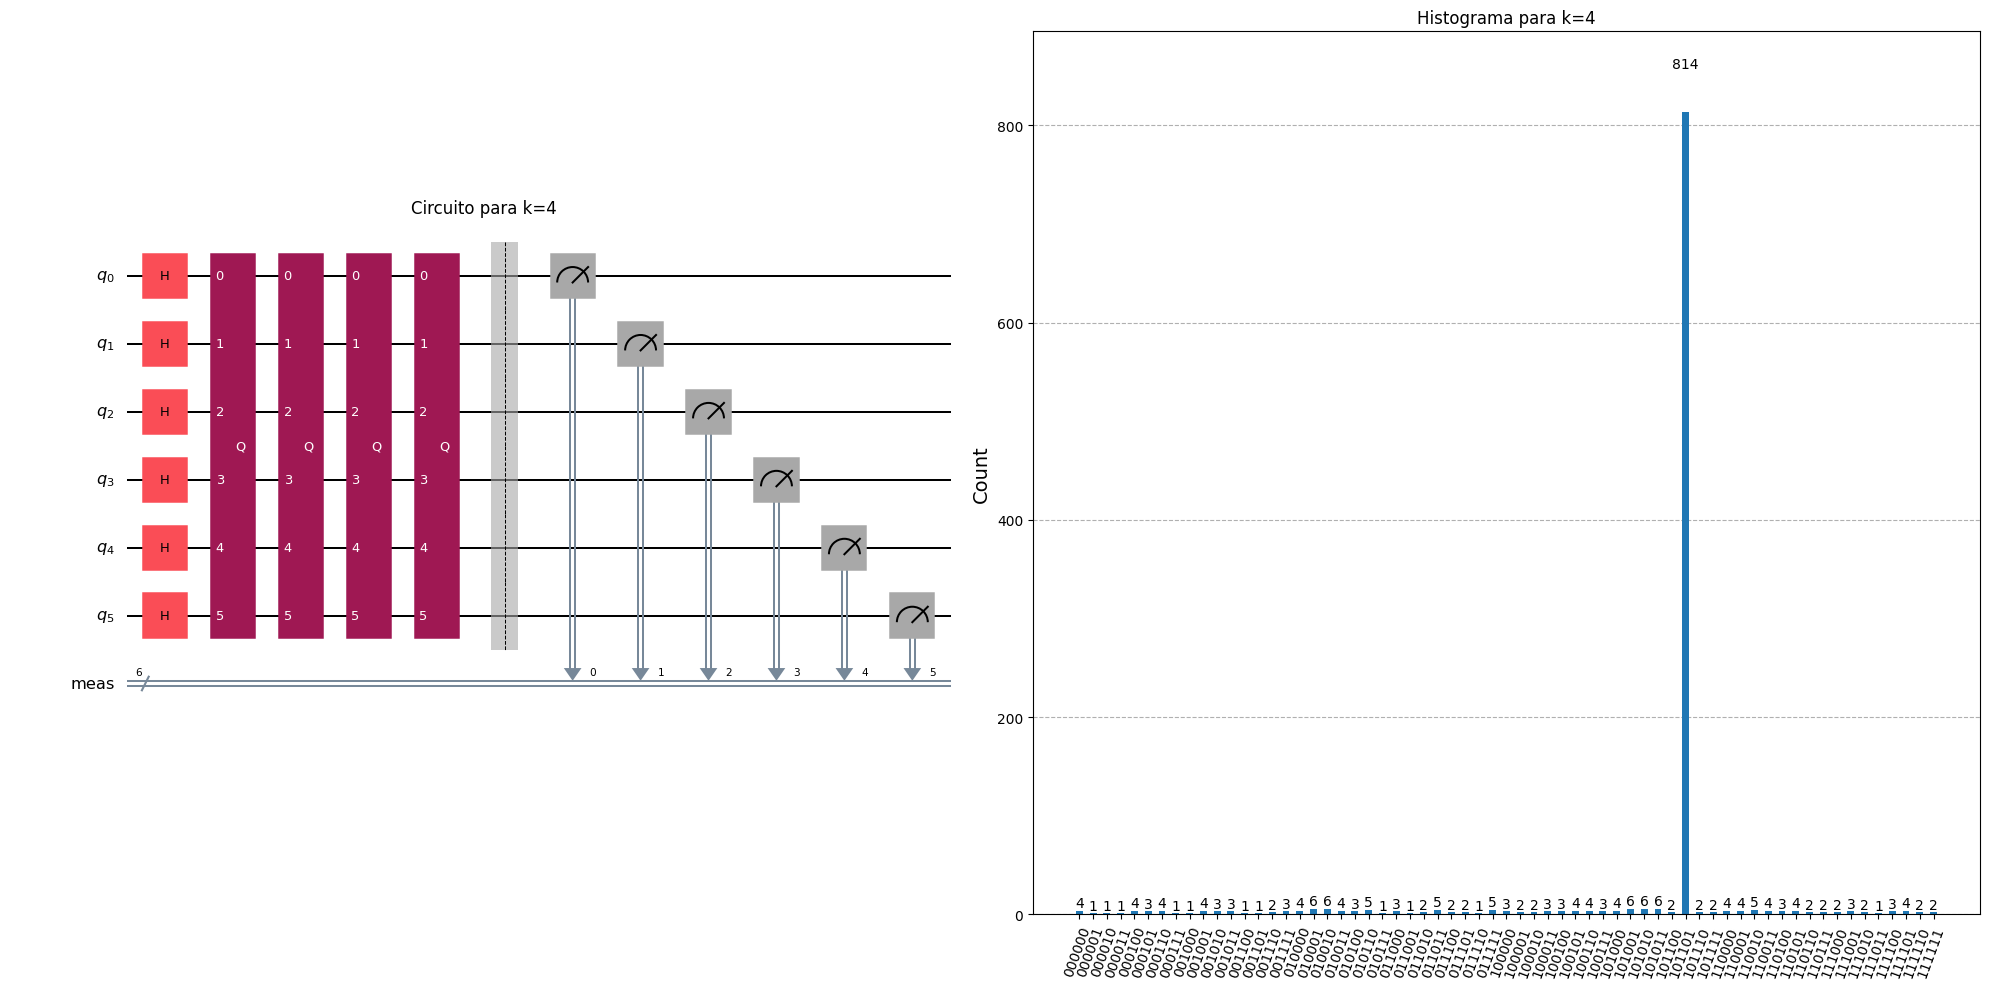

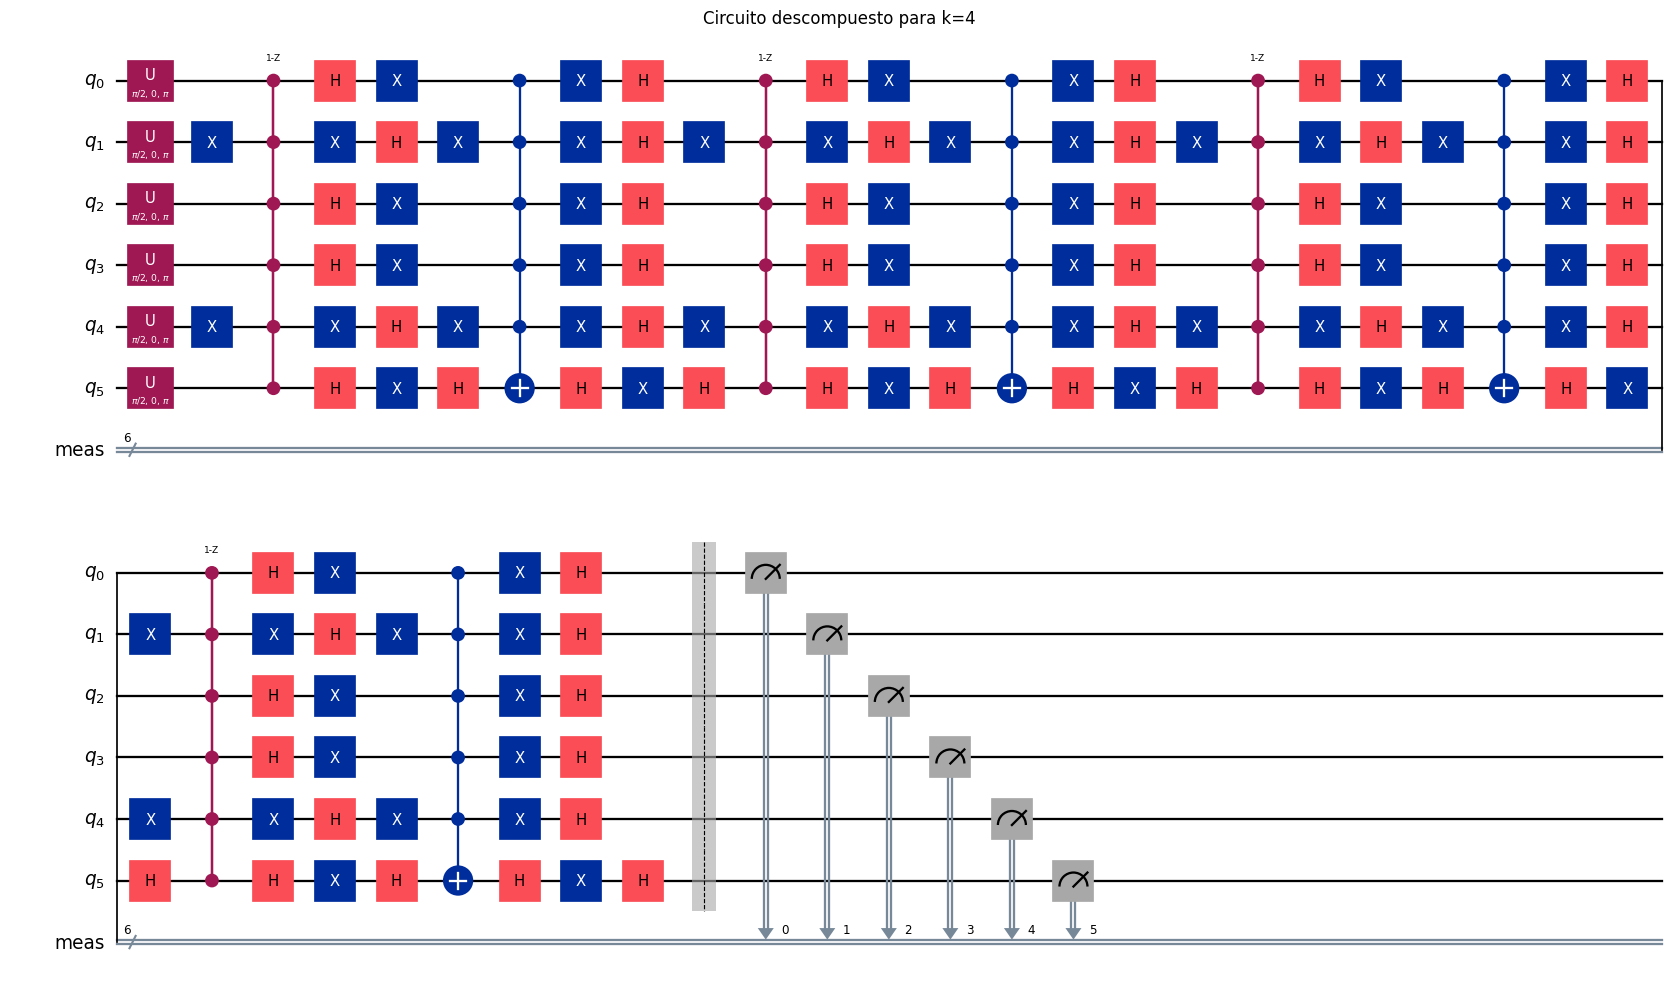

k=5:


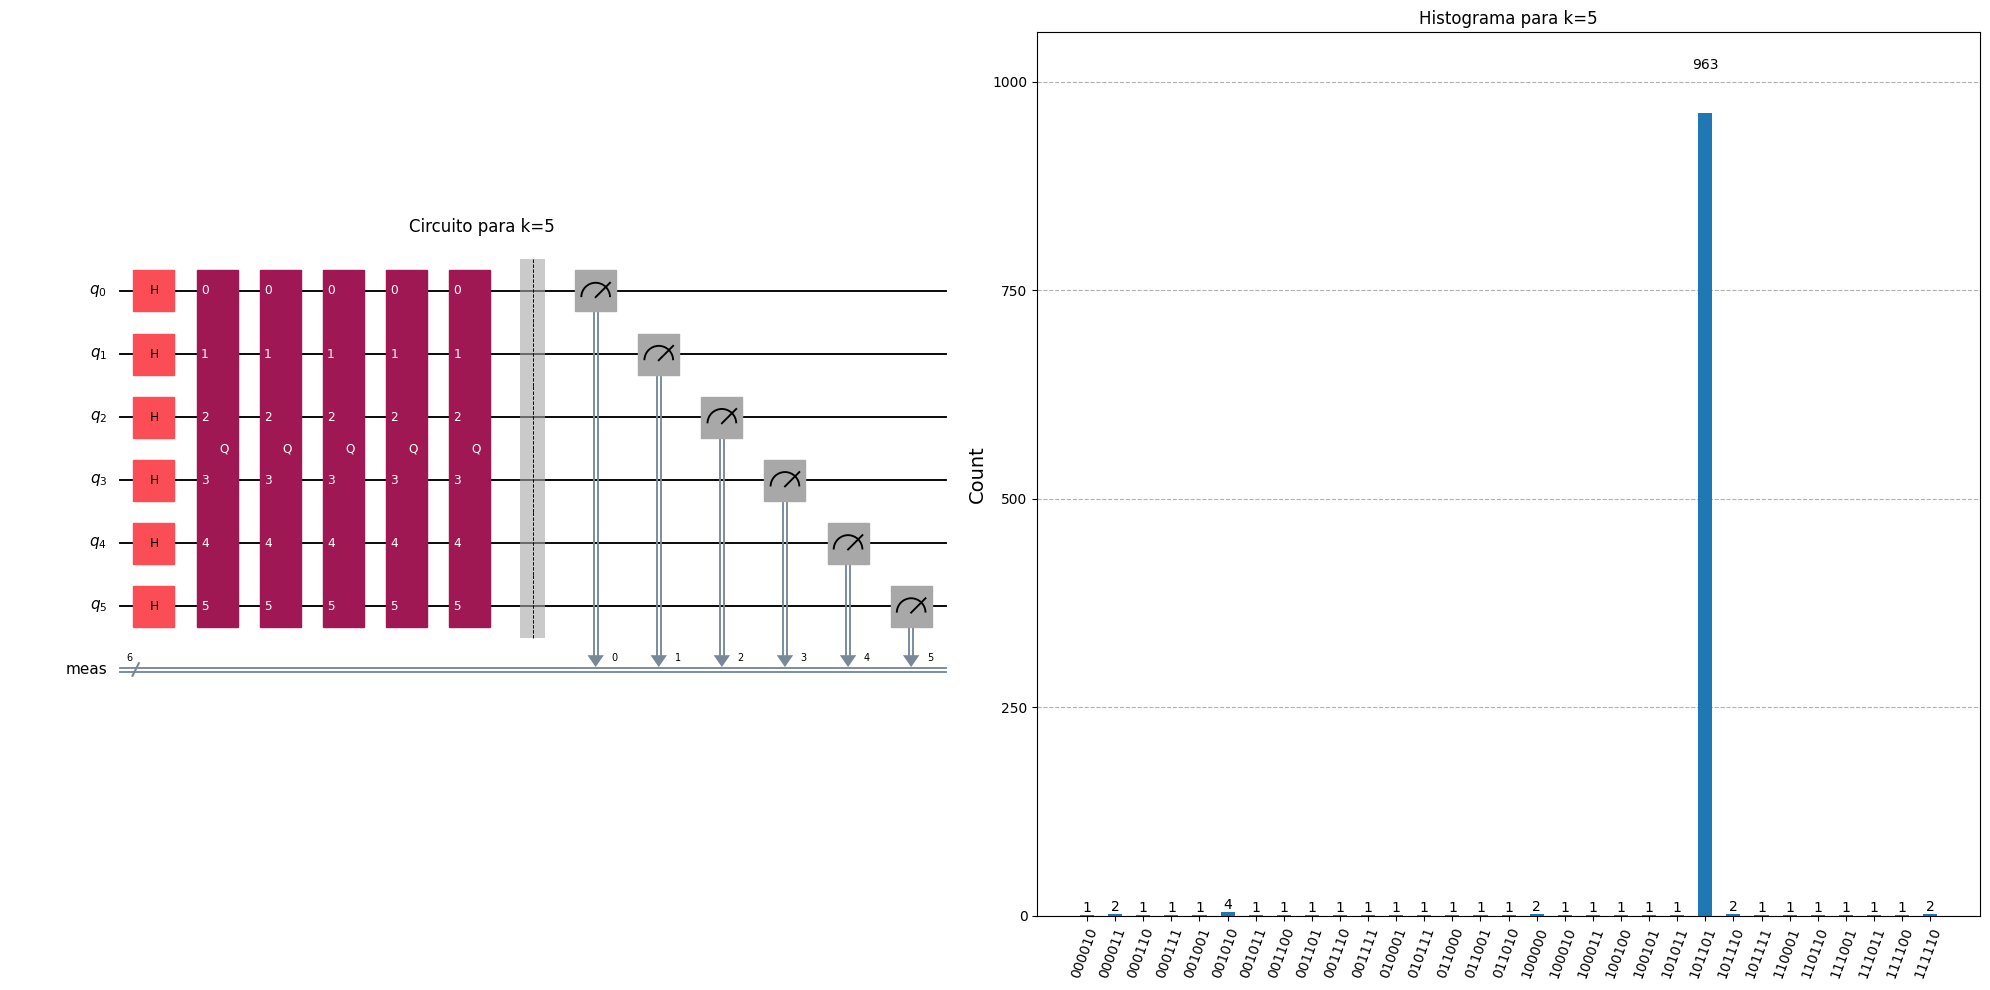

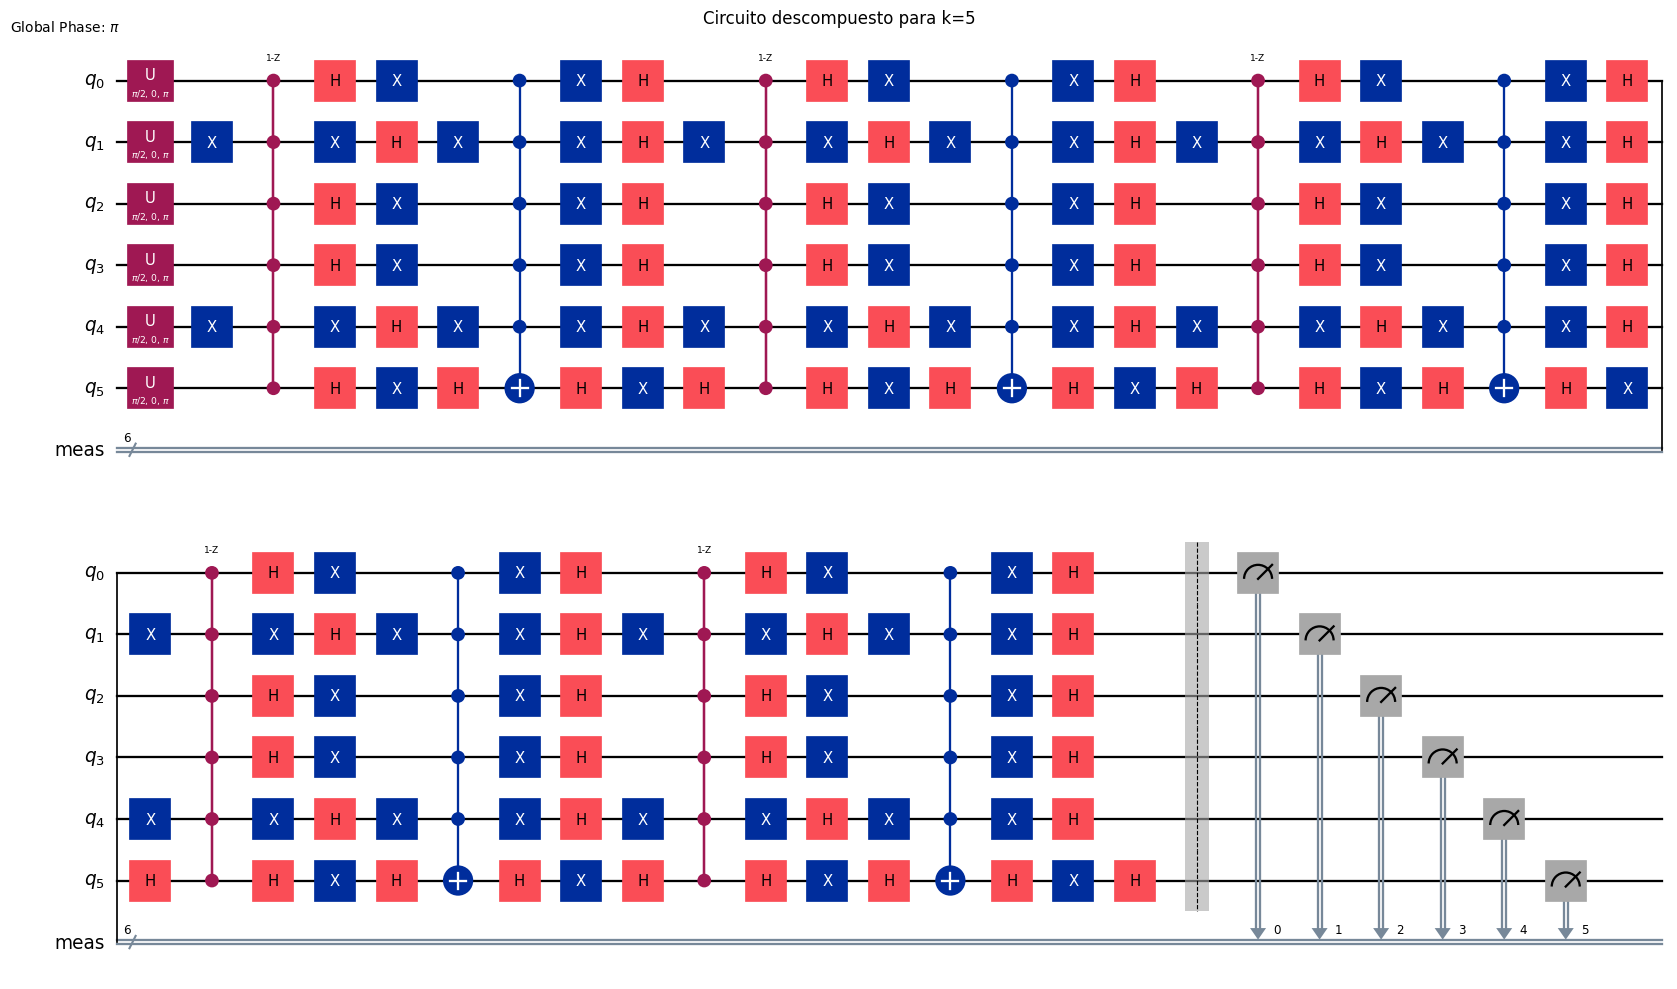

k=6:


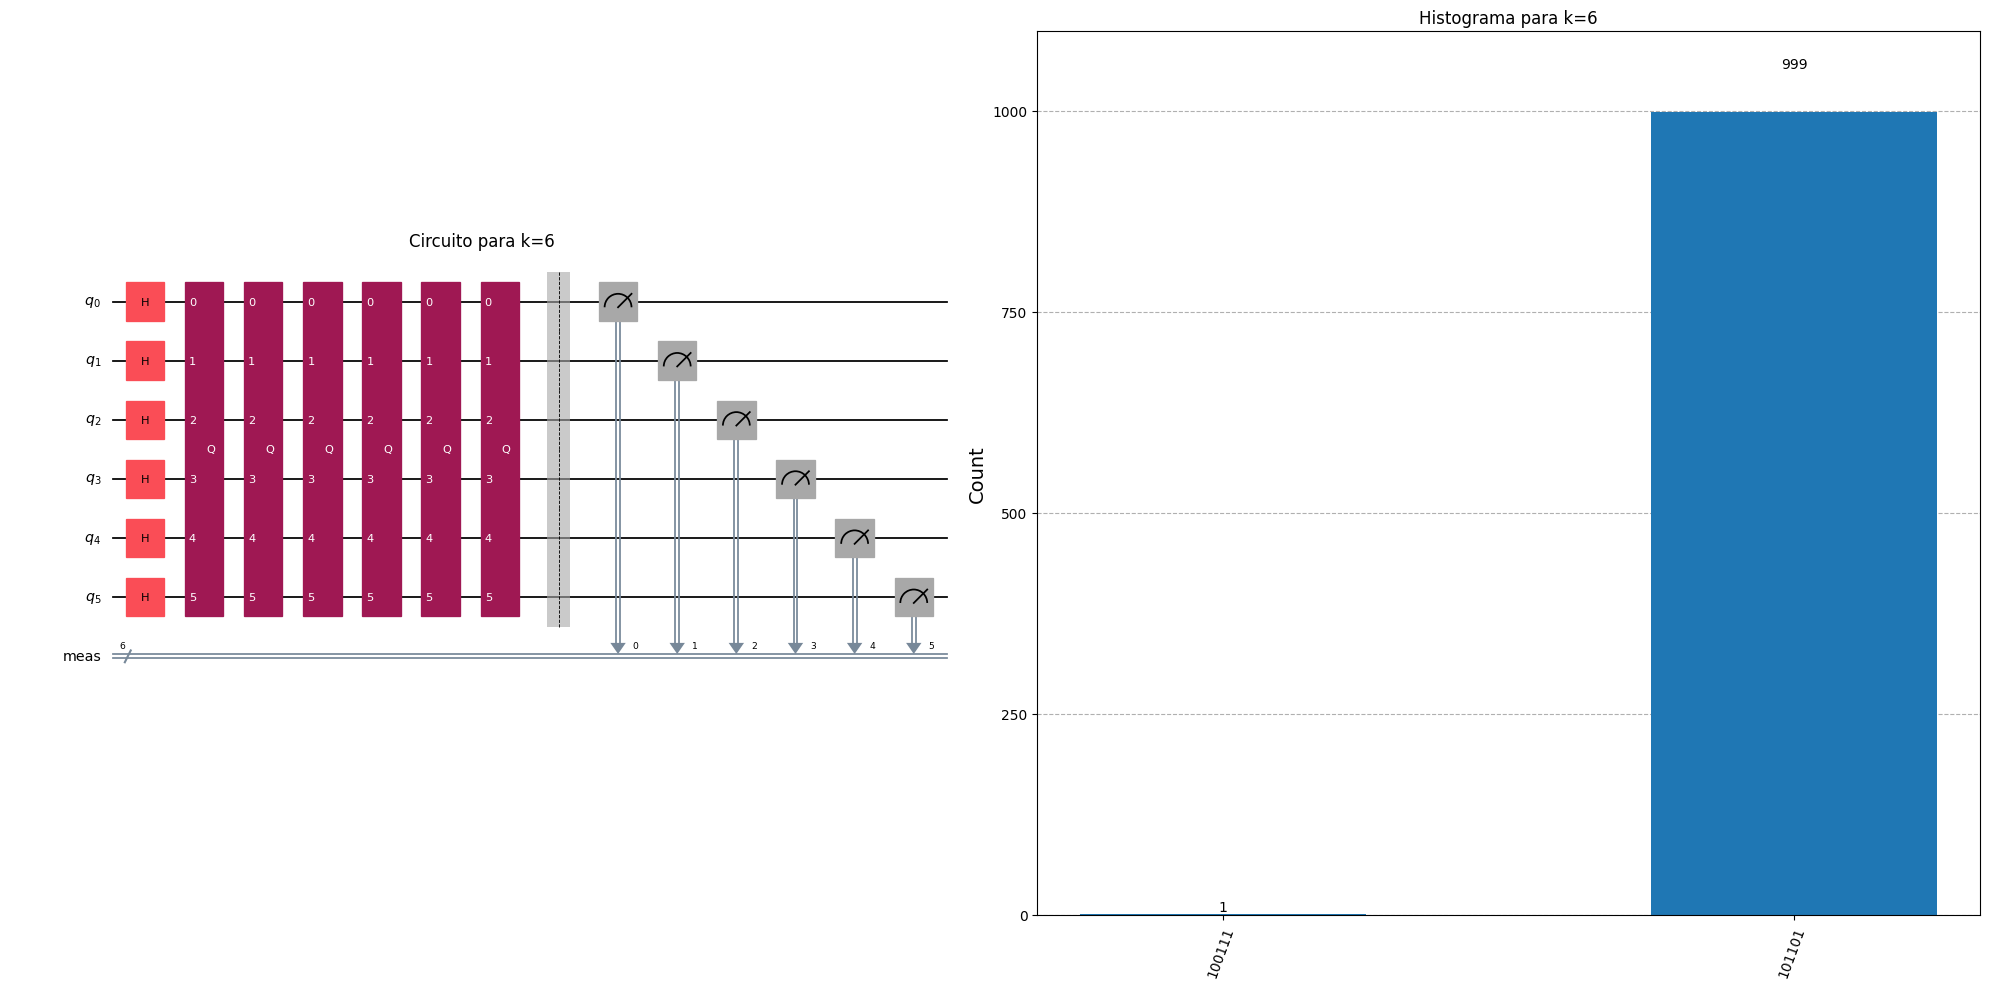

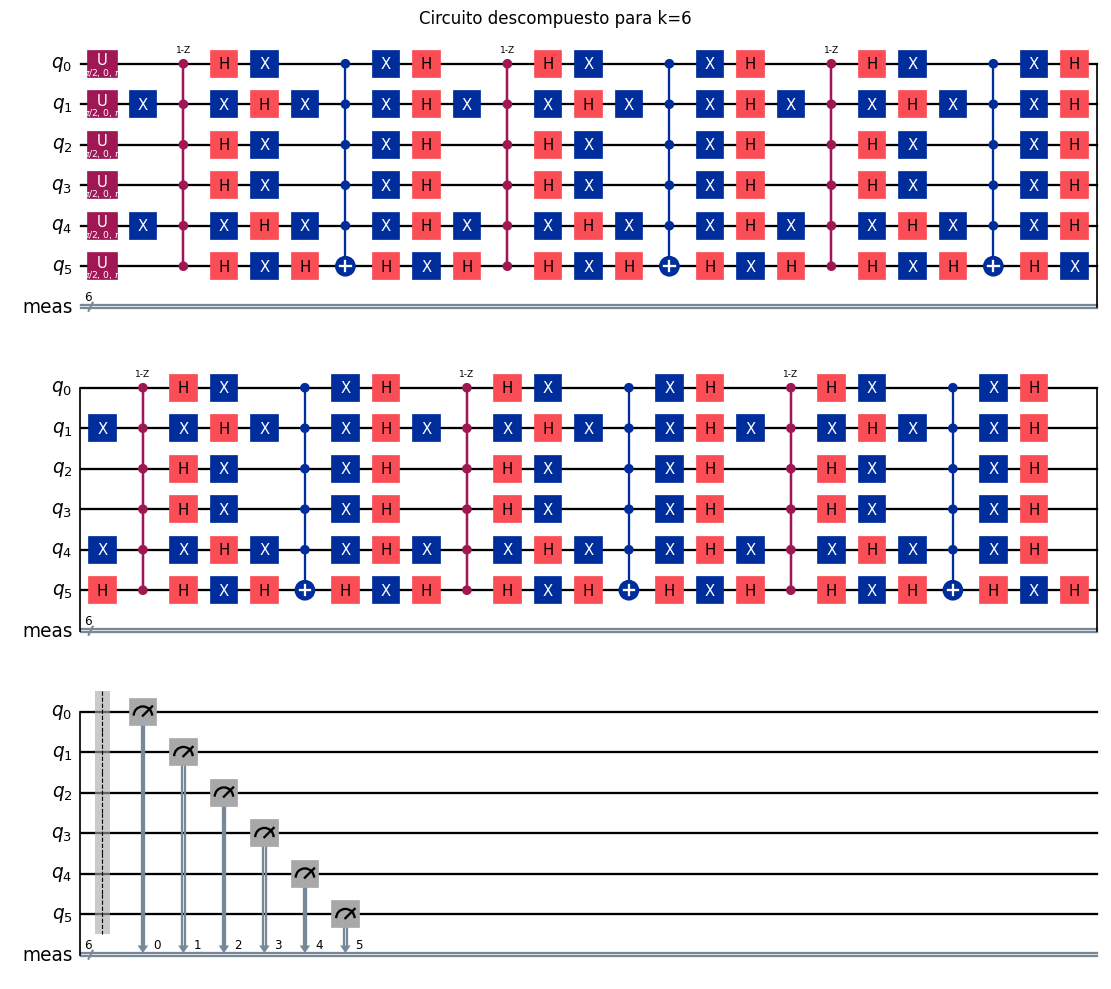

k=7:


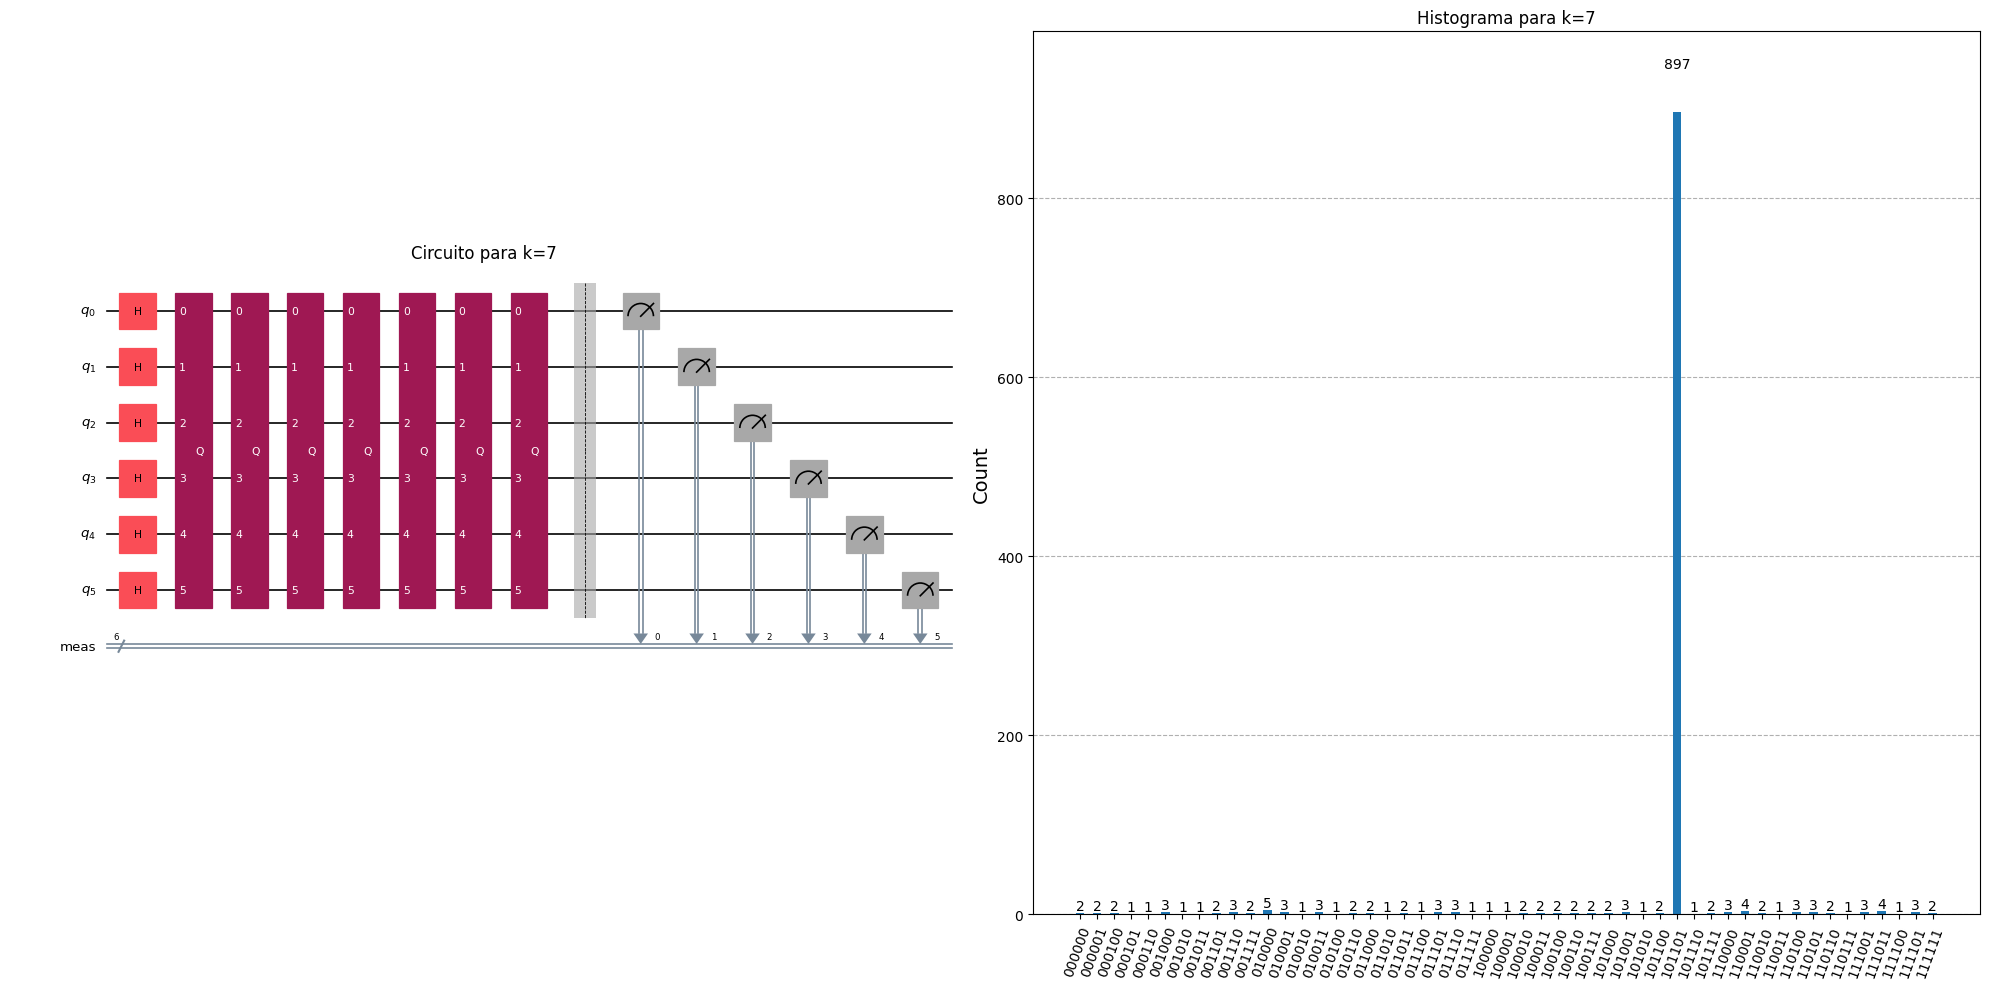

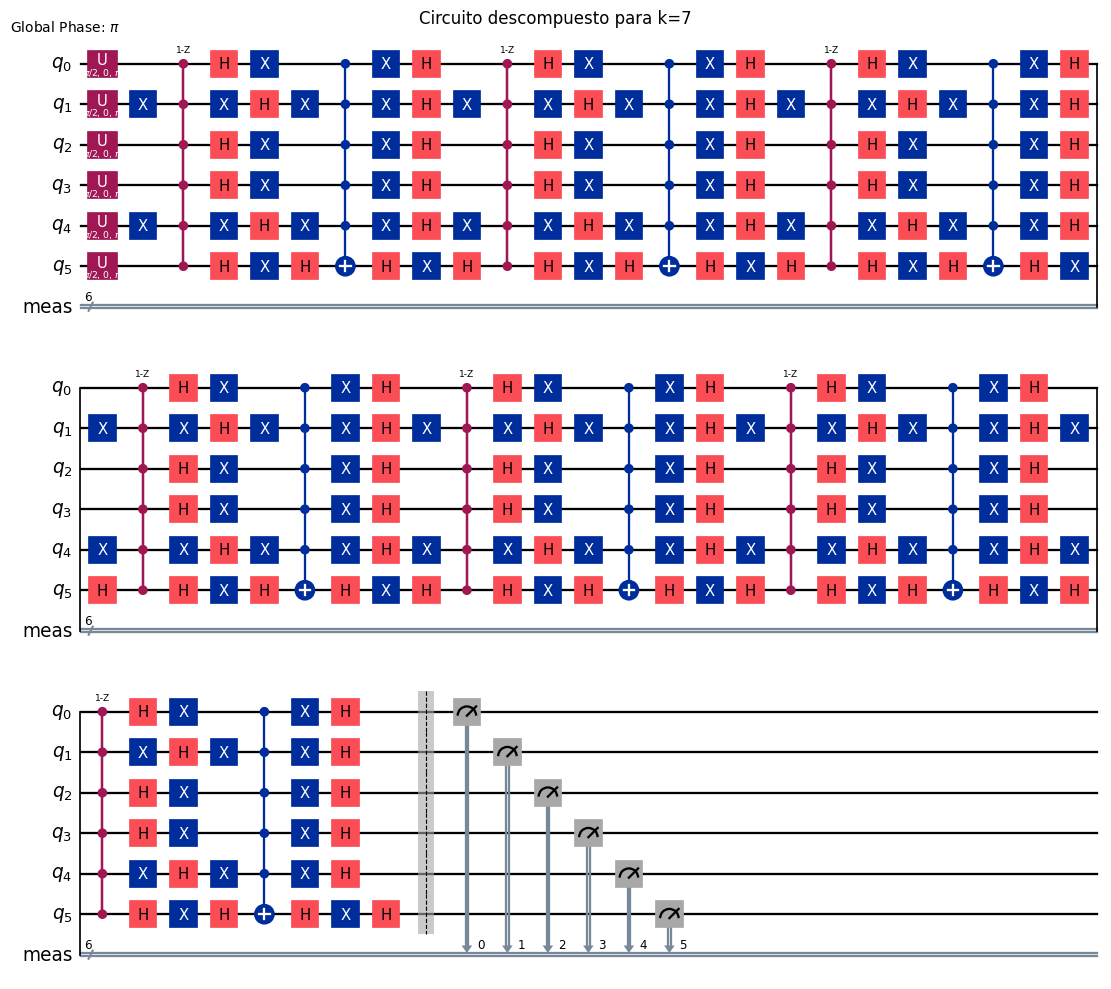

k=8:


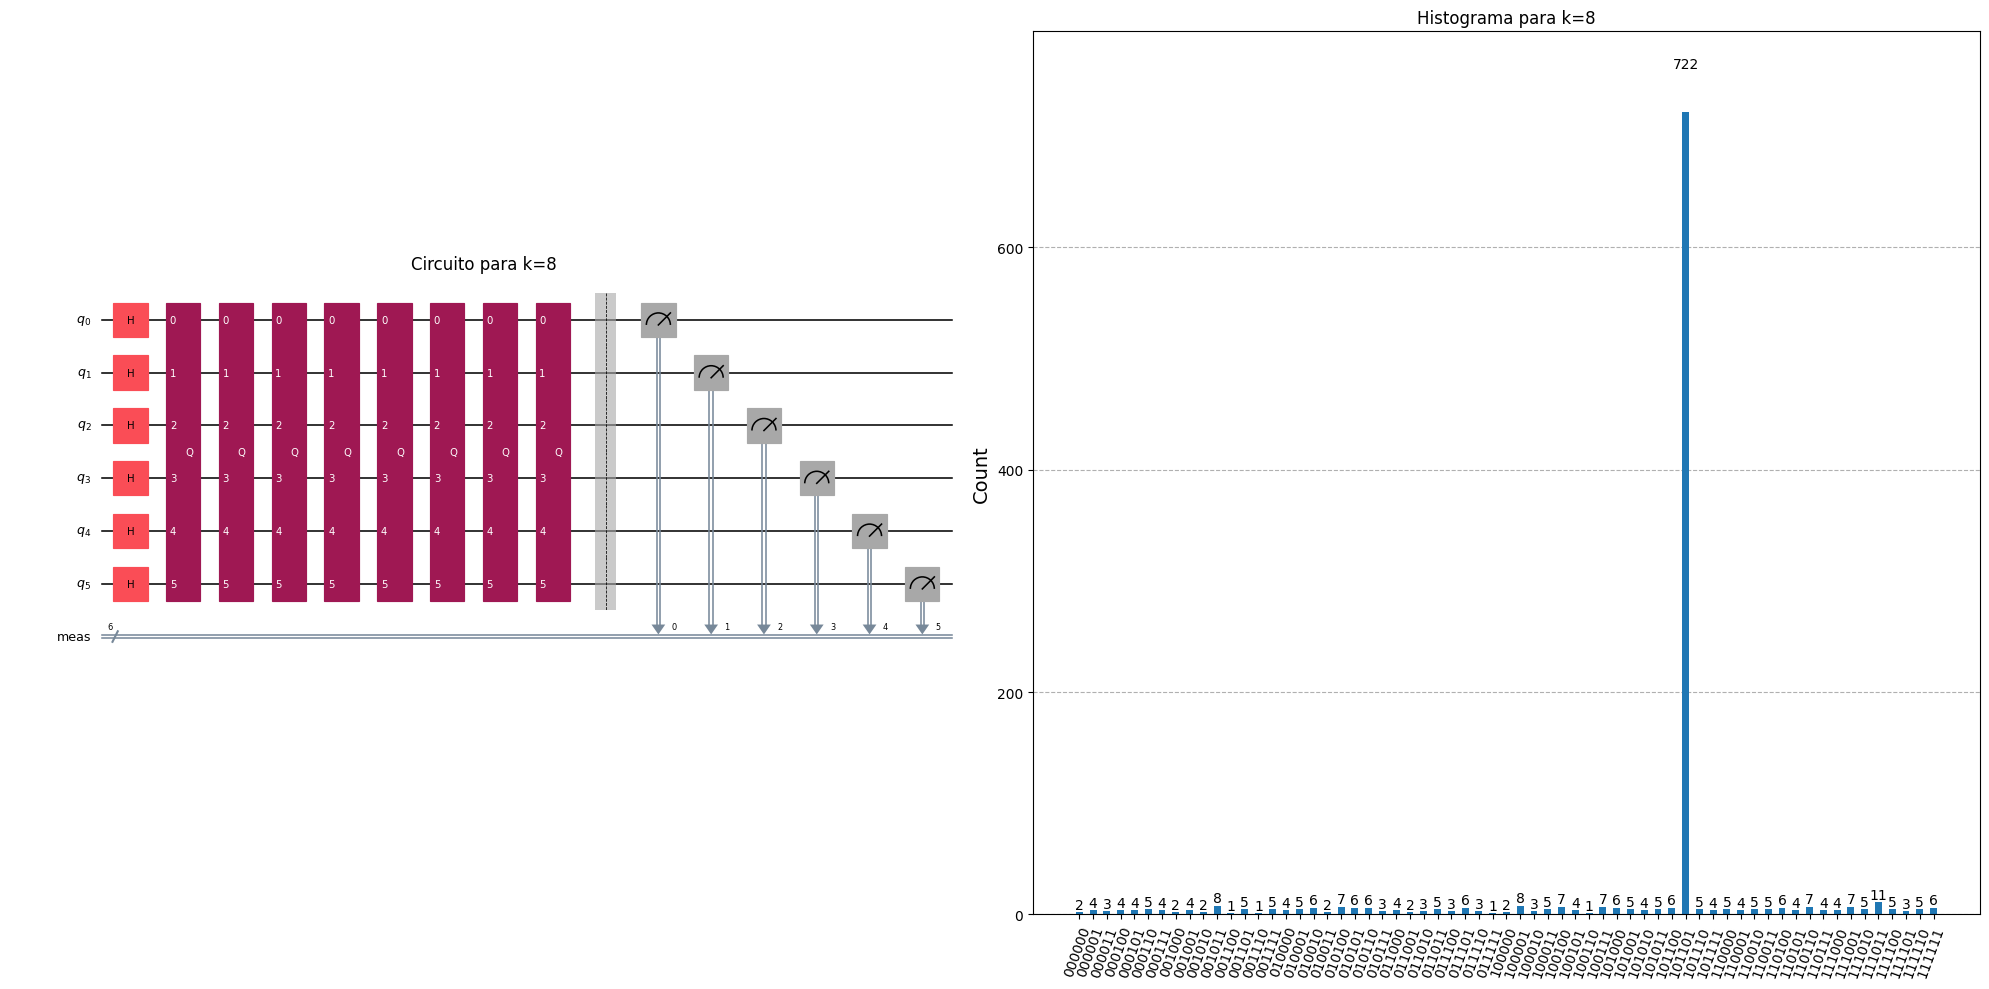

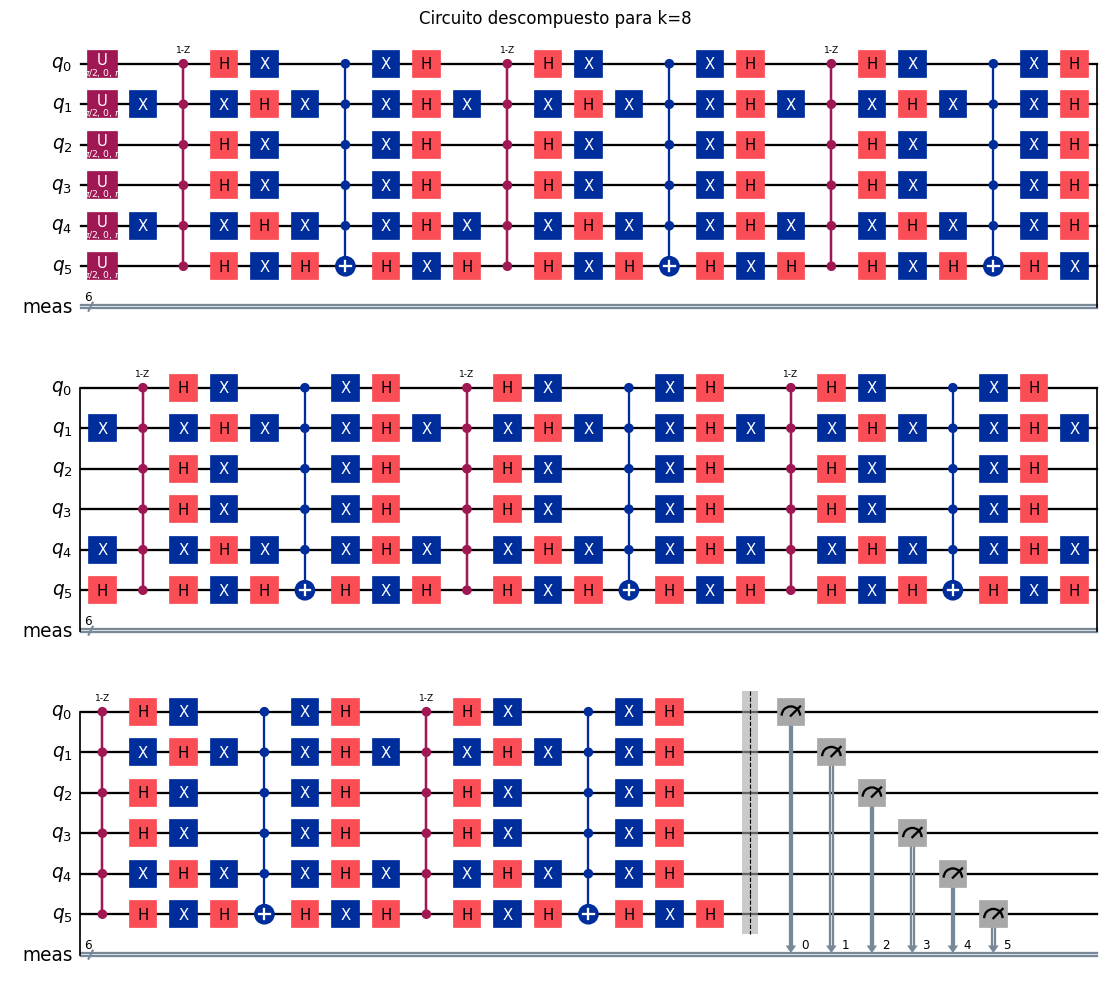

k=9:


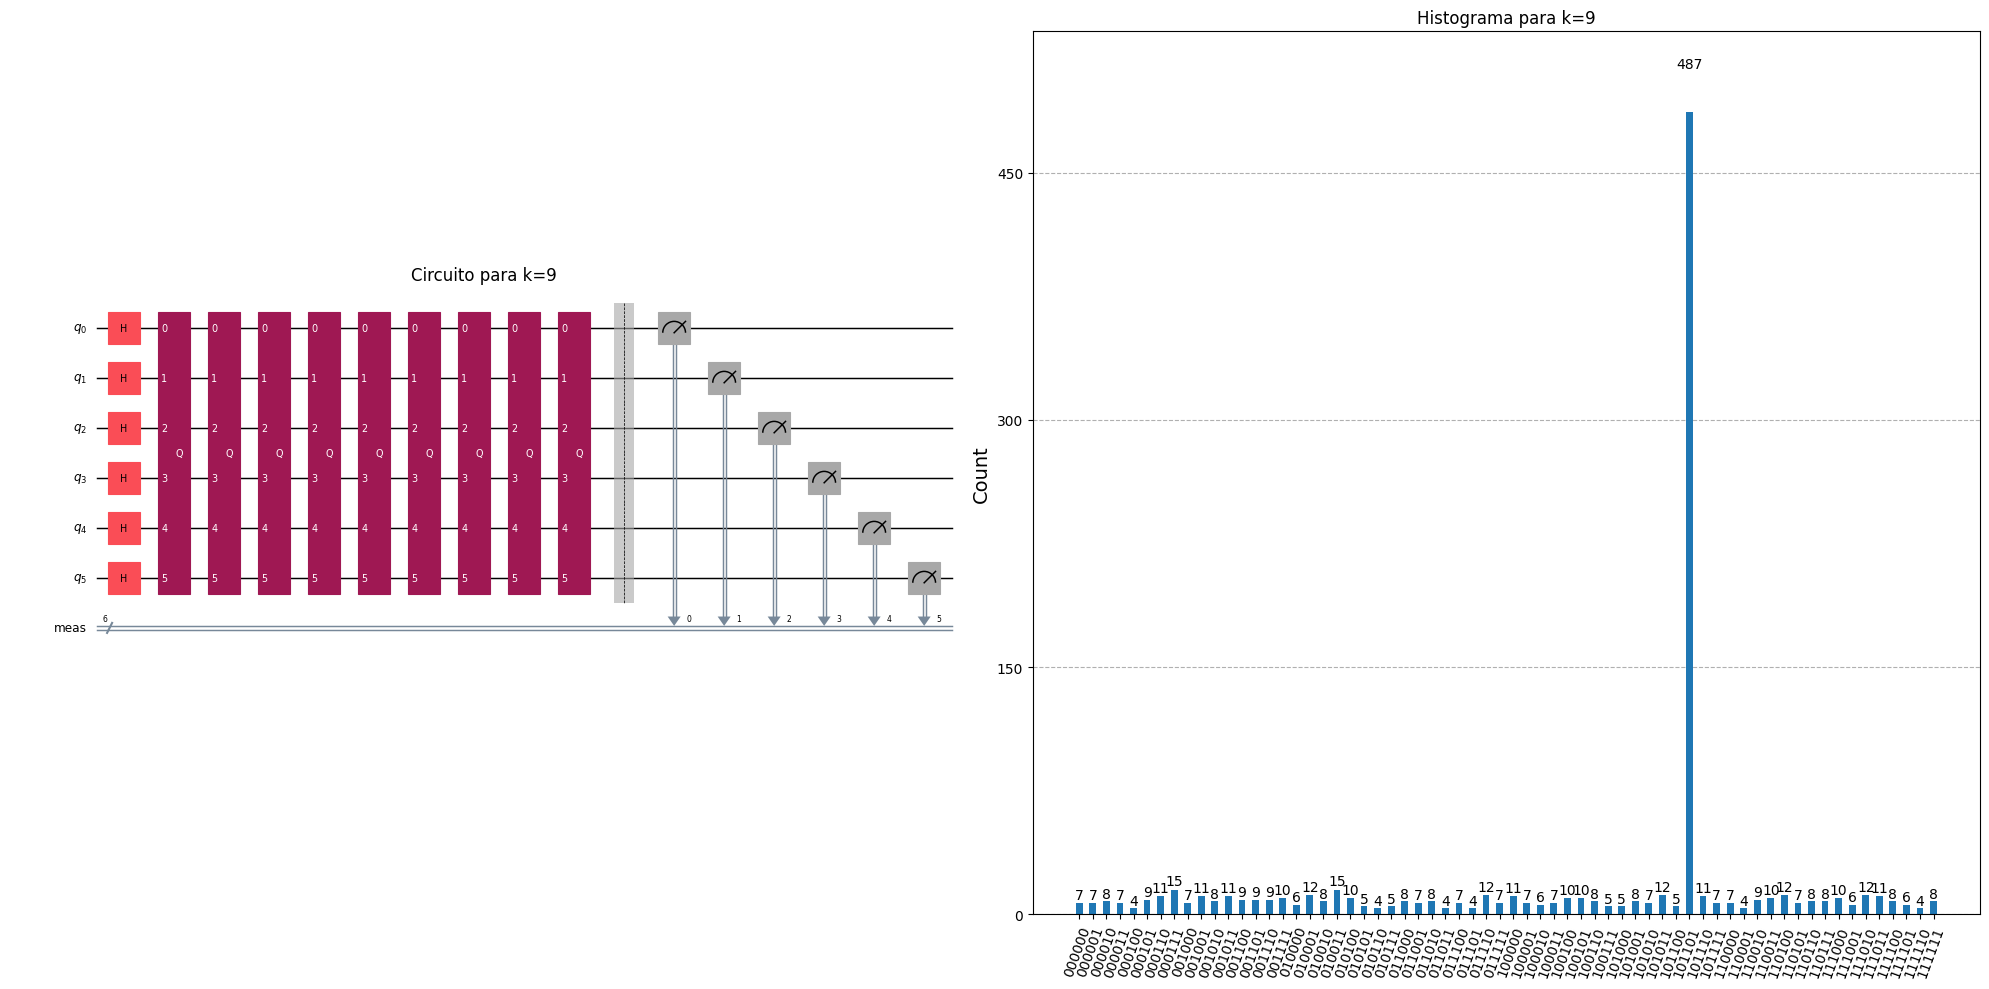

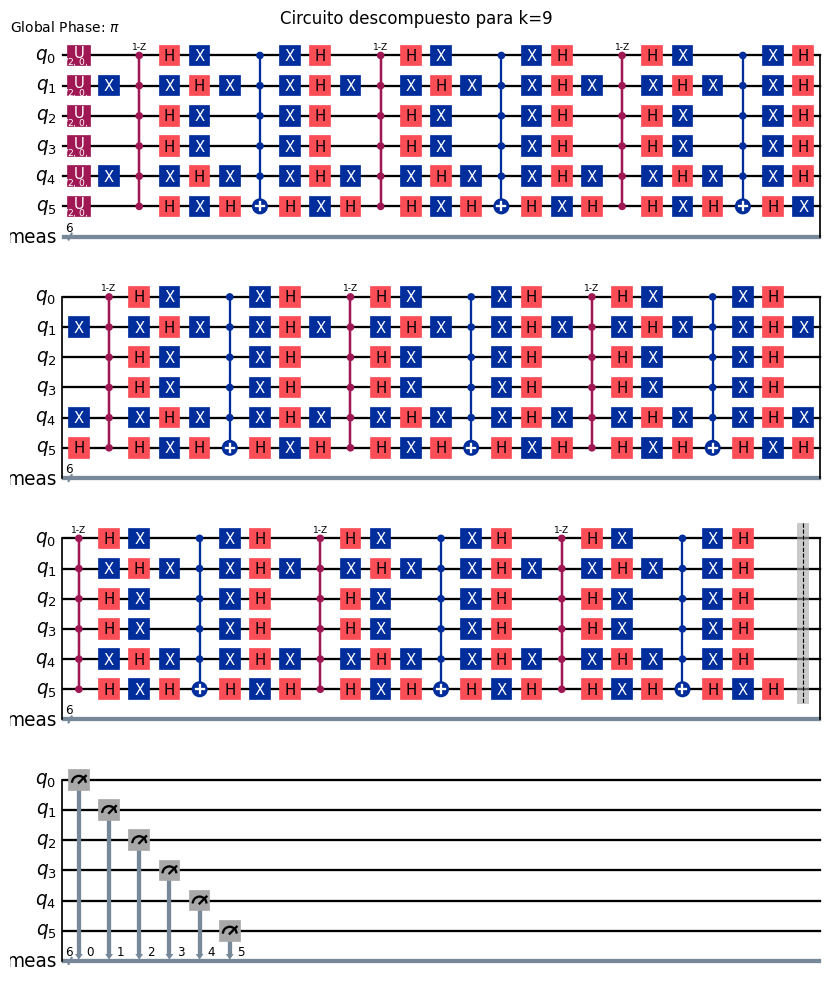

k=10:


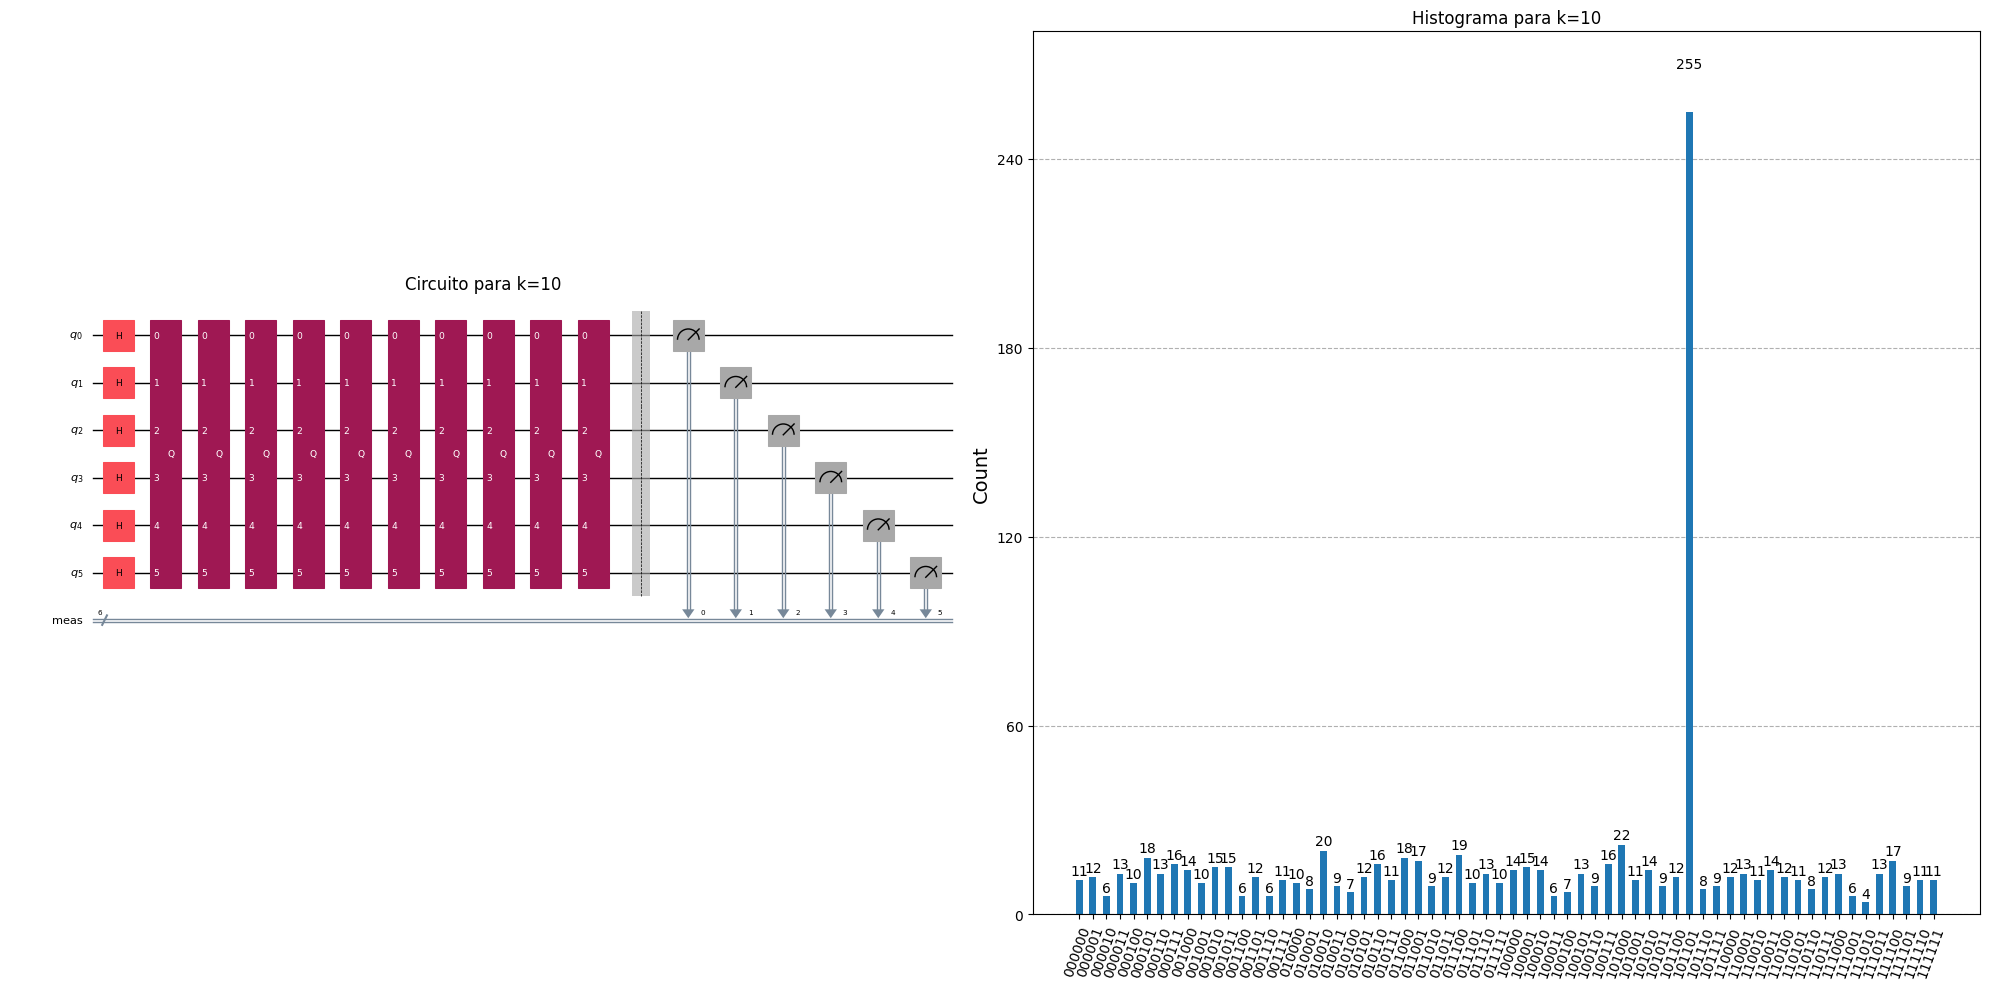

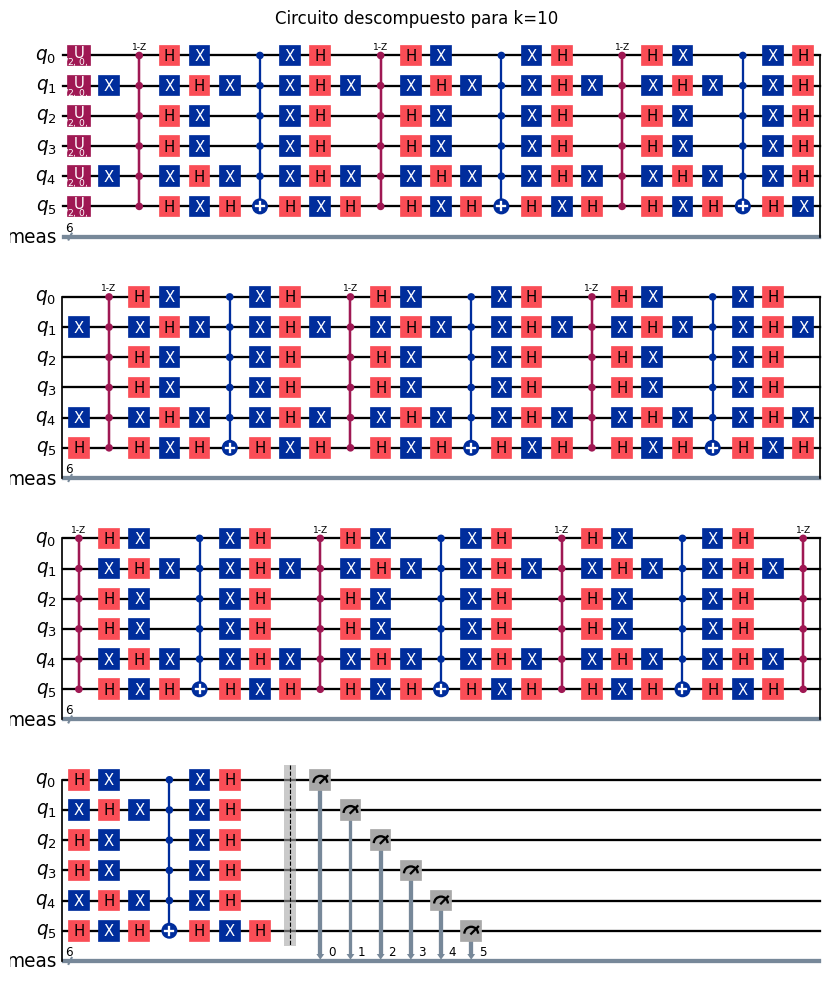

In [76]:
for k in range(1, 11):

    #Crea circuito
    qc = QuantumCircuit(num_qubits3)

    #Aplica hadamard a los qubits para crear superposición
    qc.h(range(num_qubits3))
    
    #Aplica Grover k veces
    qc.compose(grover_op3.power(k), inplace=True)
    
    #Obtener probabilidades
    sv = Statevector.from_instruction(qc)
    statistics = sv.sample_counts(1000)

    qc.measure_all()

    print(f"k={k}:")
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    qc.draw(output="mpl", style="iqp", ax=ax1)
    ax1.set_title(f"Circuito para k={k}")

    plot_histogram(statistics, ax=ax2)
    ax2.set_title(f"Histograma para k={k}")

    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 1)

    ax1 = fig.add_subplot(gs[0, 0])
    qc.decompose().draw(output="mpl", style="iqp", ax=ax1)
    ax1.set_title(f"Circuito descompuesto para k={k}")

    plt.tight_layout()
    plt.show()

    """display(qc.draw(output="mpl", style="iqp"))
    display(qc.decompose().draw(output="mpl", style="iqp"))
    display(plot_histogram(statistics))"""

Se obtiene la máxima probabilidad de obtener la solución experimentalmente con 6 iteraciones

In [77]:
#Calculo valor teorico de iteraciones
it_teoricas3 = (math.pi/4)*math.sqrt(q3**n3)
print("Valor teorico de iteraciones:", it_teoricas3)
entero3 = math.floor((math.pi/(4*math.asin(1/math.sqrt(q3**n3))))-(1/2))
print("Valor entero de iteraciones:", entero3)

Valor teorico de iteraciones: 6.283185307179586
Valor entero de iteraciones: 5


En este caso, también se obtiene un resultado experimental entre los dos valores teóricos calculados. La diferencia de las probabilidad entre la iteración 5 y 6 es la más pequeña de todos los casos por lo que una vez más, los resultados experimentales obtenidos encajan con los valores teóricos.

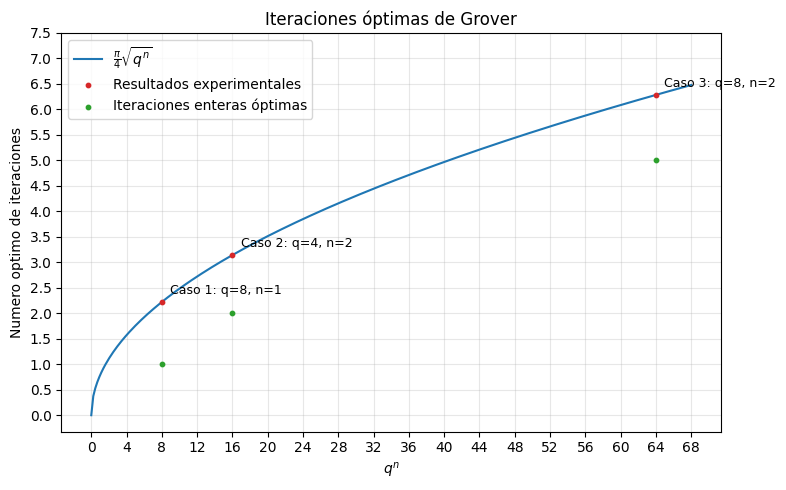

In [78]:
#Grafica comparativa: q^n frente al numero óptimo de iteraciones
x_exp = np.array([q1**n1, q2**n2, q3**n3])
y_exp = np.array([it_teoricas1, it_teoricas2, it_teoricas3])
y_ent = np.array([entero1, entero2, entero3])

x_teo = np.linspace(0, 68, 300)
y_teo = (math.pi / 4) * np.sqrt(x_teo)

plt.figure(figsize=(8, 5))
plt.plot(x_teo, y_teo, label=r'$\frac{\pi}{4}\sqrt{q^n}$', color='tab:blue')
plt.scatter(x_exp, y_exp, color='tab:red', s=10, label='Resultados experimentales', zorder=3)
plt.scatter(x_exp, y_ent, color='tab:green', s=10, label='Iteraciones enteras óptimas', zorder=3)

etiquetas = [
    f'Caso 1: q={q1}, n={n1}',
    f'Caso 2: q={q2}, n={n2}',
    f'Caso 3: q={q3}, n={n3}'
]

for x, y, etiqueta in zip(x_exp, y_exp, etiquetas):
    plt.annotate(etiqueta, (x, y), textcoords='offset points', xytext=(6, 6), fontsize=9)

plt.xlabel(r'$q^n$')
plt.ylabel('Numero optimo de iteraciones')
plt.title('Iteraciones óptimas de Grover')
plt.xticks(np.arange(0, 70, 4))
plt.yticks(np.arange(0, 8, 0.5))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()